<a href="https://colab.research.google.com/github/hawa1983/Capstone/blob/main/ibx_capstone_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feasibility of Implementing the GTFS Stops-to-GeoDataFrame Workflow Entirely in Python

## Executive summary

From my perspective as the implementer, **every task implied by our conversation and the attached notebook-style pipeline can be implemented using Python code**, including: reading GTFS `stops.txt` from GitHub, handling parsing issues, filtering by `location_type`, constructing a `GeoDataFrame` from `stop_lon/stop_lat`, reprojecting, buffering, spatial joins, mapping, exporting, and even scaling to large GTFS tables with an embedded analytical engine (DuckDB). The key nuance is what “entirely in Python” means in practice:

Python can orchestrate all steps, but several geospatial capabilities rely on **native (non-Python) libraries** under the hood—most notably **GEOS, PROJ, and GDAL** that power Shapely/GeoPandas’ geometry, CRS transforms, and file I/O. GeoPandas explicitly notes this dependency stack and that installation can be challenging without managed environments. citeturn2search1turn2search6

Similarly, any pipeline that downloads MTA GTFS feeds, Census ACS data, NYC Open Data (Socrata), or GBFS feeds is still “Python-implemented,” but requires **network access** and sometimes **API keys / rate-limit hygiene** (especially for Census and Socrata). citeturn10search1turn11search0turn12view0

## Inventory of tasks and code patterns implied by the conversation and attached pipeline

Below is a consolidated inventory of the operations I need to support, grouped by the work they perform. (This includes the explicit items you listed and the additional geospatial/data-engineering patterns present in the attached pipeline.)

Data acquisition and ingestion includes reading GTFS text files (especially `stops.txt`) from a GitHub-hosted location and learning to avoid the “blob page HTML” trap; pandas can read URLs directly, but only if the URL resolves to the raw file. The GitHub UI explicitly provides a “Raw” view for unstylized file contents—which is what scripts should target. citeturn6search15turn5view0

Robust parsing includes handling `ParserError` conditions, malformed rows, delimiter/quoting mismatches, encoding issues, and choosing appropriate parsing engines. Pandas supports an `engine` parameter and `on_bad_lines` behavior to skip/warn/process malformed lines. citeturn5view0turn1view2

GTFS semantics includes treating `stop_lat`/`stop_lon` as the stop coordinates and using `location_type` to distinguish platforms/stops vs stations and other location types. The GTFS reference defines the allowed `location_type` values (0/empty stop/platform; 1 station; 2 entrance/exit; 3 generic node; 4 boarding area) and specifies when `stop_lat/stop_lon` are required. citeturn7view0turn1view1

Geospatial modeling includes creating point geometries from longitude/latitude (`points_from_xy`), setting CRS (usually EPSG:4326 for GTFS), reprojecting to a projected CRS for accurate distance/area work (`to_crs`), building buffers, and forming study-area bounding boxes/unions. GeoPandas explicitly documents that `points_from_xy` assumes x=longitude and y=latitude for geographic coordinates. citeturn1view3turn1view5

Spatial analytics includes spatial joins (`sjoin`) with predicates (`within`, `intersects`, sometimes `dwithin`), nearest-neighbor queries using spatial indexes (`sindex`), clipping layers, and computing derived metrics (counts/densities, proximity distances). GeoPandas documents `sjoin` and notes that operations are planar (not geodesic). citeturn1view4turn3search3

Scaling and performance includes using DuckDB to query large GTFS tables (e.g., `stop_times.txt`, `trips.txt`, `routes.txt`) without loading everything into pandas; DuckDB documents CSV “auto detection” and provides `read_csv_auto`/`read_csv` paths to handle varied CSV dialects. citeturn3search1turn3search1

Outputs include exporting tabular results (CSV) and geospatial layers (GeoPackage, GeoJSON, etc.). GeoPandas’ `to_file` writes via the Pyogrio or Fiona I/O engines (both GDAL/OGR-backed), and supports drivers such as `"GPKG"`. citeturn2search0turn9search2

Visualization includes static plotting (GeoPandas/Matplotlib) and interactive HTML maps (Folium). Folium’s documentation shows standard patterns for MarkerCluster and saving maps to HTML. citeturn3search8turn3search0  
If I choose Kepler.gl, I must account for Jupyter extension requirements (Node + JupyterLab extensions) beyond Python-only pip installs. citeturn4search2

## Python implementation patterns for each major task

I can implement every item you enumerated with mainstream Python libraries; the sections below focus on the most “load-bearing” patterns and parameters I need to get right.

For reading GTFS from GitHub correctly, the core rule is: **don’t use a `.../blob/...` URL with pandas** because that serves an HTML page. Instead, I use a raw-content URL (either via GitHub’s “Raw” view or the `raw.githubusercontent.com` format), which is explicitly meant to show raw file content without styling. citeturn6search15

For parsing and handling malformed rows, pandas provides the knobs I need. The `engine` parameter governs the parsing backend, and `on_bad_lines` defines how to handle lines with too many fields; it supports `'error'`, `'warn'`, `'skip'`, or a callable (noting callable signatures differ across engines). citeturn5view0turn1view2  
Separators and quoting are equally important: `sep` can be a single-character delimiter or regex, but regex delimiters force the Python engine and can ignore quoted data. citeturn5view1

For filtering stations using `location_type`, I must treat GTFS semantics carefully: a station is `location_type=1` per the GTFS reference; platforms/stops are `location_type=0` or empty. citeturn7view0turn1view1  
In real feeds, `location_type` might be missing or blank; in those cases, robust code defaults missing values to 0 (stop/platform) and filters accordingly.

For creating a GeoDataFrame from stop longitude and latitude, GeoPandas gives me the canonical pattern: `geopandas.points_from_xy(x, y, crs=...)` and then `GeoDataFrame(..., geometry=...)`. GeoPandas explicitly documents that for geographic coordinates it assumes `x = longitude` and `y = latitude`. citeturn1view3

For reprojection, `GeoDataFrame.to_crs()` is the standard. It requires that the current CRS is set, and it transforms coordinates assuming **planar segments** (it does not perform geodesic transformations of entire geometries). citeturn1view5  
For city-scale distance/buffer analysis, I typically reproject WGS84 points (EPSG:4326) into an **appropriate projected CRS** (e.g., a local State Plane or UTM zone).

For buffering, I use `GeoSeries.buffer(distance)` with distances expressed in the units of the CRS. GeoPandas provides the buffer method at the GeoSeries level. citeturn4search13  
The key operational point is that GeoPandas geometry ops are planar. The `sjoin` docs explicitly state every operation is planar, and GeoPandas warns when buffering in a geographic CRS because degrees are not linear units; the practical mitigation is reprojecting first. citeturn1view4turn1view5

For spatial joins, I use `geopandas.sjoin(left, right, predicate=...)`, selecting `predicate="within"` for point-in-polygon counts, or `predicate="intersects"` for polygon overlap. GeoPandas documents `sjoin` and supported predicates, and its spatial index documentation explains that `sindex` uses Shapely’s STRtree. citeturn1view4turn3search3

For mapping, Folium produces interactive HTML entirely from Python code, but requires a browser (or notebook renderer) to view. Marker clustering is a documented plugin pattern. citeturn3search0turn3search8  
If I use Kepler.gl, I still write Python, but the Jupyter integration specifically requires **Node** and JupyterLab extensions—so the runtime environment is not “Python-only.” citeturn4search2

For scaling, DuckDB is a strong option for GTFS tables like `stop_times.txt` that can become very large. DuckDB’s CSV auto-detection documentation describes how it infers delimiter/quoting/types because CSV is not self-describing. citeturn3search1

## Tasks that require non-Python system dependencies or external services

The most important boundary is that many “Python geospatial” libraries are Python interfaces over mature C/C++ geospatial stacks.

GeoPandas explicitly states it depends on **GEOS, GDAL, and PROJ**, and warns these can be a challenge to install in some environments. citeturn2search1  
Shapely likewise describes itself as manipulating planar geometries and is built on the GEOS library. citeturn2search6  
GeoPandas file output uses Pyogrio or Fiona, both of which bind to GDAL/OGR drivers. GeoPandas `to_file` documents that it writes any OGR data source supported by Pyogrio or Fiona. citeturn2search0turn9search6turn2search5  
This matters if I interpret “entirely in Python” as “no compiled dependencies”: that stricter goal is generally **not realistic** for serious vector GIS operations because GEOS/PROJ/GDAL are foundational.

If the workflow includes raster operations (even “if needed”), Rasterio is Python-controlled but depends on GDAL and its dependencies. citeturn9search0

Interactive visualization can introduce non-Python requirements. Folium is pure Python on the generation side, but renders in a web browser (Leaflet JS). citeturn3search8  
Kepler.gl’s Jupyter mode requires Node and JupyterLab extensions per official docs. citeturn4search2

External services and APIs are also not “purely local,” even though I call them from Python:

- ACS via Census API is explicitly an API-based access method. citeturn10search1turn10search5  
- NYC Open Data is served via Socrata’s SODA API; Socrata documents the `within_box` geospatial filter I would use for bounding-box queries. citeturn11search0turn11search15  
- Socrata geospatial ordering can be subtle: point geometries use GeoJSON/WKT “lon,lat” order, while `within_box` uses “latitude, longitude corners” in conventional order; Socrata documents this distinction. citeturn11search0turn11search17  
- GBFS is a published standard; `station_information.json` is a specified feed and is part of the official “Current Version” reference. citeturn12view0turn12view1  
- MTA data is published under its developer resources portal. citeturn10search0turn10search8

## Environment constraints treated as open-ended

Several practical constraints are not specified and materially affect implementation choices:

Dataset scale is unknown: a small single-feed GTFS can be handled with pandas; multi-feed (bus-by-borough) plus `stop_times.txt` often motivates DuckDB/Dask/Polars patterns. DuckDB provides a pragmatic “SQL over CSV” approach without requiring a separate database. citeturn3search1

Execution environment is unknown (local laptop vs Colab vs server). This primarily impacts geospatial dependency installation: pip wheels may “just work” in some setups, but conda-forge is often the smoother path for GDAL/PROJ/GEOS stacks, which GeoPandas highlights as an installation complexity. citeturn2search1turn2search4

Operating system is not stated; Windows environments in particular often benefit from conda distributions for GDAL-family libraries; Docker can provide reproducibility across OSes at the cost of container overhead.

Network access and credentials are unspecified: ACS requires a Census API key for production usage; Socrata APIs can require app tokens for better rate limits; some environments block outbound HTTP.

## Compatibility table for pip-only, conda-forge, and Docker approaches

The table below compares three realistic ways I can run the full pipeline.

| Approach | What I mean by it | Typical install commands | Pros | Cons / gotchas |
|---|---|---|---|---|
| pip-only (wheels) | Use `pip` in venv; rely on prebuilt wheels bundling native libs where available | `python -m venv .venv` → `pip install -U pip` → `pip install pandas geopandas shapely pyproj pyogrio fiona duckdb folium requests networkx` | Fast to start; fits many notebook environments | May hit binary incompatibilities around GDAL/OGR stacks; Pyogrio docs explicitly warn pip installs can encounter GDAL version mismatches depending on what gets compiled/installed. citeturn2search4turn2search1 |
| conda-forge | Use conda/mamba to install GeoPandas stack with consistent GDAL/PROJ/GEOS | `mamba create -n geo python=3.12 -c conda-forge geopandas pyogrio fiona gdal pandas shapely pyproj duckdb folium requests networkx` | Most reliable for GDAL/PROJ/GEOS; aligns with GeoPandas guidance that base C libs can be challenging and installation recommendations matter. citeturn2search1turn2search4 | Heavier environment tooling; slower cold-start than pip |
| Docker | Containerize OS + dependencies + code | Use a GDAL-capable base image or micromamba image; then install conda-forge stack | Best reproducibility; good for CI and deployment | Requires Docker runtime; file permissions/volumes; for Kepler.gl you still may need Node tooling inside container if running JupyterLab extensions. citeturn4search2 |

A useful implementation detail for GeoPandas I/O performance: GeoPandas notes that as of version 1.0 the default I/O engine changed from Fiona to Pyogrio for performance reasons, and the engine can be configured. citeturn9search2

## Reference code snippets for robust Python implementations

The snippets below are intentionally defensive and cover the workflow elements you listed: raw GitHub reads, parsing failures, filtering station rows, creating GeoDataFrames, reprojecting for distance, buffering, spatial joins, mapping, and exporting.

### Reading GTFS `stops.txt` from GitHub robustly

# Section A — Spatial Framework

## Purpose of the Code

The purpose of this code is to combine two separate transit stop datasets into one clean, unified file. Specifically, it retrieves an existing GTFS stops file from your GitHub repository and merges it with a second file containing IBX stop coordinates. The end goal is to produce an updated stops dataset that includes both the original transit system stops and the IBX stops in a single, usable file.

First, the script ensures that GitHub links are usable for data processing. Standard GitHub “blob” URLs display files as web pages rather than raw text, which makes them unsuitable for automated downloads. The code converts those links into raw file URLs so the actual data content can be accessed directly. It then downloads the file and checks that the response is not an HTML page. This validation step prevents errors caused by accidentally loading a webpage instead of the intended dataset.

Next, the script loads both the original stops file and the IBX stops file into structured tables using pandas. Once loaded, it standardizes key fields such as latitude, longitude, and location type. This ensures that geographic coordinates are stored as numeric values and that required columns follow a consistent format. Standardizing data types is critical because mapping systems, routing algorithms, and GTFS validation tools rely on properly formatted numerical coordinates and consistent schema structures.

After cleaning and standardizing the data, the two datasets are merged into one combined table. The IBX stops are appended to the original stops list, and any duplicate stop identifiers are resolved by keeping the most recent entry. This ensures that IBX stop information overrides older entries if the same stop ID appears in both datasets. The result is a unified dataset without duplicate stop IDs and with consistent formatting across all records.

Finally, the combined dataset is saved as a new file. This output serves as an updated GTFS-compatible stops file that includes IBX stops alongside the existing system stops. Overall, the script functions as a streamlined data pipeline: it downloads, validates, cleans, merges, and exports transit stop data into a structured and reusable format suitable for further analysis, mapping, or integration into a GTFS feed.


In [1]:
# =========================================================
# GTFS + IBX + Station Complex Integration Utility
#
# Purpose:
#   Downloads the official GTFS stops file and an IBX stop coordinate file
#   from GitHub, normalizes their structure, merges them into a single
#   unified stops dataset, and appends official MTA station complex info.
#
# Key Features:
#   • Automatically converts GitHub "blob" URLs to raw file URLs.
#   • Validates that downloaded content is not HTML.
#   • Loads text/CSV files into pandas DataFrames.
#   • Normalizes latitude, longitude, and location_type fields.
#   • Appends IBX stops to the primary GTFS stops dataset.
#   • Resolves duplicate stop_id values (IBX entries override original).
#   • Merges stop_id -> station_complex_id crosswalk from attached MTA file.
#   • For IBX stops not found in the official complex file, creates a
#     self-contained station-complex record using the IBX stop's own fields.
#
# Data Sources:
#   - GTFS stops.txt (main system stops)
#   - IBX stop coordinates file (custom/extension stops)
#   - Attached MTA Subway Stations and Complexes CSV
#
# Processing Steps:
#   1. Convert GitHub blob links to raw URLs when necessary.
#   2. Download and parse CSV content into pandas.
#   3. Enforce numeric formatting for stop_lat and stop_lon.
#   4. Standardize location_type (default = 0 if missing).
#   5. Concatenate GTFS + IBX datasets and remove duplicate stop_id entries.
#   6. Load station complex file and explode GTFS Stop IDs into one stop_id per row.
#   7. Merge station complex metadata into combined stops file.
#   8. For unmatched IBX stops, assign stop_id as station_complex_id and
#      use stop attributes as complex attributes.
#   9. Export merged result to "stops_with_ibx_and_complex.csv".
#
# Output:
#   stops_with_ibx_and_complex.csv
#
# Notes:
#   - Duplicate stop_ids retain the last occurrence (IBX overrides GTFS).
#   - Official subway stops use MTA Complex ID where available.
#   - IBX stops become their own station complex when no official complex exists.
#   - station_complex_id will therefore be mixed-type (numeric for MTA subway
#     complexes, string for IBX self-defined complexes).
# =========================================================

from __future__ import annotations

import re
from io import StringIO

import requests
import pandas as pd


def github_blob_to_raw(url: str) -> str:
    """
    Convert a standard GitHub 'blob' URL into a raw content URL.
    """
    m = re.match(r"^https?://github\.com/([^/]+)/([^/]+)/blob/([^/]+)/(.*)$", url)
    if not m:
        return url

    org, repo, branch, path = m.groups()
    return f"https://raw.githubusercontent.com/{org}/{repo}/{branch}/{path}"


def read_text_csv(url: str, *, timeout: int = 60) -> pd.DataFrame:
    """
    Download a CSV/text file from a URL and load it into a pandas DataFrame.
    """
    raw_url = github_blob_to_raw(url)
    r = requests.get(raw_url, timeout=timeout)
    r.raise_for_status()

    head = r.text[:2000].lstrip().lower()
    if head.startswith("<!doctype html") or "<html" in head[:200]:
        raise ValueError(
            "URL did not resolve to raw text content (looks like HTML). "
            "Use a raw.githubusercontent.com URL."
        )

    return pd.read_csv(
        StringIO(r.text),
        sep=",",
        encoding="utf-8",
        on_bad_lines="warn",
        engine="c",
        low_memory=False,
    )


# ----------------------------
# Load GTFS and IBX stop files
# ----------------------------

stops_df = read_text_csv(
    "https://github.com/hawa1983/Capstone/blob/main/stops.txt"
)

ibx_df = read_text_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ibx%20stops%20coordinates.txt"
)

# Attached MTA station complex crosswalk
complex_file_path = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/MTA_Subway_Stations_and_Complexes.csv"
complex_df = pd.read_csv(complex_file_path)


# ----------------------------
# Normalize GTFS + IBX Fields
# ----------------------------

for df in (stops_df, ibx_df):
    df["stop_id"] = df["stop_id"].astype(str).str.strip()
    df["stop_name"] = df["stop_name"].astype(str).str.strip()

    df["stop_lat"] = pd.to_numeric(df["stop_lat"], errors="coerce")
    df["stop_lon"] = pd.to_numeric(df["stop_lon"], errors="coerce")

    if "location_type" in df.columns:
        df["location_type"] = (
            pd.to_numeric(df["location_type"], errors="coerce")
            .fillna(0)
            .astype(int)
        )
    else:
        df["location_type"] = 0


# Keep a set of IBX stop_ids so we can identify them after merging
ibx_stop_ids = set(ibx_df["stop_id"].astype(str).str.strip())


# ----------------------------
# Merge GTFS + IBX Stops
# ----------------------------

combined_stops = pd.concat([stops_df, ibx_df], ignore_index=True)

combined_stops_df = (
    combined_stops
    .drop_duplicates(subset=["stop_id"], keep="last")
    .reset_index(drop=True)
)


# ----------------------------
# Build official stop_id -> station_complex_id crosswalk
# ----------------------------

complex_cols = [
    "Complex ID",
    "Stop Name",
    "Display Name",
    "Constituent Station Names",
    "Station IDs",
    "GTFS Stop IDs",
    "Borough",
    "CBD",
    "Daytime Routes",
    "Structure Type",
    "Latitude",
    "Longitude",
    "ADA",
    "ADA Notes",
]

complex_xwalk = complex_df[complex_cols].copy()

complex_xwalk = complex_xwalk.rename(columns={
    "Complex ID": "station_complex_id",
    "Stop Name": "complex_stop_name",
    "Display Name": "complex_display_name",
    "Constituent Station Names": "constituent_station_names",
    "Station IDs": "station_ids",
    "GTFS Stop IDs": "gtfs_stop_ids",
    "Borough": "borough",
    "CBD": "cbd",
    "Daytime Routes": "daytime_routes",
    "Structure Type": "structure_type",
    "Latitude": "complex_latitude",
    "Longitude": "complex_longitude",
    "ADA": "ada",
    "ADA Notes": "ada_notes",
})

complex_xwalk["station_complex_id"] = pd.to_numeric(
    complex_xwalk["station_complex_id"], errors="coerce"
)

complex_xwalk["gtfs_stop_ids"] = complex_xwalk["gtfs_stop_ids"].astype(str).str.strip()
complex_xwalk["stop_id"] = complex_xwalk["gtfs_stop_ids"].str.split(r"\s*;\s*")
complex_xwalk = complex_xwalk.explode("stop_id")

complex_xwalk["stop_id"] = complex_xwalk["stop_id"].astype(str).str.strip()

complex_xwalk = complex_xwalk[
    complex_xwalk["stop_id"].notna() &
    (complex_xwalk["stop_id"] != "") &
    (complex_xwalk["stop_id"].str.lower() != "nan")
].copy()

complex_xwalk = (
    complex_xwalk
    .drop_duplicates(subset=["stop_id"], keep="first")
    .reset_index(drop=True)
)

complex_xwalk = complex_xwalk[
    [
        "stop_id",
        "station_complex_id",
        "complex_stop_name",
        "complex_display_name",
        "constituent_station_names",
        "station_ids",
        "borough",
        "cbd",
        "daytime_routes",
        "structure_type",
        "complex_latitude",
        "complex_longitude",
        "ada",
        "ada_notes",
    ]
]


# ----------------------------
# Merge official station complex info into stops
# ----------------------------

combined_stops_with_complex_df = combined_stops_df.merge(
    complex_xwalk,
    on="stop_id",
    how="left",
    validate="m:1"
)


# ----------------------------
# Identify IBX rows
# ----------------------------

combined_stops_with_complex_df["is_ibx"] = (
    combined_stops_with_complex_df["stop_id"].isin(ibx_stop_ids)
)


# ----------------------------
# For IBX stops missing official complex info,
# use the stop's own fields as its station complex
# ----------------------------

ibx_mask = (
    combined_stops_with_complex_df["is_ibx"] &
    combined_stops_with_complex_df["station_complex_id"].isna()
)

# station_complex_id becomes the IBX stop_id
combined_stops_with_complex_df.loc[ibx_mask, "station_complex_id"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"].astype(str)
)

# use stop-level naming as complex-level naming
combined_stops_with_complex_df.loc[ibx_mask, "complex_stop_name"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "complex_display_name"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "constituent_station_names"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "station_ids"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"]
)

# use stop coordinates as complex coordinates
combined_stops_with_complex_df.loc[ibx_mask, "complex_latitude"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_lat"]
)
combined_stops_with_complex_df.loc[ibx_mask, "complex_longitude"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_lon"]
)

# optional defaults for other complex fields
combined_stops_with_complex_df.loc[ibx_mask, "daytime_routes"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"]
)
combined_stops_with_complex_df.loc[ibx_mask, "structure_type"] = "IBX"
combined_stops_with_complex_df.loc[ibx_mask, "ada_notes"] = (
    "Synthetic station complex created from IBX stop attributes"
)

# If cbd/ada/borough are missing for IBX, leave them as NaN unless you want defaults
# Example defaults:
# combined_stops_with_complex_df.loc[ibx_mask, "cbd"] = 0
# combined_stops_with_complex_df.loc[ibx_mask, "ada"] = 0


# ----------------------------
# Final cleanup
# ----------------------------

# Convert to object so numeric subway complex IDs and string IBX IDs can coexist
combined_stops_with_complex_df["station_complex_id"] = (
    combined_stops_with_complex_df["station_complex_id"].astype(object)
)

# Optional: create a unified station-complex name field
combined_stops_with_complex_df["station_complex_name"] = (
    combined_stops_with_complex_df["complex_display_name"]
    .fillna(combined_stops_with_complex_df["complex_stop_name"])
    .fillna(combined_stops_with_complex_df["stop_name"])
)

# Optional: create a single lat/lon for complex geometry
combined_stops_with_complex_df["station_complex_lat"] = (
    pd.to_numeric(combined_stops_with_complex_df["complex_latitude"], errors="coerce")
)
combined_stops_with_complex_df["station_complex_lon"] = (
    pd.to_numeric(combined_stops_with_complex_df["complex_longitude"], errors="coerce")
)


# ----------------------------
# Save Final File
# ----------------------------

output_file = "stops_with_ibx_and_complex.csv"
combined_stops_with_complex_df.to_csv(output_file, index=False)

print(f"File saved as: {output_file}")

print("\nRow count:", len(combined_stops_with_complex_df))
print("Unique stop_id count:", combined_stops_with_complex_df["stop_id"].nunique())
print(
    "Stops matched to official station_complex_id:",
    combined_stops_with_complex_df.loc[
        ~combined_stops_with_complex_df["is_ibx"], "station_complex_id"
    ].notna().sum()
)
print(
    "IBX stops assigned self station_complex_id:",
    combined_stops_with_complex_df.loc[
        combined_stops_with_complex_df["is_ibx"], "station_complex_id"
    ].notna().sum()
)

display(combined_stops_with_complex_df.tail(25))

File saved as: stops_with_ibx_and_complex.csv

Row count: 1516
Unique stop_id count: 1516
Stops matched to official station_complex_id: 496
IBX stops assigned self station_complex_id: 19


/tmp/ipykernel_739/2370345122.py:263: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['IBX_1' 'IBX_2' 'IBX_3' 'IBX_4' 'IBX_5' 'IBX_6' 'IBX_7' 'IBX_8' 'IBX_9'
 'IBX_10' 'IBX_11' 'IBX_12' 'IBX_13' 'IBX_14' 'IBX_15' 'IBX_16' 'IBX_17'
 'IBX_18' 'IBX_19']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_stops_with_complex_df.loc[ibx_mask, "station_complex_id"] = (


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,station_complex_id,complex_stop_name,complex_display_name,constituent_station_names,...,daytime_routes,structure_type,complex_latitude,complex_longitude,ada,ada_notes,is_ibx,station_complex_name,station_complex_lat,station_complex_lon
1491,S30,Tompkinsville,40.636949,-74.074835,1,NaN,502.0,Tompkinsville,Tompkinsville (SIR),Tompkinsville,...,SIR,At Grade,40.636949,-74.074835,0.0,NaN,False,Tompkinsville (SIR),40.636949,-74.074835
1492,S30N,Tompkinsville,40.636949,-74.074835,0,S30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Tompkinsville,NaN,NaN
1493,S30S,Tompkinsville,40.636949,-74.074835,0,S30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Tompkinsville,NaN,NaN
1494,S31,St George,40.643748,-74.073643,1,NaN,501.0,St George,St George (SIR),St George,...,SIR,Open Cut,40.643748,-74.073643,1.0,NaN,False,St George (SIR),40.643748,-74.073643
1495,S31N,St George,40.643748,-74.073643,0,S31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,St George,NaN,NaN
1496,S31S,St George,40.643748,-74.073643,0,S31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,St George,NaN,NaN
1497,IBX_1,Roosevelt Avenue,40.746500,-73.891000,1,NaN,IBX_1,Roosevelt Avenue,Roosevelt Avenue,Roosevelt Avenue,...,IBX_1,IBX,40.746500,-73.891000,NaN,Synthetic station complex created from IBX sto...,True,Roosevelt Avenue,40.746500,-73.891000
1498,IBX_2,Grand Avenue,40.728900,-73.889700,1,NaN,IBX_2,Grand Avenue,Grand Avenue,Grand Avenue,...,IBX_2,IBX,40.728900,-73.889700,NaN,Synthetic station complex created from IBX sto...,True,Grand Avenue,40.728900,-73.889700
1499,IBX_3,Eliot Avenue,40.725500,-73.879200,1,NaN,IBX_3,Eliot Avenue,Eliot Avenue,Eliot Avenue,...,IBX_3,IBX,40.725500,-73.879200,NaN,Synthetic station complex created from IBX sto...,True,Eliot Avenue,40.725500,-73.879200
1500,IBX_4,Metropolitan Avenue,40.711900,-73.889600,1,NaN,IBX_4,Metropolitan Avenue,Metropolitan Avenue,Metropolitan Avenue,...,IBX_4,IBX,40.711900,-73.889600,NaN,Synthetic station complex created from IBX sto...,True,Metropolitan Avenue,40.711900,-73.889600


## Filtering GTFS Stations from the Combined Stops Dataset

This code extracts only **station-level stops** from the merged GTFS dataset. In GTFS, the `location_type` field is used to classify different types of stops. A value of `1` represents a **station**, while other values (such as `0`) typically represent individual boarding stops or platforms.

First, the code retrieves the `location_type` column from the `combined_stops` DataFrame. If the column does not exist, it defaults to `0`, which prevents the code from failing due to a missing field. It then converts the values in this column to numeric form, coercing any invalid entries into missing values. Those missing values are replaced with `0`, and the column is cast to integers. This ensures that the filtering step works reliably and that all values follow GTFS enumeration rules.

Next, the code creates a new DataFrame called `stations_df` by selecting only the rows where `location_type` equals `1`. This isolates records that represent stations rather than platforms or other stop types. The `.copy()` method is used to create a separate DataFrame, avoiding potential warnings or unintended modifications to the original dataset.

Finally, the `display()` function shows the filtered station-level records. In summary, this code segment cleans and standardizes the `location_type` field, then filters the dataset to include only GTFS-defined stations.


In [2]:
# =========================================================
# Station Complex-Level Extraction
#
# Purpose:
#   Collapse the GTFS + IBX stops dataset to one row per
#   station_complex_id for use with complex-level ridership.
#
# Methodology:
#   1. Ensure station_complex_id exists.
#   2. Select representative fields for the complex.
#   3. Drop duplicate complex records.
#
# Output:
#   station_complex_df
#     One row per station complex.
# =========================================================


# Ensure station_complex_id exists
if "station_complex_id" not in combined_stops_with_complex_df.columns:
    raise ValueError("station_complex_id column not found.")


# Select representative fields
complex_cols = [
    "station_complex_id",
    "station_complex_name",
    "station_complex_lat",
    "station_complex_lon",
    "borough",
    "daytime_routes",
    "structure_type",
    "ada",
    "cbd"
]

# Keep only columns that actually exist
complex_cols = [c for c in complex_cols if c in combined_stops_with_complex_df.columns]


# Create station complex dataset
station_complex_df = (
    combined_stops_with_complex_df[complex_cols]
    .drop_duplicates(subset=["station_complex_id"])
    .reset_index(drop=True)
)


# Display complex-level dataset
display(station_complex_df)


# Optional diagnostics
print("Number of station complexes:", len(station_complex_df))
print("Unique station_complex_id:", station_complex_df["station_complex_id"].nunique())

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False
1,NaN,Van Cortlandt Park-242 St,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False
...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN


Number of station complexes: 465
Unique station_complex_id: 464


This matches the GTFS reference semantics: station rows are `location_type = 1`, while platforms/stops are `0` or empty. citeturn7view0turn1view1

### Validating latitude/longitude columns before geometry construction

## Validating and Cleaning GTFS Stop Coordinates

This code validates that the stop dataset contains proper geographic coordinate fields and removes any records with invalid latitude or longitude values.

First, it defines a set of required columns: `stop_lat` and `stop_lon`. These fields are mandatory in GTFS because they store the geographic coordinates of each stop. The code then checks whether these required columns are actually present in the `stops_df` DataFrame. If either column is missing, it raises a `ValueError` and stops execution. This prevents downstream errors and ensures the dataset meets minimum GTFS structural requirements.

Next, the code converts both the latitude and longitude columns to numeric values. If any values are non-numeric (for example, text or malformed entries), they are coerced into missing values (`NaN`). This step ensures the coordinate fields are stored in a numeric format suitable for geographic validation and mapping.

After conversion, the code applies geographic boundary checks. Valid latitude values must fall between -90 and 90 degrees, and valid longitude values must fall between -180 and 180 degrees. These are the universal bounds for real-world geographic coordinates. The `between()` function creates a logical mask that identifies rows where both latitude and longitude fall within valid ranges.

Finally, the dataset is filtered to keep only rows with valid coordinates. Any stops with missing, malformed, or out-of-range coordinates are removed. The `.copy()` method ensures that the filtered result is stored as a clean, independent DataFrame.

In summary, this code performs structural validation and geographic quality control on the GTFS stop data, ensuring that all remaining stops contain valid numeric latitude and longitude values within real-world bounds.


In [3]:
# =========================================================
# Station Complex Coordinate Validation & Cleaning
#
# Purpose:
#   Ensures all station complexes in the complex-level dataset
#   contain valid geographic coordinates suitable for
#   spatial analysis and mapping.
#
# Validation Steps:
#
#   1. Required Column Check
#      - Verifies presence of:
#           • station_complex_lat (latitude)
#           • station_complex_lon (longitude)
#      - Raises a ValueError if either column is missing.
#
#   2. Numeric Conversion
#      - Converts station_complex_lat and station_complex_lon
#        to numeric types.
#      - Invalid or malformed values are coerced to NaN.
#
#   3. Geographic Bounds Validation
#      - Latitude must be within [-90, 90]
#      - Longitude must be within [-180, 180]
#      - Rows failing these checks (or containing NaN) are flagged.
#
#   4. Row Filtering
#      - Removes rows with:
#           • Missing coordinates
#           • Non-numeric values
#           • Out-of-range latitude/longitude
#      - Produces a clean complex-level DataFrame ready for
#        geospatial processing.
#
# Output:
#   station_complex_df (cleaned)
#
# Notes:
#   - Prevents downstream spatial errors (buffer creation, projections, joins).
#   - Ensures coordinate integrity before geometry construction.
#   - Designed for reproducible transit network preprocessing.
# =========================================================


# --------------------------------------------
# Validate Required Coordinate Columns
# --------------------------------------------

# Define the set of required coordinate columns.
required = {"station_complex_lat", "station_complex_lon"}

# Determine whether any required columns are missing.
missing = required - set(station_complex_df.columns)

# If any required columns are missing, raise an error.
if missing:
    raise ValueError(f"Missing required columns: {missing}")


# --------------------------------------------
# Convert Coordinates to Numeric
# --------------------------------------------

# Convert complex latitude and longitude to numeric.
# Invalid values are coerced to NaN.
station_complex_df["station_complex_lat"] = pd.to_numeric(
    station_complex_df["station_complex_lat"], errors="coerce"
)
station_complex_df["station_complex_lon"] = pd.to_numeric(
    station_complex_df["station_complex_lon"], errors="coerce"
)


# --------------------------------------------
# Validate Geographic Bounds
# --------------------------------------------

# Latitude must be between -90 and 90.
# Longitude must be between -180 and 180.
valid = (
    station_complex_df["station_complex_lat"].between(-90, 90)
    & station_complex_df["station_complex_lon"].between(-180, 180)
)


# --------------------------------------------
# Filter Out Invalid Rows
# --------------------------------------------

# Keep only rows with valid coordinates.
station_complex_df = station_complex_df.loc[valid].copy()


# --------------------------------------------
# Display Cleaned Dataset
# --------------------------------------------

display(station_complex_df)

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False
...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN


GTFS also allows `stop_lat/stop_lon` to be optional for some `location_type` values; robust code should allow nulls for those rows if I keep them. citeturn7view0

### Creating a GeoDataFrame from `stop_lon/stop_lat`


In [4]:
# =========================================================
# Station Complex GeoDataFrame Creation (WGS84)
#
# Purpose:
#   Converts validated station complex records into a GeoDataFrame
#   with spatial point geometry for geospatial analysis.
#
# Methodology:
#   1. Complex-Level Input
#      - Uses the cleaned station_complex_df dataset.
#      - Assumes one row per station_complex_id.
#      - Ensures coordinates have already passed validation checks.
#
#   2. Geometry Construction
#      - Uses GeoPandas points_from_xy():
#           • x = station_complex_lon (longitude)
#           • y = station_complex_lat (latitude)
#      - Assigns CRS = "EPSG:4326" (WGS84 geographic coordinate system).
#
#   3. GeoDataFrame Creation
#      - Wraps the station complex DataFrame into a GeoDataFrame.
#      - Adds a geometry column containing Point objects.
#
# Output:
#   station_complex_gdf
#     A GeoDataFrame of station complexes with valid spatial geometry.
#
# Notes:
#   - EPSG:4326 is appropriate for storage and visualization.
#   - For distance or buffer calculations, reproject to a projected CRS
#     (e.g., EPSG:2263 for NYC / NAD83 Long Island ft).
#   - Designed to support downstream spatial joins and buffer analysis.
# =========================================================

import geopandas as gpd

# --------------------------------------------
# Validate required coordinate columns
# --------------------------------------------

required = {"station_complex_lat", "station_complex_lon"}
missing = required - set(station_complex_df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")


# --------------------------------------------
# Ensure coordinates are numeric
# --------------------------------------------

station_complex_df["station_complex_lat"] = pd.to_numeric(
    station_complex_df["station_complex_lat"], errors="coerce"
)
station_complex_df["station_complex_lon"] = pd.to_numeric(
    station_complex_df["station_complex_lon"], errors="coerce"
)


# --------------------------------------------
# Keep only valid coordinates
# --------------------------------------------

valid = (
    station_complex_df["station_complex_lat"].between(-90, 90)
    & station_complex_df["station_complex_lon"].between(-180, 180)
)

station_complex_df = station_complex_df.loc[valid].copy()


# --------------------------------------------
# Convert to GeoDataFrame
# --------------------------------------------

station_complex_gdf = gpd.GeoDataFrame(
    station_complex_df,
    geometry=gpd.points_from_xy(
        station_complex_df["station_complex_lon"],
        station_complex_df["station_complex_lat"],
        crs="EPSG:4326"
    ),
)

# Display the spatial station complex dataset
display(station_complex_gdf)

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd,geometry
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False,POINT (-73.89858 40.88925)
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False,POINT (-73.90087 40.88467)
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False,POINT (-73.90483 40.87886)
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False,POINT (-73.90983 40.87456)
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False,POINT (-73.91528 40.86944)
...,...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN,POINT (-73.9777 40.6255)
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN,POINT (-73.9903 40.6209)
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN,POINT (-74.0017 40.6372)
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN,POINT (-74.0113 40.6452)


## Reprojecting Station Data to a Local Coordinate System

This code is transforming the station GeoDataFrame from one coordinate reference system (CRS) to another.

Your `stations_gdf` was originally created using **EPSG:4326**, which is the standard WGS84 geographic coordinate system. In this system, locations are stored as latitude and longitude in decimal degrees. While this format is ideal for web maps and GPS, it is not well suited for measuring distances or areas because degrees are not consistent linear units.

The `.to_crs("EPSG:2263")` step converts the dataset into a projected coordinate system. EPSG:2263 is the New York State Plane coordinate system (Long Island zone), and its units are in feet. Projected systems use linear units like feet or meters, which makes them appropriate for spatial analysis tasks such as calculating distances between stations, buffering, clustering, or performing spatial joins.

Importantly, `.to_crs()` does not just relabel the data—it mathematically transforms the coordinate values into the new projection. That transformation requires that the original GeoDataFrame already has a defined CRS (which yours does: EPSG:4326).

The resulting `stations_proj` GeoDataFrame contains the same station records, but the geometry coordinates are now expressed in feet rather than degrees. This makes the data more suitable for accurate distance calculations and local spatial analysis in the New York City area.


In [5]:
# ---------------------------------------------------------
# Reproject Station Complex GeoDataFrame to a Projected CRS
# ---------------------------------------------------------

# =========================================================
# Coordinate Reference System (CRS) Reprojection
#
# Purpose:
#   Converts station complex geometries from geographic
#   coordinates (latitude/longitude in degrees) to a projected
#   coordinate system suitable for accurate distance and
#   area calculations.
#
# Background:
#   - Original CRS: EPSG:4326 (WGS84)
#       • Units: Degrees
#       • Ideal for GPS and web mapping
#       • Not appropriate for linear distance measurement
#
#   - Target CRS: EPSG:2263
#       • NAD83 / New York Long Island (State Plane)
#       • Units: Feet
#       • Optimized for NYC spatial analysis
#
# Why Reproject?
#   Geographic CRS (degrees) distort distance calculations.
#   Projected CRS (feet/meters) provide linear measurement units,
#   making them appropriate for:
#       • Buffer creation (e.g., 0.5 mile radius)
#       • Distance-based joins
#       • Clustering analysis
#       • Local mapping accuracy
#
# Method:
#   Uses GeoDataFrame.to_crs() to transform geometry coordinates.
#   Attribute columns remain unchanged.
#
# Output:
#   station_complex_proj
#     Station complex GeoDataFrame projected to EPSG:2263 (feet).
#
# Notes:
#   - Always verify the source CRS before reprojecting.
#   - All subsequent spatial distance calculations should use
#     this projected CRS to ensure accuracy.
# =========================================================


# --------------------------------------------
# Verify CRS exists before reprojection
# --------------------------------------------

if station_complex_gdf.crs is None:
    raise ValueError(
        "station_complex_gdf has no CRS defined. "
        "Ensure CRS='EPSG:4326' when creating the GeoDataFrame."
    )


# --------------------------------------------
# Reproject to NYC State Plane (EPSG:2263)
# --------------------------------------------

station_complex_proj = station_complex_gdf.to_crs("EPSG:2263")


# After transformation:
# - Geometry coordinates are no longer latitude/longitude
# - Coordinates are projected X/Y values in feet
# - Attribute columns remain unchanged
# - Only geometry is mathematically transformed


# --------------------------------------------
# Display projected GeoDataFrame
# --------------------------------------------

display(station_complex_proj)


# Optional diagnostics
print("Original CRS:", station_complex_gdf.crs)
print("Projected CRS:", station_complex_proj.crs)
print("Number of station complexes:", len(station_complex_proj))

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd,geometry
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False,POINT (1012291.156 263271.208)
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False,POINT (1011660.704 261601.442)
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False,POINT (1010566.908 259483.047)
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False,POINT (1009186.665 257916.747)
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False,POINT (1007681.798 256050.919)
...,...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN,POINT (990440.272 167163.683)
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN,POINT (986942.815 165487.143)
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN,POINT (983778.179 171425.523)
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN,POINT (981114.151 174340.339)


Original CRS: EPSG:4326
Projected CRS: EPSG:2263
Number of station complexes: 464


In [6]:
# =========================================================
# NYC Block Group Boundary Preparation (TIGER/Line 2020)
#
# Purpose:
#   Downloads and prepares U.S. Census TIGER/Line 2020 Block Group
#   boundary geometries for New York City to support spatial joins
#   and station complex buffer analysis.
#
# Data Source:
#   U.S. Census Bureau – TIGER/Line Shapefiles (2020)
#   Geography: Block Groups (BG)
#   State: New York (FIPS = 36)
#
# Processing Steps:
#
#   1. Load Statewide Block Groups
#      - Reads NY block groups directly from the TIGER 2020
#        zipped shapefile URL using GeoPandas.
#      - Validates row count, CRS, and schema.
#
#   2. Filter to NYC Counties
#      - Keeps only five borough counties using COUNTYFP:
#            005 = Bronx
#            047 = Kings (Brooklyn)
#            061 = New York (Manhattan)
#            081 = Queens
#            085 = Richmond (Staten Island)
#      - Ensures STATEFP == "36" (New York State).
#
#   3. Reproject to Match Station Complex CRS
#      - Converts geometries to the same projected CRS as
#        station_complex_proj (typically EPSG:2263 – NAD83 /
#        NY Long Island, feet).
#      - Required for:
#            • Buffer analysis
#            • Spatial overlays
#            • Distance-based joins
#
# Outputs:
#   bg_nyc        → NYC block groups in original CRS
#   bg_nyc_proj   → NYC block groups projected to match
#                   station complex CRS
#
# Notes:
#   - Always ensure CRS alignment before spatial operations.
#   - Using a projected CRS (feet/meters) prevents distortion
#     in area and distance calculations.
#   - TIGER 2020 boundaries align with ACS 2020 5-year data.
# =========================================================

import geopandas as gpd
import pandas as pd

# ---------------------------------------------------------
# 1) Load 2020 TIGER/Line Block Groups for New York State
# ---------------------------------------------------------

tiger_bg_ny_url = "https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_36_bg.zip"

bg_ny = gpd.read_file(tiger_bg_ny_url)

# Quick validation
print("Loaded rows:", len(bg_ny))
print("CRS:", bg_ny.crs)
print("Columns:", list(bg_ny.columns))


# ---------------------------------------------------------
# 2) Filter to NYC (Five Borough Counties) using COUNTYFP
# ---------------------------------------------------------

nyc_countyfps = {"005", "047", "061", "081", "085"}

state_col = "STATEFP" if "STATEFP" in bg_ny.columns else "STATEFP20"
county_col = "COUNTYFP" if "COUNTYFP" in bg_ny.columns else "COUNTYFP20"

bg_nyc = bg_ny.loc[
    (bg_ny[state_col].astype(str) == "36") &
    (bg_ny[county_col].astype(str).isin(nyc_countyfps))
].copy()

print("NYC block groups:", len(bg_nyc))


# ---------------------------------------------------------
# 3) Reproject to match station complex CRS
# ---------------------------------------------------------

if station_complex_proj.crs is None:
    raise ValueError(
        "station_complex_proj has no CRS defined. "
        "Make sure it was created from station_complex_gdf.to_crs(...)."
    )

bg_nyc_proj = bg_nyc.to_crs(station_complex_proj.crs)


# ---------------------------------------------------------
# Preview outputs
# ---------------------------------------------------------

display(bg_nyc.head())
display(bg_nyc_proj.head())

print("Original BG CRS:", bg_nyc.crs)
print("Projected BG CRS:", bg_nyc_proj.crs)

Loaded rows: 16070
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
NYC block groups: 6807


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
24,36,061,023900,1,360610239001,Block Group 1,G5030,S,27517,0,+40.8322236,-073.9404112,"POLYGON ((-73.94112 40.83166, -73.94088 40.832..."
25,36,061,013900,1,360610139001,Block Group 1,G5030,S,23621,0,+40.7688543,-073.9868884,"POLYGON ((-73.98806 40.76979, -73.98666 40.769..."
26,36,061,007800,2,360610078002,Block Group 2,G5030,S,33890,0,+40.7471571,-073.9756186,"POLYGON ((-73.97673 40.74763, -73.97635 40.748..."
27,36,061,008900,1,360610089001,Block Group 1,G5030,S,20377,0,+40.7443158,-074.0010568,"POLYGON ((-74.00226 40.74521, -73.99942 40.744..."
28,36,061,008900,4,360610089004,Block Group 4,G5030,S,42006,0,+40.7458221,-074.0036736,"POLYGON ((-74.00511 40.7464, -74.00465 40.7470..."


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
24,36,061,023900,1,360610239001,Block Group 1,G5030,S,27517,0,+40.8322236,-073.9404112,"POLYGON ((1000544.606 242277.459, 1000609.46 2..."
25,36,061,013900,1,360610139001,Block Group 1,G5030,S,23621,0,+40.7688543,-073.9868884,"POLYGON ((987556.436 219732.621, 987946.195 21..."
26,36,061,007800,2,360610078002,Block Group 2,G5030,S,33890,0,+40.7471571,-073.9756186,"POLYGON ((990696.33 211658.547, 990801.847 211..."
27,36,061,008900,1,360610089001,Block Group 1,G5030,S,20377,0,+40.7443158,-074.0010568,"POLYGON ((983622.385 210775.651, 984410.163 21..."
28,36,061,008900,4,360610089004,Block Group 4,G5030,S,42006,0,+40.7458221,-074.0036736,"POLYGON ((982834.912 211211.061, 982960.722 21..."


Original BG CRS: EPSG:4269
Projected BG CRS: EPSG:2263


## Estimate Population Within 0.5 Miles of Each Station (Area-Weighted Method)

Below is a complete workflow that:

1. Creates 0.5-mile station buffers (in feet, using EPSG:2263),
2. Loads 2020 ACS 5-year total population for block groups (B01003),
3. Joins ACS population to NYC block-group geometries,
4. Intersects buffers with block groups,
5. Applies area-weighted population allocation,
6. Produces population within 0.5 miles of each station.





In [13]:
# =========================================================
# Station Complex 0.5-Mile Buffer Population (ACS 2020)
# + NYC Block Group Intersections
#
# Purpose:
#   Builds 0.5-mile buffers around station complexes, intersects
#   those buffers with NYC Census Block Groups (TIGER/Line 2020),
#   and estimates the population within each station complex buffer
#   using area-weighting.
#
# Data Sources:
#   1) TIGER/Line 2020 Block Groups (New York State; filtered to NYC counties)
#      - Geometry provider: U.S. Census Bureau TIGER/Line
#      - URL: tl_2020_36_bg.zip (NY block groups)
#   2) ACS 2020 5-Year table downloaded from data.census.gov
#      - Table: B01003 (Total Population)
#      - Column used: B01003_001E
#      - Source file: GitHub raw CSV
#
# Key Assumptions:
#   - Population is uniformly distributed within each block group polygon.
#     The share of a block group’s population inside a station complex buffer
#     is approximated by the share of the block group’s area inside the buffer.
#
# Workflow Summary:
#   0) Preconditions
#      - Requires station_complex_proj: station complex points in a projected
#        CRS (e.g., EPSG:2263) with columns:
#           station_complex_id, station_complex_name, geometry
#
#   1) Load TIGER/Line 2020 NY Block Groups
#   2) Filter to NYC (Five Borough Counties by COUNTYFP)
#   3) Reproject Block Groups to match station_complex_proj CRS
#   4) Load ACS population for NYC Block Groups from GitHub raw CSV
#   5) Clean ACS GEOIDs and population field
#   6) Merge population onto NYC Block Group geometries and compute BG area
#   7) Build 0.5-mile station complex buffers (2,640 feet)
#   8) Intersect station complex buffers with block groups
#   9) Compute area_ratio and area-weighted population within each buffer:
#        pop_within = population * (intersect_area / bg_area)
#  10) Derive complex metrics:
#        - population_0p5mi: total estimated population within buffer
#        - pop_density_0p5mi: people per square mile within the buffer
#        - pop_rank: rank of station complexes by population_0p5mi
#
# Outputs:
#   - station_complex_buffers (GeoDataFrame):
#       Includes geometry buffers + population_0p5mi,
#       pop_density_0p5mi, pop_rank
#   - station_complex_bg_detail (GeoDataFrame):
#       Buffer–BG intersection records for reuse in later
#       area-weighted features
#
# Saved Files:
#   - station_complex_population_analysis_0p5mi.csv
#   - station_complex_blockgroup_detail_0p5mi.csv
#
# Notes:
#   - CRS alignment is critical. Buffering and area computations are performed
#     in the station_complex_proj CRS (typically EPSG:2263, feet).
#   - For very large station sets, gpd.overlay can be computationally heavy.
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np

# -----------------------------
# User config
# -----------------------------
ACS_YEAR = 2020
STATEFP = "36"
NYC_COUNTYFPS = ["005", "047", "061", "081", "085"]

FT_PER_MILE = 5280.0
BUFFER_DIST_FT = 0.5 * FT_PER_MILE   # 2,640 feet
SQFT_PER_SQMI = FT_PER_MILE ** 2

TIGER_BG_NY_URL = "https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_36_bg.zip"
ACS_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B01003-Data.csv"

# -----------------------------
# 0) Preconditions
# -----------------------------
if "station_complex_proj" not in globals():
    raise NameError(
        "station_complex_proj is not defined. You need a GeoDataFrame named "
        "station_complex_proj with columns "
        "['station_complex_id','station_complex_name','geometry'] "
        "and a projected CRS (e.g., EPSG:2263)."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_proj.columns)
if missing:
    raise ValueError(
        f"station_complex_proj is missing required columns: {sorted(missing)}"
    )

if station_complex_proj.crs is None:
    raise ValueError(
        "station_complex_proj.crs is None. Set a projected CRS "
        "(ideally EPSG:2263) before buffering."
    )

# -----------------------------
# 1) Load TIGER block groups for NY (2020)
# -----------------------------
bg_ny = gpd.read_file(TIGER_BG_NY_URL)
print("Loaded TIGER BG rows:", len(bg_ny))
print("TIGER CRS:", bg_ny.crs)

state_col = "STATEFP" if "STATEFP" in bg_ny.columns else "STATEFP20"
county_col = "COUNTYFP" if "COUNTYFP" in bg_ny.columns else "COUNTYFP20"
geoid_col = "GEOID" if "GEOID" in bg_ny.columns else ("GEOID20" if "GEOID20" in bg_ny.columns else None)

if geoid_col is None:
    raise ValueError(
        "Could not find GEOID column in TIGER BG file "
        "(expected GEOID or GEOID20)."
    )

# -----------------------------
# 2) Filter to NYC block groups
# -----------------------------
bg_nyc = bg_ny.loc[
    (bg_ny[state_col].astype(str) == STATEFP) &
    (bg_ny[county_col].astype(str).isin(NYC_COUNTYFPS))
].copy()

print("NYC TIGER BG rows:", len(bg_nyc))

# -----------------------------
# 3) Reproject BGs to match station complex CRS
# -----------------------------
bg_nyc_proj = bg_nyc.to_crs(station_complex_proj.crs)
print("Reprojected NYC BG CRS:", bg_nyc_proj.crs)

bg_nyc_proj["GEOID"] = bg_nyc_proj[geoid_col].astype(str).str.zfill(12)

# -----------------------------
# 4) Load ACS population from GitHub raw CSV
# -----------------------------
acs_raw = pd.read_csv(ACS_CSV_URL, dtype={"GEO_ID": str})

print("Raw ACS rows:", len(acs_raw))
print("Raw ACS columns:", list(acs_raw.columns[:10]))

required_acs_cols = {"GEO_ID", "B01003_001E"}
missing_acs_cols = required_acs_cols - set(acs_raw.columns)
if missing_acs_cols:
    raise ValueError(
        f"ACS CSV is missing required columns: {sorted(missing_acs_cols)}"
    )

# -----------------------------
# 5) Clean ACS GEOIDs and population field
# -----------------------------
acs_raw["GEOID"] = (
    acs_raw["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

acs_raw["population"] = pd.to_numeric(
    acs_raw["B01003_001E"],
    errors="coerce"
).fillna(0)

# Keep only NYC block groups based on county FIPS embedded in GEOID
acs_pop = acs_raw.loc[
    acs_raw["GEOID"].str[:2].eq(STATEFP) &
    acs_raw["GEOID"].str[2:5].isin(NYC_COUNTYFPS),
    ["GEOID", "population"]
].drop_duplicates(subset=["GEOID"]).copy()

print("Cleaned ACS BG pop rows (NYC only):", len(acs_pop))

# -----------------------------
# 6) Build bg_pop (BG geometry + population)
# -----------------------------
bg_pop = bg_nyc_proj.merge(acs_pop, on="GEOID", how="left")
bg_pop["population"] = bg_pop["population"].fillna(0)

bg_pop["bg_area"] = bg_pop.geometry.area
bg_pop = bg_pop.loc[bg_pop["bg_area"] > 0].copy()

print("bg_pop rows (NYC BGs with geometry):", len(bg_pop))
print("bg_pop population > 0 share:", (bg_pop["population"] > 0).mean())

# -----------------------------
# 7) Build 0.5-mile station complex buffers
# -----------------------------
station_complex_buffers = station_complex_proj[
    ["station_complex_id", "station_complex_name", "geometry"]
].copy()

station_complex_buffers = station_complex_buffers.dropna(subset=["geometry"]).copy()
station_complex_buffers = station_complex_buffers.loc[
    ~station_complex_buffers.geometry.is_empty
].copy()

station_complex_buffers["geometry"] = (
    station_complex_buffers.geometry.buffer(BUFFER_DIST_FT)
)

# -----------------------------
# 8) Intersect buffers with BGs
# -----------------------------
intersections = gpd.overlay(
    station_complex_buffers,
    bg_pop[["GEOID", "population", "bg_area", "geometry"]],
    how="intersection"
)

print("Intersections rows:", len(intersections))

# -----------------------------
# 9) Area-weighted population within buffer
# -----------------------------
intersections["intersect_area"] = intersections.geometry.area

intersections["area_ratio"] = np.where(
    intersections["bg_area"] > 0,
    intersections["intersect_area"] / intersections["bg_area"],
    0.0
).astype(float).clip(0, 1)

intersections["pop_within"] = (
    intersections["population"] * intersections["area_ratio"]
)

pop_by_complex = (
    intersections.groupby(
        ["station_complex_id", "station_complex_name"],
        as_index=False
    )["pop_within"]
    .sum()
    .round()
    .astype({"pop_within": int})
    .rename(columns={"pop_within": "population_0p5mi"})
)

station_complex_buffers = station_complex_buffers.merge(
    pop_by_complex,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers["population_0p5mi"] = (
    station_complex_buffers["population_0p5mi"].fillna(0).astype(int)
)

# -----------------------------
# 10) Derived metrics + ranking
# -----------------------------
station_complex_buffers["buffer_area_sqmi"] = (
    station_complex_buffers.geometry.area / SQFT_PER_SQMI
)

station_complex_buffers["pop_density_0p5mi"] = (
    station_complex_buffers["population_0p5mi"]
    .div(station_complex_buffers["buffer_area_sqmi"].replace({0: np.nan}))
    .round(0)
    .fillna(0)
    .astype(int)
)

station_complex_buffers["pop_rank"] = (
    station_complex_buffers["population_0p5mi"]
    .rank(ascending=False, method="min")
    .astype(int)
)

station_complex_buffers_sorted = station_complex_buffers.sort_values(
    "population_0p5mi",
    ascending=False
)

print("\nTop 10 station complexes by population within 0.5 miles:")
display(
    station_complex_buffers_sorted[
        [
            "station_complex_id",
            "station_complex_name",
            "population_0p5mi",
            "pop_density_0p5mi",
            "pop_rank"
        ]
    ].head(10)
)

# -----------------------------
# 11) Preserve BG detail table for later features
# -----------------------------
station_complex_bg_detail = intersections.copy()

detail_cols = [c for c in [
    "station_complex_id",
    "station_complex_name",
    "GEOID",
    "population",
    "bg_area",
    "intersect_area",
    "area_ratio",
    "pop_within"
] if c in station_complex_bg_detail.columns]

display(station_complex_bg_detail[detail_cols].tail())

# -----------------------------
# 12) Save outputs
# -----------------------------
station_complex_buffers.drop(columns="geometry").to_csv(
    "station_complex_population_analysis_0p5mi.csv",
    index=False
)

station_complex_bg_detail.drop(columns="geometry").to_csv(
    "station_complex_blockgroup_detail_0p5mi.csv",
    index=False
)

print("\nSaved: station_complex_population_analysis_0p5mi.csv")
print("Saved: station_complex_blockgroup_detail_0p5mi.csv")

Loaded TIGER BG rows: 16070
TIGER CRS: EPSG:4269
NYC TIGER BG rows: 6807
Reprojected NYC BG CRS: EPSG:2263
Raw ACS rows: 6807
Raw ACS columns: ['GEO_ID', 'NAME', 'B01003_001E', 'B01003_001M']
Cleaned ACS BG pop rows (NYC only): 6807
bg_pop rows (NYC BGs with geometry): 6807
bg_pop population > 0 share: 0.9390333480240929
Intersections rows: 20743

Top 10 station complexes by population within 0.5 miles:


,station_complex_id,station_complex_name,population_0p5mi,pop_density_0p5mi,pop_rank
394,476.0,86 St (Q),113553,144813,1
136,397.0,"86 St (4,5,6)",89122,113656,2
393,477.0,72 St (Q),84913,108288,3
242,218.0,"167 St (B,D)",81967,104531,4
238,214.0,"182-183 Sts (B,D)",81855,104389,5
353,118.0,3 Av (L),81669,104151,6
354,119.0,1 Av (L),81605,104070,7
237,213.0,"Fordham Rd (B,D)",81477,103907,8
395,475.0,96 St (Q),81396,103803,9
98,383.0,183 St (4),81244,103609,10


,station_complex_id,station_complex_name,GEOID,population,bg_area,intersect_area,area_ratio,pop_within
20738,IBX_19,Brooklyn Army Terminal,360470022003,940,1.031276e+06,8.673770e+04,0.084107,79.060772
20739,IBX_19,Brooklyn Army Terminal,360470030002,620,4.768618e+05,1.429062e+04,0.029968,18.580190
20740,IBX_19,Brooklyn Army Terminal,360470030001,925,7.091931e+05,5.502170e+05,0.775835,717.647586
20741,IBX_19,Brooklyn Army Terminal,360470022001,1038,1.293441e+06,1.308070e+05,0.101131,104.974005
20742,IBX_19,Brooklyn Army Terminal,360470034001,874,3.747025e+06,2.976980e+06,0.794491,694.385557



Saved: station_complex_population_analysis_0p5mi.csv
Saved: station_complex_blockgroup_detail_0p5mi.csv


# Section B — Variables

In [14]:
# =========================================================
# Urban Variable 1: Population within 0.5 mile (already built)
# Source: ACS 5-year B01003 Total Population (block group)
# Method: Area-weighted allocation using station_complex_bg_detail area_ratio
# =========================================================

# =========================================================
# Urban Variable 1: Population Within 0.5 Mile of Each Station Complex
#
# Purpose:
#   Computes the total residential population within a 0.5-mile buffer
#   of each station complex using ACS 5-year block group population estimates.
#
# Data Source:
#   American Community Survey (ACS) 5-Year Estimates, Table B01003
#   - Variable: B01003_001E (Total Population)
#   - Geography: Census Block Groups (NYC counties only)
#
# Methodology:
#   Area-weighted allocation of block group population to station complex buffers:
#     1) Intersect station complex buffer polygons with NYC block group polygons.
#     2) For each intersected piece, compute area_ratio:
#          area_ratio = intersect_area / block_group_area
#     3) Allocate population proportionally:
#          pop_within = population * area_ratio
#     4) Aggregate allocated population to the station complex level:
#          population_0p5mi = Σ(pop_within) across all intersecting BG pieces
#
# Preconditions / Required Inputs:
#   - station_complex_bg_detail:
#       Must contain station_complex_id, station_complex_name,
#       GEOID, population, area_ratio
#       (generated from overlay(station_complex_buffers, bg_pop))
#   - station_complex_buffers:
#       Station complex buffer polygons keyed by station_complex_id
#       and station_complex_name
#
# Output:
#   station_complex_buffers["population_0p5mi"]
#
# Notes:
#   - This approach assumes population is uniformly distributed within each
#     block group polygon (standard practice for areal interpolation).
#   - If population_0p5mi already exists in station_complex_buffers, this block
#     can be used as a deterministic recomputation / validation.
# =========================================================


# 1) Validate required columns exist
required_cols = {"station_complex_id", "station_complex_name", "population", "area_ratio"}
missing = required_cols - set(station_complex_bg_detail.columns)

if missing:
    raise ValueError(f"station_complex_bg_detail missing columns: {missing}")


# 2) Recompute pop_within from stored block-group population and area weights
station_complex_bg_detail["pop_within"] = (
    station_complex_bg_detail["population"] *
    station_complex_bg_detail["area_ratio"]
)


# 3) Aggregate to station complex level
pop_by_complex = (
    station_complex_bg_detail
    .groupby(["station_complex_id", "station_complex_name"])["pop_within"]
    .sum()
    .round()
    .astype(int)
    .reset_index()
    .rename(columns={"pop_within": "population_0p5mi"})
)


# 4) Attach back to station_complex_buffers
station_complex_buffers = (
    station_complex_buffers
    .drop(columns=["population_0p5mi"], errors="ignore")
    .merge(
        pop_by_complex,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
)

station_complex_buffers["population_0p5mi"] = (
    station_complex_buffers["population_0p5mi"]
    .fillna(0)
    .astype(int)
)


# 5) Preview results
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", "population_0p5mi"]
    ].head()
)


# 6) Save full feature table
FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"💾 Saved CSV → {FULL_CSV}")

,station_complex_id,station_complex_name,population_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),16751
1,294.0,238 St (1),30765
2,295.0,231 St (1),43760
3,296.0,Marble Hill-225 St (1),38704
4,297.0,215 St (1),29362


💾 Saved CSV → nyc_station_complex_features_full.csv


In [19]:
# =========================================================
# Urban Variable 2: Employment Within 0.5 Mile of Each Station Complex
# (LODES WAC Jobs)
#
# Purpose:
#   Estimates total employment accessibility by counting the number of jobs
#   located within a 0.5-mile buffer of each station complex using LEHD LODES
#   Workplace Area Characteristics (WAC) data.
#
# Data Sources:
#   1) LEHD LODES Workplace Area Characteristics (WAC)
#      - Geography: Census blocks (workplace location)
#      - Metric: Total jobs (C000)
#      - Segment: S000 (all workers)
#      - Job Type: JT00 (all jobs)
#      - Source file: GitHub raw CSV
#
#   2) TIGER/Line 2020 Census Blocks (New York State)
#      - Geometry provider: U.S. Census Bureau TIGER/Line
#      - Used to attach block geometries to LODES workplace block IDs
#      - Centroids are used for point-in-polygon assignment to station complex buffers
#
# Workflow Summary:
#   1) Load LODES WAC file from GitHub raw CSV
#   2) Keep workplace block GEOID (w_geocode) and total jobs (C000)
#   3) Load TIGER 2020 Census blocks for NY, filter to NYC counties, and
#      compute centroids for spatial joining
#   4) Reproject block centroids to match station complex buffer CRS
#   5) Merge LODES jobs onto block centroids (workplace blocks)
#   6) Spatial join: assign blocks to station complex buffers using point-in-polygon
#      (predicate="within")
#   7) Aggregate jobs by station complex and attach as jobs_0p5mi
#
# Preconditions / Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with columns:
#           station_complex_id, station_complex_name, geometry
#       geometry must be station complex buffer polygons in a projected CRS
#   - NYC_COUNTYFPS:
#       List of NYC county FIPS codes used to filter blocks
#
# Output:
#   station_complex_buffers["jobs_0p5mi"]
#
# Notes:
#   - This approach counts jobs at workplace block centroids; jobs are assigned
#     to a station complex if the centroid falls within the buffer polygon.
#   - For boundary blocks, centroid placement can slightly under/over assign
#     compared to a full polygon overlap; centroid-based assignment is a
#     standard and computationally efficient approximation.
# =========================================================

import pandas as pd
import geopandas as gpd

# -----------------------------
# SETTINGS
# -----------------------------
LODES_STATE = "ny"
LODES_YEAR = 2019
WAC_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ny_wac_S000_JT00_2019.csv"

# -----------------------------
# Preconditions
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. You need a GeoDataFrame named "
        "station_complex_buffers with columns "
        "['station_complex_id', 'station_complex_name', 'geometry']."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

if "NYC_COUNTYFPS" not in globals():
    NYC_COUNTYFPS = ["005", "047", "061", "081", "085"]

# -----------------------------
# 1) Load LODES WAC CSV from GitHub
# -----------------------------
wac = pd.read_csv(
    WAC_CSV_URL,
    dtype={"w_geocode": str}
)

print("Loaded WAC rows:", len(wac))
print("WAC columns sample:", list(wac.columns[:10]))

# -----------------------------
# 2) Validate expected columns and keep total jobs
# -----------------------------
required_wac_cols = {"w_geocode", "C000"}
missing_wac_cols = required_wac_cols - set(wac.columns)
if missing_wac_cols:
    raise ValueError(
        f"WAC CSV is missing required columns: {sorted(missing_wac_cols)}"
    )

wac = wac[["w_geocode", "C000"]].rename(
    columns={"w_geocode": "block_geoid", "C000": "jobs"}
)

wac["block_geoid"] = wac["block_geoid"].astype(str).str.zfill(15)
wac["jobs"] = pd.to_numeric(wac["jobs"], errors="coerce").fillna(0)

# Keep only NYC blocks using county FIPS embedded in block GEOID
wac = wac.loc[
    wac["block_geoid"].str[:2].eq("36") &
    wac["block_geoid"].str[2:5].isin(NYC_COUNTYFPS)
].copy()

print("Filtered WAC rows (NYC only):", len(wac))

# ---------------------------------------------------------
# 3) Load NYC Census blocks (2020 TIGER), create centroids,
#    and attach LODES jobs to each workplace block
# ---------------------------------------------------------
blocks_url = "https://www2.census.gov/geo/tiger/TIGER2020/TABBLOCK20/tl_2020_36_tabblock20.zip"
blocks = gpd.read_file(blocks_url)

# Filter to NYC counties
blocks = blocks.loc[
    blocks["COUNTYFP20"].astype(str).isin(NYC_COUNTYFPS)
].copy()

# Normalize GEOID field name
blocks = blocks.rename(columns={"GEOID20": "block_geoid"})
blocks["block_geoid"] = blocks["block_geoid"].astype(str).str.zfill(15)

# Keep only what we need
blocks = blocks[["block_geoid", "geometry"]].copy()

# Create centroids for point-in-polygon assignment
blocks["geometry"] = blocks.geometry.centroid

# Reproject to match station complex buffers CRS
blocks = blocks.to_crs(station_complex_buffers.crs)

# Join LODES jobs onto blocks
blocks_jobs = blocks.merge(wac, on="block_geoid", how="inner")
blocks_jobs["jobs"] = pd.to_numeric(blocks_jobs["jobs"], errors="coerce").fillna(0)

print("NYC workplace blocks with jobs:", len(blocks_jobs))

# ---------------------------------------------------------
# 4) Spatial join: workplace blocks within station complex buffers
# ---------------------------------------------------------
join_jobs = gpd.sjoin(
    blocks_jobs[["block_geoid", "jobs", "geometry"]],
    station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
    how="inner",
    predicate="within",
)

print("Joined workplace blocks to station buffers:", len(join_jobs))

# ---------------------------------------------------------
# 5) Aggregate jobs per station complex and attach to buffers
# ---------------------------------------------------------
jobs_by_complex = (
    join_jobs.groupby(["station_complex_id", "station_complex_name"])["jobs"]
    .sum()
    .round()
    .astype(int)
    .reset_index()
    .rename(columns={"jobs": "jobs_0p5mi"})
)

station_complex_buffers = station_complex_buffers.merge(
    jobs_by_complex,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers["jobs_0p5mi"] = (
    station_complex_buffers["jobs_0p5mi"].fillna(0).astype(int)
)

# ---------------------------------------------------------
# 6) Display output
# ---------------------------------------------------------
display(
    station_complex_buffers.sort_values("jobs_0p5mi", ascending=False)[
        ["station_complex_id", "station_complex_name", "jobs_0p5mi"]
    ].head(10)
)

display(station_complex_buffers["jobs_0p5mi"].describe())

# ---------------------------------------------------------
# 7) Save output
# ---------------------------------------------------------
JOBS_CSV = f"nyc_station_complex_jobs_0p5mi_lodes{LODES_YEAR}.csv"

station_complex_buffers[
    ["station_complex_id", "station_complex_name", "jobs_0p5mi"]
].to_csv(JOBS_CSV, index=False)

print(f"Saved CSV -> {JOBS_CSV}")

Loaded WAC rows: 110520
WAC columns sample: ['w_geocode', 'C000', 'CA01', 'CA02', 'CA03', 'CE01', 'CE02', 'CE03', 'CNS01', 'CNS02']
Filtered WAC rows (NYC only): 26070
NYC workplace blocks with jobs: 26070
Joined workplace blocks to station buffers: 49747


,station_complex_id,station_complex_name,jobs_0p5mi
169,609.0,"42 St-Bryant Pk/5 Av (7,B,D,F,M)",630680
245,225.0,"47-50 Sts-Rockefeller Ctr (B,D,F,M)",567866
24,611.0,"Times Sq-42 St/Port Authority Bus Terminal (1,...",529365
246,607.0,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",525011
274,276.0,"5 Av/53 St (E,F)",470752
141,610.0,"Grand Central-42 St (4,5,6,7,S)",461824
404,10.0,"49 St (N,R,W)",450483
25,318.0,"34 St-Penn Station (1,2,3)",449122
189,164.0,"34 St-Penn Station (A,C,E)",415568
405,13.0,"28 St (R,W)",393380


,jobs_0p5mi
count,464.000000
mean,46201.672414
std,95734.374053
min,474.000000
25%,6054.250000
50%,10721.500000
75%,24523.000000
max,630680.000000


Saved CSV -> nyc_station_complex_jobs_0p5mi_lodes2019.csv


In [17]:
# =========================================================
# Urban Variable 3 (FAST): Land Use Mix Diversity (Entropy) Within 0.5 Mile
# - Station Complex Version
#
# FAST approach:
#   - Query MapPLUTO per-station-complex buffer geometry
#     (server-side spatial filter)
#   - Only intersect a small subset of parcels per complex
#   - Optional parallel execution (thread pool) since requests are I/O-bound
#
# Modeling-friendly outputs:
#   - landuse_entropy_0p5mi           : Shannon entropy H = -Σ p ln(p)
#   - landuse_entropy_relative_0p5mi  : H / ln(K), where K=#categories
#   - landuse_simpson_0p5mi           : 1 - Σ p^2
#   - landuse_k_categories_0p5mi      : K
#
# Requires:
#   - station_complex_buffers GeoDataFrame with:
#       ["station_complex_id", "station_complex_name", "geometry"]
#     in projected CRS (EPSG:2263 recommended)
#
# Notes:
#   - Uses exact intersection area
#   - Geometry repair is applied only to invalid parcels
#   - ArcGIS pagination supported
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from shapely.errors import GEOSException
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# -----------------------------
# Config
# -----------------------------
MAPPLUTO_LAYER_URL = "https://a841-dotweb01.nyc.gov/arcgis/rest/services/GAZETTEER/MapPLUTO/MapServer/0/query"

OUT_H  = "landuse_entropy_0p5mi"
OUT_HR = "landuse_entropy_relative_0p5mi"
OUT_S  = "landuse_simpson_0p5mi"
OUT_K  = "landuse_k_categories_0p5mi"

LANDUSE_FIELD_CANDIDATES = ["LandUse", "LANDUSE", "landuse"]

PAGE_SIZE = 2000
TIMEOUT = 180

USE_PARALLEL = True
MAX_WORKERS = 6

SIMPLIFY_TOL_FT = 0.0

DEBUG = True
def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Requests session with retries
# -----------------------------
def _make_session() -> requests.Session:
    s = requests.Session()
    retry = Retry(
        total=6,
        backoff_factor=0.6,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET", "POST"])
    )
    adapter = HTTPAdapter(
        max_retries=retry,
        pool_connections=MAX_WORKERS,
        pool_maxsize=MAX_WORKERS
    )
    s.mount("http://", adapter)
    s.mount("https://", adapter)
    s.headers.update({"User-Agent": "landuse-entropy-script/1.0"})
    return s

SESSION = _make_session()

# -----------------------------
# Shapely geometry repair
# -----------------------------
try:
    from shapely import make_valid
except Exception:
    try:
        from shapely.validation import make_valid
    except Exception:
        make_valid = None

def safe_make_valid(geom):
    """
    Repair invalid geometries robustly.
    """
    if geom is None:
        return None
    if getattr(geom, "is_empty", True):
        return None

    if make_valid is not None:
        try:
            g2 = make_valid(geom)
            if g2 is None or g2.is_empty:
                return None
            return g2
        except Exception:
            pass

    try:
        g2 = geom.buffer(0)
        if g2 is None or g2.is_empty:
            return None
        return g2
    except GEOSException:
        return None

# -----------------------------
# ArcGIS query helpers
# -----------------------------
def _arcgis_query_page(
    *,
    session: requests.Session,
    url: str,
    geometry_esrijson: dict,
    where: str,
    out_fields: str,
    in_sr: int,
    out_sr: int,
    offset: int,
    page_size: int,
    timeout: int
):
    params = {
        "where": where,
        "outFields": out_fields,
        "f": "geojson",
        "returnGeometry": "true",
        "geometryType": "esriGeometryPolygon",
        "spatialRel": "esriSpatialRelIntersects",
        "inSR": in_sr,
        "outSR": out_sr,
        "resultOffset": offset,
        "resultRecordCount": page_size,
        "orderByFields": "OBJECTID",
    }

    params["geometry"] = json.dumps(geometry_esrijson)

    r = session.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

def _geom_to_esri_rings(polygon_geom, in_sr: int) -> dict | None:
    """
    Convert a (Multi)Polygon geometry into ESRI JSON rings.
    """
    if polygon_geom is None or polygon_geom.is_empty:
        return None

    if SIMPLIFY_TOL_FT and SIMPLIFY_TOL_FT > 0:
        try:
            polygon_geom = polygon_geom.simplify(
                SIMPLIFY_TOL_FT,
                preserve_topology=True
            )
        except Exception:
            pass

    gj = polygon_geom.__geo_interface__
    gtype = gj.get("type")

    if gtype == "MultiPolygon":
        try:
            polygon_geom = polygon_geom.unary_union
        except Exception:
            pass
        gj = polygon_geom.__geo_interface__
        gtype = gj.get("type")

    rings = None
    if gtype == "Polygon":
        rings = gj["coordinates"]
    elif gtype == "MultiPolygon":
        rings = []
        for poly_coords in gj["coordinates"]:
            rings.extend(poly_coords)
    else:
        try:
            pg = polygon_geom.buffer(0)
            gj2 = pg.__geo_interface__
            if gj2.get("type") == "Polygon":
                rings = gj2["coordinates"]
            elif gj2.get("type") == "MultiPolygon":
                rings = []
                for poly_coords in gj2["coordinates"]:
                    rings.extend(poly_coords)
        except Exception:
            rings = None

    if not rings:
        return None

    return {"rings": rings, "spatialReference": {"wkid": int(in_sr)}}

def fetch_arcgis_geojson_by_polygon(
    *,
    session: requests.Session,
    url: str,
    polygon_geom,
    where: str = "1=1",
    out_fields: str = "LandUse",
    in_sr: int = 2263,
    out_sr: int = 2263,
    page_size: int = 2000,
    timeout: int = 180
) -> gpd.GeoDataFrame:
    """
    Fetch features intersecting a polygon from ArcGIS REST as GeoJSON.
    """
    esri_geom = _geom_to_esri_rings(polygon_geom, in_sr=in_sr)
    if esri_geom is None:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=f"EPSG:{out_sr}")

    all_features = []
    offset = 0

    while True:
        resp = _arcgis_query_page(
            session=session,
            url=url,
            geometry_esrijson=esri_geom,
            where=where,
            out_fields=out_fields,
            in_sr=in_sr,
            out_sr=out_sr,
            offset=offset,
            page_size=page_size,
            timeout=timeout,
        )

        feats = resp.get("features", []) or []
        all_features.extend(feats)

        exceeded = bool(resp.get("exceededTransferLimit", False))
        if (len(feats) < page_size and not exceeded) or len(feats) == 0:
            break
        offset += page_size

    if not all_features:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=f"EPSG:{out_sr}")

    gdf = gpd.GeoDataFrame.from_features(all_features)

    if gdf.crs is None:
        gdf = gdf.set_crs(f"EPSG:{out_sr}", allow_override=True)
    else:
        try:
            gdf = gdf.to_crs(f"EPSG:{out_sr}")
        except Exception:
            gdf = gdf.set_crs(f"EPSG:{out_sr}", allow_override=True)

    return gdf

# -----------------------------
# Diversity metrics per station complex
# -----------------------------
def compute_diversity_for_complex(
    station_complex_id,
    station_complex_name: str,
    buffer_geom,
    complex_crs
):
    """
    Returns:
      (station_complex_id, station_complex_name, H, H_rel, simpson, K)
    """
    if buffer_geom is None or buffer_geom.is_empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    epsg = int(complex_crs.to_epsg()) if complex_crs and complex_crs.to_epsg() else 2263

    pluto_raw = fetch_arcgis_geojson_by_polygon(
        session=SESSION,
        url=MAPPLUTO_LAYER_URL,
        polygon_geom=buffer_geom,
        where="1=1",
        out_fields="LandUse",
        in_sr=epsg,
        out_sr=epsg,
        page_size=PAGE_SIZE,
        timeout=TIMEOUT,
    )

    if pluto_raw.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    landuse_field = next(
        (c for c in LANDUSE_FIELD_CANDIDATES if c in pluto_raw.columns),
        None
    )
    if landuse_field is None:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    pluto = pluto_raw[[landuse_field, "geometry"]].copy()
    pluto = pluto.loc[pluto.geometry.notna() & ~pluto.geometry.is_empty].copy()
    if pluto.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    try:
        invalid_mask = ~pluto.geometry.is_valid
        if invalid_mask.any():
            pluto.loc[invalid_mask, "geometry"] = (
                pluto.loc[invalid_mask, "geometry"].apply(safe_make_valid)
            )
            pluto = pluto.loc[
                pluto.geometry.notna() & ~pluto.geometry.is_empty
            ].copy()
            if pluto.empty:
                return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0
    except Exception:
        pass

    if pluto.crs != complex_crs:
        pluto = (
            pluto.set_crs(complex_crs, allow_override=True)
            if pluto.crs is None
            else pluto.to_crs(complex_crs)
        )

    try:
        piece_area = pluto.geometry.intersection(buffer_geom).area
    except Exception:
        buf2 = safe_make_valid(buffer_geom)
        if buf2 is None or buf2.is_empty:
            return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0
        piece_area = pluto.geometry.intersection(buf2).area

    pluto = pluto.assign(piece_area=piece_area)
    pluto = pluto.loc[pluto["piece_area"] > 0].copy()
    if pluto.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    area_by_use = (
        pluto.groupby(landuse_field, dropna=True)["piece_area"]
        .sum()
        .reset_index()
    )

    total = float(area_by_use["piece_area"].sum())
    if total <= 0:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    p = (area_by_use["piece_area"].values / total).astype(float)
    p = p[p > 0]

    K = int(len(p))
    if K == 0:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    H = float(-(p * np.log(p)).sum())
    H_rel = float(H / np.log(K)) if K >= 2 else 0.0
    simpson = float(1.0 - np.sum(p ** 2))

    return station_complex_id, station_complex_name, H, H_rel, simpson, K

# -----------------------------
# Run end-to-end
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers must have a CRS (EPSG:2263 recommended)."
    )

complexes = station_complex_buffers[
    ["station_complex_id", "station_complex_name", "geometry"]
].drop_duplicates().copy()

complexes = complexes.loc[
    complexes.geometry.notna() & ~complexes.geometry.is_empty
].copy()

_log(f"Station complexes to process: {len(complexes):,}")
_log(f"Parallel: {USE_PARALLEL} | workers={MAX_WORKERS}")

results = []

if USE_PARALLEL:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = []
        for row in complexes.itertuples(index=False):
            futs.append(ex.submit(
                compute_diversity_for_complex,
                row.station_complex_id,
                str(row.station_complex_name),
                row.geometry,
                station_complex_buffers.crs
            ))
        for i, f in enumerate(as_completed(futs), 1):
            results.append(f.result())
            if DEBUG and i % 25 == 0:
                _log(f"  done {i}/{len(futs)}")
else:
    for i, row in enumerate(complexes.itertuples(index=False), 1):
        results.append(compute_diversity_for_complex(
            row.station_complex_id,
            str(row.station_complex_name),
            row.geometry,
            station_complex_buffers.crs
        ))
        if DEBUG and i % 25 == 0:
            _log(f"  done {i}/{len(complexes)}")

div_df = pd.DataFrame(
    results,
    columns=[
        "station_complex_id",
        "station_complex_name",
        OUT_H,
        OUT_HR,
        OUT_S,
        OUT_K
    ]
)

# Attach to station_complex_buffers
station_complex_buffers = station_complex_buffers.drop(
    columns=[OUT_H, OUT_HR, OUT_S, OUT_K],
    errors="ignore"
)

station_complex_buffers = station_complex_buffers.merge(
    div_df,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_H] = (
    station_complex_buffers[OUT_H].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_HR] = (
    station_complex_buffers[OUT_HR].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_S] = (
    station_complex_buffers[OUT_S].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_K] = (
    station_complex_buffers[OUT_K].fillna(0).astype(int)
)

_log("✅ Urban Variable 3 complete (station complex version).")

display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_H, OUT_HR, OUT_S, OUT_K]
    ].head()
)

display(
    station_complex_buffers.sort_values(OUT_H, ascending=False)[
        ["station_complex_id", "station_complex_name", OUT_H, OUT_HR, OUT_S, OUT_K]
    ].head(10)
)

Station complexes to process: 464
Parallel: True | workers=6
  done 25/464
  done 50/464
  done 75/464
  done 100/464
  done 125/464
  done 150/464
  done 175/464
  done 200/464
  done 225/464
  done 250/464
  done 275/464
  done 300/464
  done 325/464
  done 350/464
  done 375/464
  done 400/464
  done 425/464
  done 450/464
✅ Urban Variable 3 complete (station complex version).


,station_complex_id,station_complex_name,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),1.576416,0.657417,0.682475,11
1,294.0,238 St (1),2.035868,0.849023,0.839955,11
2,295.0,231 St (1),2.042202,0.851665,0.841080,11
3,296.0,Marble Hill-225 St (1),2.241516,0.934785,0.878314,11
4,297.0,215 St (1),2.047248,0.853769,0.832655,11


,station_complex_id,station_complex_name,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi
124,371.0,Hunts Point Av (6),2.334339,0.973495,0.898107,11
297,278.0,"Jamaica Center-Parsons/Archer (E,J,Z)",2.292630,0.956101,0.887705,11
123,370.0,Whitlock Av (6),2.271875,0.947446,0.885177,11
239,215.0,"Tremont Av (B,D)",2.249045,0.937925,0.882446,11
3,296.0,Marble Hill-225 St (1),2.241516,0.934785,0.878314,11
366,133.0,Atlantic Av (L),2.239937,0.934126,0.880706,11
207,185.0,Liberty Av (C),2.216882,0.924512,0.876107,11
108,442.0,Eastchester-Dyre Av (5),2.212051,0.922497,0.877933,11
444,501.0,St George (SIR),2.205897,0.919931,0.878591,11
298,279.0,"Sutphin Blvd-Archer Av-JFK Airport (E,J,Z)",2.190964,0.913703,0.870758,11


In [ ]:
!pip install osmnx


In [20]:
# =========================================================
# Urban Variable 4: Street Intersection Density (LION Nodes)
# Fix: avoid MergeError by overwriting existing columns safely
# - Station Complex Version
# =========================================================

# =========================================================
# Urban Variable 4: Street Intersection Density Within 0.5 Mile
# (LION Nodes)
#
# Purpose:
#   Measures street network connectivity around each station complex using
#   NYC DOT’s LION intersection node dataset. For each station complex buffer,
#   counts the number of physical street intersections and computes an
#   intersection density (intersections per square mile).
#
# Data Source:
#   NYC LION Geodatabase (local .gdb)
#   - Layer: "node"
#   - Provides intersection nodes for NYC street network
#   - Optional field: VIntersect (used to identify virtual intersections)
#
# Key Fix:
#   Avoids pandas/geopandas MergeError and duplicate-column collisions by:
#     - Dropping existing intersection output columns (if present)
#     - Attaching node counts using DataFrame.join(on="station_complex_id")
#       instead of a merge on multiple keys
#
# Preconditions / Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with columns:
#         station_complex_id, station_complex_name, geometry
#       geometry must be 0.5-mile buffer polygons in a projected CRS
#   - lion.gdb accessible at the configured Drive path
#
# Outputs:
#   station_complex_buffers["intersection_count_0p5mi"]
#   station_complex_buffers["intersection_density_0p5mi"]
# =========================================================

from google.colab import drive
drive.mount("/content/drive")

import geopandas as gpd
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)

if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

# ---------------------------------------------------------
# 1) Load LION nodes (local .gdb on Drive)
# ---------------------------------------------------------
lion_gdb_path = "/content/drive/MyDrive/capstone/lion.gdb"  # your path
lion_nodes = gpd.read_file(lion_gdb_path, layer="node")

print("Loaded nodes:", len(lion_nodes))
print("CRS:", lion_nodes.crs)

# Remove virtual intersections when field exists
if "VIntersect" in lion_nodes.columns:
    lion_nodes = lion_nodes.loc[
        lion_nodes["VIntersect"] != "VirtualIntersection"
    ].copy()

print("Physical intersections:", len(lion_nodes))

# ---------------------------------------------------------
# 2) Align CRS to station complex buffers
# ---------------------------------------------------------
lion_nodes = lion_nodes.to_crs(station_complex_buffers.crs)

# ---------------------------------------------------------
# 3) Spatial join: nodes within each station complex buffer
# ---------------------------------------------------------
nodes_join = gpd.sjoin(
    lion_nodes[["geometry"]],
    station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
    how="inner",
    predicate="within",
)

# Count nodes per station complex
node_counts = (
    nodes_join.groupby("station_complex_id")
    .size()
    .rename("intersection_count_0p5mi")
)

# ---------------------------------------------------------
# 4) Compute buffer area (sq mi) if needed
# ---------------------------------------------------------
SQFT_PER_SQMI = 5280.0 ** 2

if "buffer_area_sqmi" not in station_complex_buffers.columns:
    station_complex_buffers["buffer_area_sqmi"] = (
        station_complex_buffers.geometry.area / SQFT_PER_SQMI
    )

# ---------------------------------------------------------
# 5) Overwrite (or create) intersection columns WITHOUT merge
# ---------------------------------------------------------
for col in ["intersection_count_0p5mi", "intersection_density_0p5mi"]:
    if col in station_complex_buffers.columns:
        station_complex_buffers = station_complex_buffers.drop(columns=[col])

# Attach counts by station_complex_id
station_complex_buffers = station_complex_buffers.join(
    node_counts,
    on="station_complex_id"
)

station_complex_buffers["intersection_count_0p5mi"] = (
    station_complex_buffers["intersection_count_0p5mi"]
    .fillna(0)
    .astype(int)
)

station_complex_buffers["intersection_density_0p5mi"] = (
    station_complex_buffers["intersection_count_0p5mi"]
    / station_complex_buffers["buffer_area_sqmi"]
).replace([np.inf, -np.inf], 0).fillna(0)

# ---------------------------------------------------------
# 6) Preview + quick summary
# ---------------------------------------------------------
display(
    station_complex_buffers[
        [
            "station_complex_id",
            "station_complex_name",
            "intersection_count_0p5mi",
            "intersection_density_0p5mi"
        ]
    ].head()
)

display(station_complex_buffers["intersection_density_0p5mi"].describe())

# ---------------------------------------------------------
# 7) Save output
# ---------------------------------------------------------
OUT_CSV = "nyc_station_complex_intersection_density_0p5mi.csv"

station_complex_buffers[
    [
        "station_complex_id",
        "station_complex_name",
        "intersection_count_0p5mi",
        "intersection_density_0p5mi"
    ]
].to_csv(OUT_CSV, index=False)

print(f"💾 Saved CSV → {OUT_CSV}")

Mounted at /content/drive
Loaded nodes: 139493
CRS: EPSG:2263
Physical intersections: 135669


,station_complex_id,station_complex_name,intersection_count_0p5mi,intersection_density_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),371,473.131534
1,294.0,238 St (1),445,567.502784
2,295.0,231 St (1),483,615.963696
3,296.0,Marble Hill-225 St (1),437,557.300487
4,297.0,215 St (1),269,343.052245


,intersection_density_0p5mi
count,464.000000
mean,503.092537
std,221.299548
min,124.978141
25%,337.951096
50%,465.479811
75%,620.427201
max,1309.719908


💾 Saved CSV → nyc_station_complex_intersection_density_0p5mi.csv


In [21]:
# =========================================================
# Urban Variable 5: Bike Share Stations Nearby (Citi Bike docks)
# Source: Citi Bike GBFS station_information.json
# Method: Count stations within buffer
# - Station Complex Version
# =========================================================

# =========================================================
# Urban Variable 5: Bike Share Stations Within 0.5 Mile
# (Citi Bike Docks)
#
# Purpose:
#   Measures micromobility access near each station complex by counting
#   the number of Citi Bike dock stations located within a 0.5-mile
#   station complex buffer.
#
# Data Source:
#   Citi Bike GBFS Feed (General Bikeshare Feed Specification)
#   - Endpoint: station_information.json
#   - Provides dock station metadata and coordinates (lat/lon)
#   - Updated frequently by the operator
#
# Methodology:
#   1) Download Citi Bike station locations from the GBFS endpoint
#   2) Convert station records into a GeoDataFrame:
#        - Create Point geometry from (lon, lat) in EPSG:4326 (WGS84)
#        - Reproject points to match station complex buffer CRS
#          (e.g., EPSG:2263 feet)
#   3) Spatial join: identify Citi Bike dock stations whose point geometry
#      falls within each station complex buffer polygon
#      (predicate="within")
#   4) Aggregate counts per station complex:
#        citibike_count_0p5mi = number of docks within the buffer
#   5) Attach counts back onto station_complex_buffers
#      (fill missing with 0)
#
# Preconditions / Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with columns:
#         station_complex_id, station_complex_name, geometry
#       geometry must be 0.5-mile buffer polygons in a projected CRS
#
# Output:
#   station_complex_buffers["citibike_count_0p5mi"]
#
# Notes / Interpretation:
#   - Higher values indicate stronger access to bike share connectivity
#     near the station complex.
#   - This counts dock station locations, not real-time bike availability.
#   - CRS alignment is required to ensure spatial join accuracy.
# =========================================================

import geopandas as gpd
import pandas as pd
import requests

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)

if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

# ---------------------------------------------------------
# 1) Download Citi Bike station locations
# ---------------------------------------------------------
gbfs_url = "https://gbfs.citibikenyc.com/gbfs/en/station_information.json"

r = requests.get(gbfs_url, timeout=60)
r.raise_for_status()
data = r.json()

citibike_stations = pd.DataFrame(data["data"]["stations"])

# ---------------------------------------------------------
# 2) Build GeoDataFrame in WGS84, then project to buffer CRS
# ---------------------------------------------------------
cb = gpd.GeoDataFrame(
    citibike_stations,
    geometry=gpd.points_from_xy(
        citibike_stations["lon"],
        citibike_stations["lat"]
    ),
    crs="EPSG:4326",
).to_crs(station_complex_buffers.crs)

# ---------------------------------------------------------
# 3) Spatial join: Citi Bike stations within station complex buffers
# ---------------------------------------------------------
cb_join = gpd.sjoin(
    cb[["station_id", "name", "geometry"]],
    station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
    how="inner",
    predicate="within",
)

# ---------------------------------------------------------
# 4) Count Citi Bike stations per station complex buffer
# ---------------------------------------------------------
cb_counts = (
    cb_join.groupby(["station_complex_id", "station_complex_name"])
    .size()
    .reset_index(name="citibike_count_0p5mi")
)

# ---------------------------------------------------------
# 5) Attach counts back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.merge(
    cb_counts,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers["citibike_count_0p5mi"] = (
    station_complex_buffers["citibike_count_0p5mi"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 6) Preview output
# ---------------------------------------------------------
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", "citibike_count_0p5mi"]
    ].head()
)

# ---------------------------------------------------------
# 7) Save output
# ---------------------------------------------------------
CB_CSV = "nyc_station_complex_citibike_counts_0p5mi.csv"

station_complex_buffers[
    ["station_complex_id", "station_complex_name", "citibike_count_0p5mi"]
].to_csv(CB_CSV, index=False)

print(f"💾 Saved CSV → {CB_CSV}")

,station_complex_id,station_complex_name,citibike_count_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),9
1,294.0,238 St (1),18
2,295.0,231 St (1),21
3,296.0,Marble Hill-225 St (1),18
4,297.0,215 St (1),13


💾 Saved CSV → nyc_station_complex_citibike_counts_0p5mi.csv


In [22]:
# =========================================================
# Urban Variable 6: % Households with No Vehicle (0.5 Mile Station Complex Buffer)
# + Median Household Income
#
# Data Source:
#   ACS 2020 5-Year Summary File (Sequence-Based)
#   Table B08201 – Household Size by Vehicles Available
#   Table B19013 – Median Household Income
#   Geography: New York State (Block Groups Only)
#
# Definition:
#   - pct_hh_no_vehicle_0p5mi:
#       Percentage of households within a 0.5-mile buffer of each
#       station complex that report zero vehicles available.
#   - median_hh_income_0p5mi:
#       Area-weighted household-income measure within each 0.5-mile
#       station complex buffer.
#
# Methodology:
#   1. Deterministically parses ACS sequence lookup file to identify the
#      correct sequence number and start position for B08201 and B19013.
#   2. Extracts NYC block group records only.
#   3. Merges block group values with station_complex_bg_detail via GEOID.
#   4. Applies area-weighting using area_ratio.
#   5. Computes station-complex-level summary measures.
#
# Output:
#   station_complex_buffers["pct_hh_no_vehicle_0p5mi"]
#   station_complex_buffers["median_hh_income_0p5mi"]
# =========================================================

import os
import io
import re
import zipfile
import hashlib
import requests
import pandas as pd
import numpy as np

# -----------------------------
# Config
# -----------------------------
ACS_ENDYEAR = 2020
STATE_FIPS = "36"
STATE_ABBR = "ny"

# Variable 1: No-vehicle households
TABLE_NO_VEH = "B08201"
LINE_TOTAL = 1
LINE_NO_VEH = 2
OUT_NO_VEH = "pct_hh_no_vehicle_0p5mi"

# Variable 2: Median household income
TABLE_INC = "B19013"
LINE_MED_INC = 1
OUT_INC = "median_hh_income_0p5mi"

WORKDIR = "./acs_sf_cache"
os.makedirs(WORKDIR, exist_ok=True)

NY_ZIP_URL = (
    "https://www2.census.gov/programs-surveys/acs/summary_file/2020/data/5_year_by_state/"
    "NewYork_Tracts_Block_Groups_Only.zip"
)
LOOKUP_URL = (
    "https://www2.census.gov/programs-surveys/acs/summary_file/2020/documentation/user_tools/"
    "ACS_5yr_Seq_Table_Number_Lookup.txt"
)

NY_ZIP_PATH = os.path.join(WORKDIR, "NewYork_Tracts_Block_Groups_Only_2020.zip")

DEBUG = True
CACHE_VERSION = "v11_b08201_offsetdetect_b19013_det_first_valid_scan_clamped_band_2020_nyc_bg_station_complex"


def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)


def _cache_path(table_id: str):
    key = f"{ACS_ENDYEAR}|{table_id}|{STATE_FIPS}|{CACHE_VERSION}"
    h = hashlib.md5(key.encode("utf-8")).hexdigest()[:10]
    return os.path.join(WORKDIR, f"acs{ACS_ENDYEAR}_{STATE_ABBR}_bg_{table_id}_{h}.parquet")


def normalize_nyc_counties(nyc_countyfps, state_fips="36"):
    out = set()
    for c in nyc_countyfps:
        s = re.sub(r"\D", "", str(c).strip())
        if len(s) == 3:
            out.add(state_fips + s)
        elif len(s) == 5:
            out.add(s)
        else:
            out.add(state_fips + s[-3:].zfill(3))
    return out


# If NYC_COUNTYFPS already exists from earlier steps, reuse it
if "NYC_COUNTYFPS" in globals():
    NYC_COUNTIES = normalize_nyc_counties(NYC_COUNTYFPS, STATE_FIPS)
else:
    NYC_COUNTIES = normalize_nyc_counties(["005", "047", "061", "081", "085"], STATE_FIPS)

_log(f"NYC_COUNTIES (normalized) = {sorted(NYC_COUNTIES)}")


def clean_geoid12(x) -> str:
    s = re.sub(r"\D", "", str(x) if x is not None else "")
    if len(s) >= 12:
        s = s[-12:]
    else:
        s = s.zfill(12)
    return s


def parse_area_ratio(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    x = pd.to_numeric(s, errors="coerce").fillna(0)
    try:
        if float(x.quantile(0.99)) > 1.5:
            _log("⚠️ area_ratio appears to be 0-100. Converting to fraction by /100.")
            x = x / 100.0
    except Exception:
        pass
    return x.clip(lower=0, upper=1)


def download_if_missing(url: str, path: str, chunk=1024 * 1024):
    if os.path.exists(path) and os.path.getsize(path) > 0:
        _log(f"✅ Using cached file: {path}")
        return
    _log(f"⬇️ Downloading: {url}")
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for part in r.iter_content(chunk_size=chunk):
                if part:
                    f.write(part)
    _log(f"✅ Saved: {path} ({os.path.getsize(path)/1e6:.1f} MB)")


def sniff_delimiter(sample: bytes) -> str:
    text = sample.decode("latin-1", errors="replace")
    candidates = [",", "\t", "|"]
    best = ","
    best_cols = 0
    first = text.splitlines()[0] if text.splitlines() else ""
    for d in candidates:
        cols = len(first.split(d)) if first else 0
        if cols > best_cols:
            best_cols = cols
            best = d
    return best


def read_lookup_from_web(url: str) -> pd.DataFrame:
    _log(f"🌐 Fetching lookup from web: {url}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    raw = r.content
    sep = sniff_delimiter(raw[:2000])
    _log(f"🔎 Lookup delimiter guessed as: {repr(sep)}")
    df = pd.read_csv(io.BytesIO(raw), sep=sep, header=None, dtype=str, encoding="latin-1", engine="python")
    df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
    _log(f"✅ Lookup loaded: {len(df):,} rows, {df.shape[1]} cols")
    return df


def find_file_in_zip(z: zipfile.ZipFile, predicate, label="file") -> str:
    for name in z.namelist():
        if predicate(name):
            return name
    raise RuntimeError(f"No matching {label} found in zip.")


def read_csv_from_zip(z: zipfile.ZipFile, member: str, usecols=None, header=None, nrows=None) -> pd.DataFrame:
    raw = z.read(member)
    sep = sniff_delimiter(raw[:2000])
    return pd.read_csv(
        io.BytesIO(raw),
        sep=sep,
        header=header,
        dtype=str,
        encoding="latin-1",
        engine="python",
        usecols=usecols,
        nrows=nrows,
    )


def get_ncols_in_member(z: zipfile.ZipFile, member: str) -> int:
    one = read_csv_from_zip(z, member, usecols=None, header=None, nrows=1)
    return int(one.shape[1])


def read_geo_from_zip_auto(z: zipfile.ZipFile, member: str) -> pd.DataFrame:
    raw = z.read(member)
    sep = sniff_delimiter(raw[:2000])

    df0 = pd.read_csv(io.BytesIO(raw), sep=sep, header=0, dtype=str, encoding="latin-1", engine="python")
    cols = [str(c).strip().upper() for c in df0.columns]
    useful = any(c in ("GEO_ID", "GEOID", "LOGRECNO") for c in cols) or any("LOGREC" in c for c in cols)
    if useful:
        df0.columns = [str(c).strip() for c in df0.columns]
        return df0

    df = pd.read_csv(io.BytesIO(raw), sep=sep, header=None, dtype=str, encoding="latin-1", engine="python")
    df.columns = list(range(df.shape[1]))
    return df


def build_bg_geoid_from_geofile(geo_df: pd.DataFrame) -> pd.DataFrame:
    g = geo_df.copy()

    if not isinstance(g.columns[0], (int, np.integer)):
        cols_upper = {str(c).strip().upper(): c for c in g.columns}

        def pick(*names):
            for n in names:
                if n in cols_upper:
                    return cols_upper[n]
            return None

        logrec = pick("LOGRECNO") or next((cols_upper[k] for k in cols_upper if "LOGREC" in k), None)
        geoid_src = pick("GEO_ID", "GEOID")
        if logrec is None or geoid_src is None:
            raise RuntimeError("Geo: could not find LOGRECNO and GEO_ID/GEOID.")

        s = g[geoid_src].astype(str).str.strip()
        geoid12 = s.str.extract(r"US(36\d{10})", expand=False)
        out = pd.DataFrame({"LOGRECNO": g[logrec].astype(str).str.strip(), "GEOID": geoid12}).dropna(subset=["GEOID"])
        out = out[out["GEOID"].str.fullmatch(r"36\d{10}", na=False)].drop_duplicates()
        if out.empty:
            raise RuntimeError("Geo: headered GEO_ID present, but no US36########## extracted.")
        return out

    g.columns = list(range(g.shape[1]))

    def logrec_score(col):
        s = g[col].astype(str).str.strip()
        return (s.str.fullmatch(r"\d+").mean(), s.nunique())

    scores = {c: logrec_score(c) for c in g.columns}
    logrec_col = sorted(scores, key=lambda c: (scores[c][0], scores[c][1]), reverse=True)[0]

    best_col, best_hits = None, 0
    for c in g.columns:
        s = g[c].astype(str).str.strip()
        hits = s.str.contains(r"US36\d{10}", regex=True, na=False).sum()
        if hits > best_hits:
            best_hits, best_col = hits, c
    if best_col is None or best_hits < 100:
        raise RuntimeError("Geo headerless: couldn't find US36########## column.")

    geoid12 = g[best_col].astype(str).str.strip().str.extract(r"US(36\d{10})", expand=False)
    out = pd.DataFrame({"LOGRECNO": g[logrec_col].astype(str).str.strip(), "GEOID": geoid12}).dropna(subset=["GEOID"])
    out = out[out["GEOID"].str.fullmatch(r"36\d{10}", na=False)].drop_duplicates()
    if out.empty:
        raise RuntimeError("Geo headerless: extracted no NY BG GEOIDs.")
    return out


# =========================================================
# B08201 helpers
# =========================================================
def get_seq_startpos_cells_from_cells_row(lookup_df: pd.DataFrame, table_id: str):
    tt = lookup_df[lookup_df.apply(lambda r: r.astype(str).str.upper().eq(table_id.upper()).any(), axis=1)].copy()
    if tt.empty:
        raise RuntimeError(f"Table {table_id} not found in lookup.")

    header = tt[tt.apply(lambda r: r.astype(str).str.contains("CELLS", case=False, na=False).any(), axis=1)]
    if header.empty:
        raise RuntimeError(f"Found rows for {table_id} but none contained 'CELLS'.")

    hr = header.iloc[0].tolist()

    seq = None
    for v in hr:
        if isinstance(v, str) and re.fullmatch(r"\d{1,4}", v.strip()):
            seq = v.strip().zfill(4)
            break
    if seq is None:
        raise RuntimeError(f"Could not parse sequence for {table_id} from CELLS row.")

    cells_idx, cells_val = None, None
    for i, v in enumerate(hr):
        if isinstance(v, str) and "CELLS" in v.upper():
            cells_idx, cells_val = i, v
            break

    m = re.search(r"(\d+)\s*CELLS", str(cells_val), flags=re.I)
    if not m:
        raise RuntimeError(f"Could not parse cells count from '{cells_val}' for {table_id}.")
    cells = int(m.group(1))

    startpos = None
    for j in range(cells_idx - 1, -1, -1):
        v = hr[j]
        if isinstance(v, str) and v.strip().isdigit():
            startpos = int(v.strip())
            break
    if startpos is None:
        raise RuntimeError(f"Could not parse startpos for {table_id} from CELLS row.")

    _log(f"✅ Lookup parse (CELLS-row): table={table_id} seq={seq} startpos={startpos} cells={cells}")
    return seq, startpos, cells


def detect_offset_pair_on_nyc_bg(est_sample_with_logrec: pd.DataFrame,
                                geo_key: pd.DataFrame,
                                base_total_col: int,
                                base_part_col: int,
                                window: int = 120):
    s = est_sample_with_logrec.copy()
    s["LOGRECNO"] = s["LOGRECNO"].astype(str).str.strip()

    m = geo_key.merge(s, on="LOGRECNO", how="inner")
    m["county_prefix"] = m["GEOID"].astype(str).str[:5]
    m = m[m["county_prefix"].isin(NYC_COUNTIES)].copy()

    _log(f"🧪 Offset detect subset: merged NYC rows={len(m):,} (from sample)")
    cols = [c for c in m.columns if isinstance(c, (int, np.integer))]
    X = m[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    candidates = []
    for off in range(-window, window + 1):
        tc = base_total_col + off
        pc = base_part_col + off
        if tc not in X.columns or pc not in X.columns:
            continue

        total = X[tc].to_numpy()
        part = X[pc].to_numpy()

        total_pos = (total > 0).mean()
        if total_pos < 0.80:
            continue

        bad = ((total > 0) & (part > total)).mean()
        share = np.divide(part.astype(float), total.astype(float),
                          out=np.zeros_like(total, dtype=float), where=total > 0)

        near_one = (share > 0.95).mean()
        near_zero = (share < 0.001).mean()

        score = (3.0 * total_pos) - (20.0 * bad) - (2.0 * near_one) - (0.25 * near_zero)
        candidates.append((score, bad, total_pos, near_one, near_zero, tc, pc, off))

    if not candidates:
        raise RuntimeError("Offset detect (pair): no viable candidates.")

    candidates.sort(reverse=True, key=lambda x: x[0])
    top = candidates[:10]

    _log("✅ Offset detect (pair): top candidates (score, bad, total_pos, near_one, near_zero, total_col, part_col, offset):")
    for i, row in enumerate(top, 1):
        score, bad, total_pos, near_one, near_zero, tc, pc, off = row
        _log(f"  {i}. score={score:.4f}, bad={bad:.4%}, total_pos={total_pos:.2%}, "
             f"near_one={near_one:.2%}, near_zero={near_zero:.2%}, Tcol={tc}, Pcol={pc}, off={off:+d}")

    best = top[0]
    _, _, _, _, _, tc, pc, off = best
    _log(f"🏁 Selected columns: total_col={tc} (offset {off:+d}), part_col={pc}")
    return tc, pc, off


def extract_b08201_pair_counts(lookup_df, ny_zip_path, geo_key):
    cache_path = _cache_path(TABLE_NO_VEH)
    if os.path.exists(cache_path):
        _log(f"✅ Loading cached extract: {cache_path}")
        return pd.read_parquet(cache_path)

    seq4, startpos, _cells = get_seq_startpos_cells_from_cells_row(lookup_df, TABLE_NO_VEH)

    ID_COLS_ASSUMED = 6
    cell_total = startpos + (LINE_TOTAL - 1)
    cell_part = startpos + (LINE_NO_VEH - 1)
    base_total_col = ID_COLS_ASSUMED + (cell_total - 1)
    base_part_col = ID_COLS_ASSUMED + (cell_part - 1)

    _log(f"📌 {TABLE_NO_VEH} base cols: total={base_total_col}, part={base_part_col} (seq={seq4})")

    with zipfile.ZipFile(ny_zip_path, "r") as z:
        est_member = find_file_in_zip(
            z,
            lambda n: (
                re.search(r"(^|/)(e).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None
                and seq4 in os.path.basename(n)
            ),
            label=f"estimate sequence file for {TABLE_NO_VEH}",
        )
        _log(f"📄 {TABLE_NO_VEH} estimate member: {est_member}")

        ncols = read_csv_from_zip(z, est_member, usecols=None, header=None, nrows=1).shape[1]
        scan_max = min(ncols, 260)

        sample_n = 60000
        LOGREC_COL = 5
        usecols_sample = [LOGREC_COL] + list(range(0, scan_max))

        _log(f"🧪 Reading sample for {TABLE_NO_VEH}...")
        est_sample = read_csv_from_zip(z, est_member, usecols=usecols_sample, header=None, nrows=sample_n)
        est_sample = est_sample.rename(columns={LOGREC_COL: "LOGRECNO"})

        total_col, part_col, _ = detect_offset_pair_on_nyc_bg(
            est_sample_with_logrec=est_sample,
            geo_key=geo_key,
            base_total_col=base_total_col,
            base_part_col=base_part_col,
            window=120,
        )

        usecols_final = sorted(set([LOGREC_COL, total_col, part_col]))
        _log(f"📥 Reading FINAL cols for {TABLE_NO_VEH}: {usecols_final}")
        est_df = read_csv_from_zip(z, est_member, usecols=usecols_final, header=None)

    est_df = est_df.rename(columns={5: "LOGRECNO", total_col: "hh_total", part_col: "hh_no_vehicle"})
    est_df["LOGRECNO"] = est_df["LOGRECNO"].astype(str).str.strip()

    merged = geo_key.merge(est_df, on="LOGRECNO", how="inner")
    merged["county_prefix"] = merged["GEOID"].astype(str).str[:5]
    merged = merged[merged["county_prefix"].isin(NYC_COUNTIES)].copy()

    merged["hh_total"] = pd.to_numeric(merged["hh_total"], errors="coerce").fillna(0)
    merged["hh_no_vehicle"] = pd.to_numeric(merged["hh_no_vehicle"], errors="coerce").fillna(0)

    out = merged[["GEOID", "hh_total", "hh_no_vehicle"]].copy()
    out["GEOID"] = out["GEOID"].map(clean_geoid12)

    out.to_parquet(cache_path, index=False)
    _log(f"💾 Cached {TABLE_NO_VEH} to: {cache_path}")
    return out


# =========================================================
# B19013 helpers
# =========================================================
def get_seq_startpos_cells_robust(lookup_df: pd.DataFrame, table_id: str):
    tid = table_id.upper().strip()

    mask = None
    for c in lookup_df.columns:
        s = lookup_df[c].astype(str).str.upper().str.strip()
        m = (s == tid)
        mask = m if mask is None else (mask | m)

    tt = lookup_df[mask].copy()
    if tt.empty:
        raise RuntimeError(f"Table {table_id} not found in lookup.")

    tt = tt.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

    header = tt[tt.apply(lambda r: r.astype(str).str.contains("CELLS", case=False, na=False).any(), axis=1)]
    if not header.empty:
        hr = header.iloc[0].tolist()

        seq = None
        for v in hr:
            if isinstance(v, str) and re.fullmatch(r"\d{1,4}", v.strip()):
                seq = v.strip().zfill(4)
                break
        if seq is None:
            raise RuntimeError(f"Could not parse seq for {table_id} from CELLS row.")

        cells_idx, cells_val = None, None
        for i, v in enumerate(hr):
            if isinstance(v, str) and "CELLS" in v.upper():
                cells_idx, cells_val = i, v
                break

        m = re.search(r"(\d+)\s*CELLS", str(cells_val), flags=re.I)
        if not m:
            raise RuntimeError(f"Could not parse cells count from '{cells_val}' for {table_id}.")
        cells = int(m.group(1))

        startpos = None
        for j in range(cells_idx - 1, -1, -1):
            v = hr[j]
            if isinstance(v, str) and v.strip().isdigit():
                startpos = int(v.strip())
                break
        if startpos is None:
            raise RuntimeError(f"Could not parse startpos for {table_id} from CELLS row.")

        _log(f"✅ Lookup parse (CELLS-row): table={table_id} seq={seq} startpos={startpos} cells={cells}")
        return seq, startpos, cells

    tt_str = tt.astype(str)

    numeric_cols = {}
    for c in tt_str.columns:
        vals = tt_str[c].str.strip()
        nums = pd.to_numeric(vals.where(vals.str.fullmatch(r"\d+"), np.nan), errors="coerce")
        numeric_cols[c] = nums

    seq_candidates = []
    for c, nums in numeric_cols.items():
        x = nums.dropna().astype(int)
        x = x[(x >= 1) & (x <= 9999)]
        if len(x) == 0:
            continue
        mode = int(x.mode().iloc[0])
        freq = int((x == mode).sum())
        seq_candidates.append((freq, mode, c))

    if not seq_candidates:
        raise RuntimeError(f"Fallback lookup parse failed to find seq for {table_id}.")
    seq_candidates.sort(reverse=True, key=lambda t: t[0])
    seq4 = str(seq_candidates[0][1]).zfill(4)
    seq_col = seq_candidates[0][2]
    seq_val = int(seq4)

    line_col = None
    line_best = None
    for c, nums in numeric_cols.items():
        x = nums.dropna().astype(int)
        small = x[(x >= 1) & (x <= 300)]
        if len(small) == 0:
            continue
        score = (1 if (small == 1).any() else 0, -small.nunique(), len(small))
        if line_best is None or score > line_best:
            line_best = score
            line_col = c

    if line_col is not None:
        mx = pd.to_numeric(tt_str[line_col], errors="coerce").max()
        cells = int(mx) if np.isfinite(mx) and mx > 0 else int(len(tt))
    else:
        cells = int(len(tt))

    all_pos = []
    exclude_max = max(3, int(cells) + 2)
    for c, nums in numeric_cols.items():
        if c == seq_col:
            continue
        x = nums.dropna().astype(int)
        x = x[(x >= 1) & (x <= 500)]
        x = x[(x != seq_val) & (x > exclude_max)]
        all_pos.extend(x.tolist())

    if not all_pos:
        raise RuntimeError(f"Fallback lookup parse failed to find startpos for {table_id}.")
    startpos = int(pd.Series(all_pos).mode().iloc[0])

    _log(f"✅ Lookup parse (fallback): table={table_id} seq={seq4} startpos={startpos} cells={cells}")
    return seq4, startpos, cells


def _first_valid_offsets(window: int):
    yield 0
    for k in range(1, window + 1):
        yield +k
        yield -k


def extract_b19013_bg_income_deterministic(lookup_df, ny_zip_path, geo_key, value_col="median_hh_income",
                                          scan_window: int = 80,
                                          min_finite_share: float = 0.80):
    cache_path = _cache_path(TABLE_INC)
    if os.path.exists(cache_path):
        _log(f"✅ Loading cached extract: {cache_path}")
        return pd.read_parquet(cache_path)

    seq4, startpos, cells = get_seq_startpos_cells_robust(lookup_df, TABLE_INC)
    if cells != 1:
        _log(f"⚠️ {TABLE_INC} lookup reports cells={cells} (expected 1). Continuing anyway.")

    ID_COLS_ASSUMED = 6
    base_value_col_idx = ID_COLS_ASSUMED + (startpos - 1)

    with zipfile.ZipFile(ny_zip_path, "r") as z:
        est_member = find_file_in_zip(
            z,
            lambda n: (
                re.search(r"(^|/)(e).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None
                and seq4 in os.path.basename(n)
            ),
            label=f"estimate sequence file for {TABLE_INC} (seq={seq4})",
        )
        _log(f"📄 {TABLE_INC} estimate member: {est_member}")

        ncols = get_ncols_in_member(z, est_member)
        _log(f"🔢 {TABLE_INC} ncols in file: {ncols}")

        LOGREC_COL = 5
        lo = max(0, base_value_col_idx - scan_window)
        hi = min(ncols - 1, base_value_col_idx + scan_window)

        cols = [LOGREC_COL] + list(range(lo, hi + 1))
        cols = sorted(set(c for c in cols if 0 <= c < ncols))

        _log(f"📥 Reading band for {TABLE_INC}: LOGRECNO + cols[{lo}..{hi}] (clamped to ncols={ncols})")
        band = read_csv_from_zip(z, est_member, usecols=cols, header=None)

    band = band.rename(columns={LOGREC_COL: "LOGRECNO"})
    band["LOGRECNO"] = band["LOGRECNO"].astype(str).str.strip()

    merged = geo_key.merge(band, on="LOGRECNO", how="inner")
    merged["county_prefix"] = merged["GEOID"].astype(str).str[:5]
    merged = merged[merged["county_prefix"].isin(NYC_COUNTIES)].copy()
    merged["GEOID"] = merged["GEOID"].map(clean_geoid12)

    chosen_col = None
    chosen_off = None

    for off in _first_valid_offsets(scan_window):
        c = base_value_col_idx + off
        if c < lo or c > hi:
            continue
        if c not in merged.columns:
            continue

        v = pd.to_numeric(merged[c], errors="coerce").to_numpy()
        if len(v) == 0:
            continue
        finite_share = np.isfinite(v).mean()
        if finite_share < min_finite_share:
            continue

        med = np.nanmedian(v)
        p95 = np.nanpercentile(v, 95)

        if (10_000 <= med <= 200_000) and (p95 <= 500_000) and (np.nanmean(v > 0) > 0.80):
            chosen_col = c
            chosen_off = off
            break

    if chosen_col is None:
        raise RuntimeError(
            f"{TABLE_INC} deterministic scan failed: no column in base±{scan_window} passed sanity. "
            f"(seq={seq4}, startpos={startpos}, base_value_col_idx={base_value_col_idx}, band=[{lo}..{hi}], ncols={ncols})"
        )

    _log(f"🏁 {TABLE_INC} selected deterministic column: {chosen_col} (offset {chosen_off:+d} from base {base_value_col_idx})")

    out = merged[["GEOID", chosen_col]].copy()
    out = out.rename(columns={chosen_col: value_col})
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    out.to_parquet(cache_path, index=False)
    _log(f"💾 Cached {TABLE_INC} to: {cache_path}")
    return out


def purge_old_b19013_caches(workdir="./acs_sf_cache"):
    removed = 0
    for fn in os.listdir(workdir):
        if "acs2020_ny_bg_B19013_" in fn and fn.endswith(".parquet"):
            os.remove(os.path.join(workdir, fn))
            removed += 1
    if removed:
        _log(f"🧹 Removed {removed} old B19013 cache files.")


# =========================================================
# RUN
# =========================================================
download_if_missing(NY_ZIP_URL, NY_ZIP_PATH)
lookup = read_lookup_from_web(LOOKUP_URL)

with zipfile.ZipFile(NY_ZIP_PATH, "r") as z:
    geo_member = find_file_in_zip(
        z,
        lambda n: re.search(r"(^|/)(g).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None,
        label="geography file",
    )
    _log(f"🗺️ Geography member: {geo_member}")
    _log("📥 Reading geography file...")
    geo_df = read_geo_from_zip_auto(z, geo_member)
    geo_key = build_bg_geoid_from_geofile(geo_df)
    _log(f"✅ Geography BG rows: {len(geo_key):,}")

bg_noveh = extract_b08201_pair_counts(lookup, NY_ZIP_PATH, geo_key)

purge_old_b19013_caches(WORKDIR)
bg_income = extract_b19013_bg_income_deterministic(
    lookup, NY_ZIP_PATH, geo_key,
    value_col="median_hh_income",
    scan_window=80,
    min_finite_share=0.80
)

_log("🧪 BG-level B19013 median_hh_income summary:")
print(bg_income["median_hh_income"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

# =========================================================
# Area-weight to station complexes
# =========================================================
detail = station_complex_bg_detail.copy()
detail["GEOID"] = detail["GEOID"].map(clean_geoid12)
detail["area_ratio"] = parse_area_ratio(detail["area_ratio"])

detail = detail.merge(bg_noveh, on="GEOID", how="left")
detail = detail.merge(bg_income, on="GEOID", how="left")

_log(f"✅ Merge match rate hh_total: {detail['hh_total'].notna().mean():.2%}")
_log(f"✅ Merge match rate median income: {detail['median_hh_income'].notna().mean():.2%}")

detail[["hh_total", "hh_no_vehicle"]] = detail[["hh_total", "hh_no_vehicle"]].fillna(0)
detail["median_hh_income"] = pd.to_numeric(detail["median_hh_income"], errors="coerce")

detail["hh_total_within"] = detail["hh_total"] * detail["area_ratio"]
detail["hh_no_vehicle_within"] = detail["hh_no_vehicle"] * detail["area_ratio"]

detail["hh_weight_for_income"] = detail["hh_total_within"]
detail["income_x_weight"] = detail["median_hh_income"] * detail["hh_weight_for_income"]

agg = detail.groupby(["station_complex_id", "station_complex_name"], as_index=False).agg(
    hh_total_within=("hh_total_within", "sum"),
    hh_no_vehicle_within=("hh_no_vehicle_within", "sum"),
    income_weight=("hh_weight_for_income", "sum"),
    income_x_weight=("income_x_weight", "sum"),
)

agg[OUT_NO_VEH] = np.where(
    agg["hh_total_within"] > 0,
    100.0 * agg["hh_no_vehicle_within"] / agg["hh_total_within"],
    np.nan,
)

agg[OUT_INC] = np.where(
    agg["income_weight"] > 0,
    agg["income_x_weight"] / agg["income_weight"],
    np.nan,
)

# Clamp % no vehicle to 0-100
agg[OUT_NO_VEH] = agg[OUT_NO_VEH].clip(lower=0, upper=100)

_log(f"🧪 Station-complex-level {OUT_NO_VEH} summary:")
print(agg[OUT_NO_VEH].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

_log(f"🧪 Station-complex-level {OUT_INC} summary:")
print(agg[OUT_INC].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

for c in [OUT_NO_VEH, OUT_INC]:
    station_complex_buffers = station_complex_buffers.drop(columns=[c], errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name", OUT_NO_VEH, OUT_INC]],
    on=["station_complex_id", "station_complex_name"],
    how="left",
)

_log("✅ Behavioral variables complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_NO_VEH, OUT_INC]
    ].head()
)

print(
    "BGs inside buffers with valid income:",
    detail.loc[detail["median_hh_income"].notna(), "GEOID"].nunique()
)

print(
    "Share with income:",
    detail["median_hh_income"].notna().mean()
)

BG_NOVEH_CSV = os.path.join(WORKDIR, "acs2020_ny_bg_pct_no_vehicle.csv")
BG_INCOME_CSV = os.path.join(WORKDIR, "acs2020_ny_bg_median_income.csv")

bg_noveh.to_csv(BG_NOVEH_CSV, index=False)
bg_income.to_csv(BG_INCOME_CSV, index=False)

_log(f"💾 Saved BG no-vehicle CSV → {BG_NOVEH_CSV}")
_log(f"💾 Saved BG income CSV → {BG_INCOME_CSV}")

NYC_COUNTIES (normalized) = ['36005', '36047', '36061', '36081', '36085']
⬇️ Downloading: https://www2.census.gov/programs-surveys/acs/summary_file/2020/data/5_year_by_state/NewYork_Tracts_Block_Groups_Only.zip
✅ Saved: ./acs_sf_cache/NewYork_Tracts_Block_Groups_Only_2020.zip (278.7 MB)
🌐 Fetching lookup from web: https://www2.census.gov/programs-surveys/acs/summary_file/2020/documentation/user_tools/ACS_5yr_Seq_Table_Number_Lookup.txt
🔎 Lookup delimiter guessed as: ','
✅ Lookup loaded: 30,327 rows, 9 cols
🗺️ Geography member: g20205ny.csv
📥 Reading geography file...
✅ Geography BG rows: 18,534
✅ Lookup parse (CELLS-row): table=B08201 seq=0027 startpos=75 cells=30
📌 B08201 base cols: total=80, part=81 (seq=0027)
📄 B08201 estimate member: e20205ny0027000.txt
🧪 Reading sample for B08201...
🧪 Offset detect subset: merged NYC rows=6,807 (from sample)
✅ Offset detect (pair): top candidates (score, bad, total_pos, near_one, near_zero, total_col, part_col, offset):
  1. score=2.7729, bad=0.00

,station_complex_id,station_complex_name,pct_hh_no_vehicle_0p5mi,median_hh_income_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),34.697480,75240.699934
1,294.0,238 St (1),30.753513,67744.688482
2,295.0,231 St (1),25.197863,57556.263076
3,296.0,Marble Hill-225 St (1),20.724292,58538.873220
4,297.0,215 St (1),14.853057,64709.130747


BGs inside buffers with valid income: 4416
Share with income: 0.8401870510533674
💾 Saved BG no-vehicle CSV → ./acs_sf_cache/acs2020_ny_bg_pct_no_vehicle.csv
💾 Saved BG income CSV → ./acs_sf_cache/acs2020_ny_bg_median_income.csv


In [27]:
# =========================================================
# Urban Variable 7: Commute Mode Shares Within 0.5 Mile
# (ACS 2019, Capstone-Ready) - Station Complex Version
#
# Purpose:
#   Computes station-complex-level commute mode shares for residents
#   living within 0.5 miles of each station complex using ACS 2019
#   B08301 data stored as a GitHub CSV.
#
# Data Source:
#   American Community Survey (ACS) 2019 5-Year
#   - Table: B08301 — Means of Transportation to Work
#   - Geography: NYC Census Block Groups
#   - Source file: GitHub raw CSV
#
# Capstone Output Columns:
#   1) pct_transit_0p5mi
#   2) pct_car_truck_van_0p5mi
#   3) pct_walked_0p5mi
#   4) pct_bicycle_0p5mi
#   5) pct_wfh_0p5mi
#   6) pct_taxicab_0p5mi
#   7) pct_other_means_0p5mi
#
# Preconditions / Required Inputs:
#   - station_complex_bg_detail:
#       Must include GEOID, area_ratio,
#       station_complex_id, station_complex_name
#   - station_complex_buffers:
#       Must include station_complex_id, station_complex_name
#
# Output:
#   Adds the 7 commute mode share columns to station_complex_buffers
# =========================================================

import pandas as pd
import numpy as np

# -----------------------------
# Config
# -----------------------------
ACS_B08301_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B08301-Data.csv"

# If your uploaded file is actually 2020, replace the URL above with:
# ACS_B08301_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B08301-Data.csv"

DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "station_complex_bg_detail" not in globals():
    raise NameError(
        "station_complex_bg_detail is not defined. Create/load it before running this block."
    )

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_detail = {"GEOID", "area_ratio", "station_complex_id", "station_complex_name"}
missing_detail = required_detail - set(station_complex_bg_detail.columns)
if missing_detail:
    raise ValueError(
        f"station_complex_bg_detail is missing required columns: {sorted(missing_detail)}"
    )

required_buffers = {"station_complex_id", "station_complex_name"}
missing_buffers = required_buffers - set(station_complex_buffers.columns)
if missing_buffers:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_buffers)}"
    )

if "NYC_COUNTYFPS" in globals():
    county_list = sorted([str(c).zfill(3) for c in NYC_COUNTYFPS])
else:
    county_list = ["005", "047", "061", "081", "085"]

# -----------------------------
# 1) Load ACS B08301 from GitHub
# -----------------------------
_log(f"Loading ACS B08301 from: {ACS_B08301_URL}")
acs = pd.read_csv(ACS_B08301_URL, dtype={"GEO_ID": str})

required_cols = {
    "GEO_ID",
    "B08301_001E",  # total workers
    "B08301_003E",  # car, truck, van
    "B08301_010E",  # transit
    "B08301_016E",  # taxicab
    "B08301_018E",  # bicycle
    "B08301_019E",  # walked
    "B08301_020E",  # other means
    "B08301_021E",  # work from home
}
missing_acs = required_cols - set(acs.columns)
if missing_acs:
    raise ValueError(
        f"ACS B08301 CSV is missing required columns: {sorted(missing_acs)}"
    )

# -----------------------------
# 2) Build BG-level commute table
# -----------------------------
mode_bg = acs.copy()

mode_bg["GEOID"] = (
    mode_bg["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

mode_bg = mode_bg.loc[
    mode_bg["GEOID"].str[:2].eq("36") &
    mode_bg["GEOID"].str[2:5].isin(county_list)
].copy()

mode_bg["line_01"] = pd.to_numeric(mode_bg["B08301_001E"], errors="coerce").fillna(0)
mode_bg["line_03"] = pd.to_numeric(mode_bg["B08301_003E"], errors="coerce").fillna(0)
mode_bg["line_10"] = pd.to_numeric(mode_bg["B08301_010E"], errors="coerce").fillna(0)
mode_bg["line_16"] = pd.to_numeric(mode_bg["B08301_016E"], errors="coerce").fillna(0)
mode_bg["line_18"] = pd.to_numeric(mode_bg["B08301_018E"], errors="coerce").fillna(0)
mode_bg["line_19"] = pd.to_numeric(mode_bg["B08301_019E"], errors="coerce").fillna(0)
mode_bg["line_20"] = pd.to_numeric(mode_bg["B08301_020E"], errors="coerce").fillna(0)
mode_bg["line_21"] = pd.to_numeric(mode_bg["B08301_021E"], errors="coerce").fillna(0)

mode_bg = mode_bg[
    [
        "GEOID",
        "line_01",
        "line_03",
        "line_10",
        "line_16",
        "line_18",
        "line_19",
        "line_20",
        "line_21",
    ]
].drop_duplicates(subset=["GEOID"])

_log(f"Loaded NYC BG rows: {len(mode_bg):,}")

bad_share = ((mode_bg["line_01"] > 0) & (mode_bg["line_10"] > mode_bg["line_01"])).mean()
_log(f"QA: BG transit > total share = {bad_share:.3%}")

# -----------------------------
# 3) Area-weight BG into station complex buffers
# -----------------------------
detail = station_complex_bg_detail.copy()
detail["GEOID"] = detail["GEOID"].astype(str).str.zfill(12)
detail["area_ratio"] = (
    pd.to_numeric(detail["area_ratio"], errors="coerce")
    .fillna(0)
    .clip(0, 1)
)

detail = detail.merge(mode_bg, on="GEOID", how="left")

needed_line_cols = [
    "line_01",
    "line_03",
    "line_10",
    "line_16",
    "line_18",
    "line_19",
    "line_20",
    "line_21",
]
detail[needed_line_cols] = detail[needed_line_cols].fillna(0)

# Weighted counts
detail["total_within"] = detail["line_01"] * detail["area_ratio"]
for c in ["line_03", "line_10", "line_16", "line_18", "line_19", "line_20", "line_21"]:
    detail[c + "_within"] = detail[c] * detail["area_ratio"]

# -----------------------------
# 4) Aggregate to station complexes
# -----------------------------
sum_cols = ["total_within"] + [f"{c}_within" for c in ["line_03", "line_10", "line_16", "line_18", "line_19", "line_20", "line_21"]]

agg = detail.groupby(
    ["station_complex_id", "station_complex_name"],
    as_index=False
)[sum_cols].sum()

# -----------------------------
# 5) Compute commute mode shares
# -----------------------------
share_map = {
    "line_03_within": "pct_car_truck_van_0p5mi",
    "line_10_within": "pct_transit_0p5mi",
    "line_16_within": "pct_taxicab_0p5mi",
    "line_18_within": "pct_bicycle_0p5mi",
    "line_19_within": "pct_walked_0p5mi",
    "line_20_within": "pct_other_means_0p5mi",
    "line_21_within": "pct_wfh_0p5mi",
}

pct_cols = []
for within_col, outcol in share_map.items():
    agg[outcol] = np.where(
        agg["total_within"] > 0,
        100.0 * agg[within_col] / agg["total_within"],
        np.nan
    )
    agg[outcol] = (
        pd.to_numeric(agg[outcol], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(lower=0, upper=100)
    )
    pct_cols.append(outcol)

_log("Station-complex-level WFH share summary:")
print(agg["pct_wfh_0p5mi"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

# -----------------------------
# 6) Merge into station_complex_buffers
# -----------------------------
for c in pct_cols:
    if c in station_complex_buffers.columns:
        station_complex_buffers = station_complex_buffers.drop(columns=[c])

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name"] + pct_cols],
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

_log("Capstone commute mode shares complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name"] + pct_cols
    ].head()
)
display(station_complex_buffers[pct_cols].describe())
print("Added capstone columns:", pct_cols)

# -----------------------------
# 7) Save output
# -----------------------------
STATION_COMPLEX_CSV = "nyc_station_complex_commute_modes_2019.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    STATION_COMPLEX_CSV,
    index=False
)

print(f"Saved station-complex-level CSV -> {STATION_COMPLEX_CSV}")

Loading ACS B08301 from: https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B08301-Data.csv
Loaded NYC BG rows: 6,807
QA: BG transit > total share = 0.000%
Station-complex-level WFH share summary:
count    464.000000
mean       8.011075
std        4.061731
min        0.295583
1%         1.220948
5%         2.837944
10%        3.375749
25%        4.825350
50%        6.928222
75%       11.353451
90%       13.816825
95%       15.259028
99%       17.613681
max       19.635473
Name: pct_wfh_0p5mi, dtype: float64
Capstone commute mode shares complete.


,station_complex_id,station_complex_name,pct_car_truck_van_0p5mi,pct_transit_0p5mi,pct_taxicab_0p5mi,pct_bicycle_0p5mi,pct_walked_0p5mi,pct_other_means_0p5mi,pct_wfh_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),31.067687,46.466975,1.402077,0.452470,8.521939,0.453822,8.004019
1,294.0,238 St (1),25.809826,51.883677,1.374661,0.399434,6.980469,1.241340,7.269194
2,295.0,231 St (1),20.893769,58.769088,1.327901,1.296016,6.262351,1.698429,5.364991
3,296.0,Marble Hill-225 St (1),17.540742,60.454162,1.440453,1.538087,7.128068,2.196470,6.247171
4,297.0,215 St (1),11.376421,64.360919,0.889690,0.524486,9.245967,0.928686,8.612343


,pct_car_truck_van_0p5mi,pct_transit_0p5mi,pct_taxicab_0p5mi,pct_bicycle_0p5mi,pct_walked_0p5mi,pct_other_means_0p5mi,pct_wfh_0p5mi
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,17.133274,56.492594,1.175072,1.464708,11.289498,0.776387,8.011075
std,13.599283,11.969514,1.132399,1.232678,8.959762,0.530050,4.061731
min,2.339428,9.533558,0.000000,0.000000,0.259144,0.000000,0.295583
25%,6.654401,49.198419,0.446269,0.524204,5.513998,0.399331,4.825350
50%,14.257154,59.190187,0.821118,1.099403,8.315156,0.686038,6.928222
75%,22.783411,65.960212,1.428882,2.268065,12.848051,0.977453,11.353451
max,74.182505,75.407017,6.019267,5.911415,44.375857,3.480356,19.635473


Added capstone columns: ['pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi']
Saved station-complex-level CSV -> nyc_station_complex_commute_modes_2019.csv


In [31]:
# =========================================================
# Urban Variable 9: Median Household Income Within 0.5 Mile
# (Station Complex Catchment)
#
# Purpose:
#   Approximates the median household income for households living within
#   a 0.5-mile station complex catchment area.
#
# Data Source:
#   American Community Survey (ACS) 2020 5-Year
#   - B19013_001E: Median household income (dollars) at the Block Group level
#   - B11001_001E: Total households (used as weights)
#   - Source files: GitHub raw CSVs
#
# Important Caveat:
#   Medians do NOT aggregate exactly across geographies. This uses a practical
#   approximation: a household-weighted average of Block Group medians within
#   each station complex buffer.
#
# Output:
#   station_complex_buffers["median_hh_income_0p5mi_approx"]
# =========================================================

import numpy as np
import pandas as pd

MED_INC_VAR = "B19013_001E"
HH_VAR = "B11001_001E"
OUT_COL = "median_hh_income_0p5mi_approx"

MED_INC_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B19013-Data.csv"
HH_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B11001-Data.csv"

# -----------------------------
# Preconditions
# -----------------------------
if "station_complex_bg_detail" not in globals():
    raise NameError(
        "station_complex_bg_detail is not defined. Create/load it before running this block."
    )

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_detail = {"GEOID", "area_ratio", "station_complex_id", "station_complex_name"}
missing_detail = required_detail - set(station_complex_bg_detail.columns)
if missing_detail:
    raise ValueError(
        f"station_complex_bg_detail is missing required columns: {sorted(missing_detail)}"
    )

required_buffers = {"station_complex_id", "station_complex_name"}
missing_buffers = required_buffers - set(station_complex_buffers.columns)
if missing_buffers:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_buffers)}"
    )

if "NYC_COUNTYFPS" in globals():
    county_list = sorted([str(c).zfill(3) for c in NYC_COUNTYFPS])
else:
    county_list = ["005", "047", "061", "081", "085"]

# -----------------------------
# 1) Load median income table from GitHub
# -----------------------------
inc = pd.read_csv(MED_INC_CSV_URL, dtype={"GEO_ID": str})

required_inc_cols = {"GEO_ID", MED_INC_VAR}
missing_inc_cols = required_inc_cols - set(inc.columns)
if missing_inc_cols:
    raise ValueError(
        f"Income CSV is missing required columns: {sorted(missing_inc_cols)}"
    )

inc["GEOID"] = (
    inc["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

inc["median_income_bg"] = pd.to_numeric(inc[MED_INC_VAR], errors="coerce")

inc = inc.loc[
    inc["GEOID"].str[:2].eq("36") &
    inc["GEOID"].str[2:5].isin(county_list),
    ["GEOID", "median_income_bg"]
].drop_duplicates(subset=["GEOID"]).copy()

# -----------------------------
# 2) Load household-count table from GitHub
# -----------------------------
hh = pd.read_csv(HH_CSV_URL, dtype={"GEO_ID": str})

required_hh_cols = {"GEO_ID", HH_VAR}
missing_hh_cols = required_hh_cols - set(hh.columns)
if missing_hh_cols:
    raise ValueError(
        f"Household CSV is missing required columns: {sorted(missing_hh_cols)}"
    )

hh["GEOID"] = (
    hh["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

hh["hh_total"] = pd.to_numeric(hh[HH_VAR], errors="coerce")

hh = hh.loc[
    hh["GEOID"].str[:2].eq("36") &
    hh["GEOID"].str[2:5].isin(county_list),
    ["GEOID", "hh_total"]
].drop_duplicates(subset=["GEOID"]).copy()

# -----------------------------
# 3) Merge income + households
# -----------------------------
inc = inc.merge(hh, on="GEOID", how="inner")

inc = inc[(inc["median_income_bg"].notna()) & (inc["hh_total"].notna())].copy()
inc = inc[(inc["median_income_bg"] > 0) & (inc["hh_total"] > 0)].copy()

# Optional guardrail
inc["median_income_bg"] = inc["median_income_bg"].clip(lower=1, upper=500000)

# -----------------------------
# 4) Join to station_complex_bg_detail and compute approximation
# -----------------------------
detail = station_complex_bg_detail.copy()
detail["GEOID"] = detail["GEOID"].astype(str).str.zfill(12)
detail["area_ratio"] = (
    pd.to_numeric(detail["area_ratio"], errors="coerce")
    .fillna(0)
    .clip(0, 1)
)

detail = detail.merge(inc, on="GEOID", how="left")

# Exclude BGs missing income from both numerator and denominator
detail["hh_total"] = detail["hh_total"].where(detail["median_income_bg"].notna(), np.nan)

# Area-weight households into buffer
detail["hh_within"] = detail["hh_total"] * detail["area_ratio"]

# Weighted numerator
detail["inc_weighted"] = detail["median_income_bg"] * detail["hh_within"]

agg = (
    detail.groupby(
        ["station_complex_id", "station_complex_name"],
        as_index=False
    )[["inc_weighted", "hh_within"]]
    .sum(min_count=1)
)

# Safe divide
agg[OUT_COL] = np.where(
    agg["hh_within"] > 0,
    agg["inc_weighted"] / agg["hh_within"],
    np.nan
)

agg[OUT_COL] = agg[OUT_COL].round(0)

# -----------------------------
# 5) Merge into station_complex_buffers
# -----------------------------
station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name", OUT_COL]],
    on=["station_complex_id", "station_complex_name"],
    how="left",
)

station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].astype("float")

# -----------------------------
# 6) Preview + sanity check
# -----------------------------
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head()
)

print("Sanity check (station-complex-level):")
print(
    station_complex_buffers[OUT_COL].describe(
        percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
    )
)
print("Missing share:", station_complex_buffers[OUT_COL].isna().mean())

# -----------------------------
# 7) Save full feature table
# -----------------------------
FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"Saved CSV -> {FULL_CSV}")

,station_complex_id,station_complex_name,median_hh_income_0p5mi_approx
0,293.0,Van Cortlandt Park-242 St (1),73603.0
1,294.0,238 St (1),67034.0
2,295.0,231 St (1),56674.0
3,296.0,Marble Hill-225 St (1),59890.0
4,297.0,215 St (1),67005.0


Sanity check (station-complex-level):
count       464.000000
mean      80645.428879
std       37026.693038
min       26214.000000
1%        28239.040000
5%        35389.800000
10%       41120.700000
25%       56293.250000
50%       67955.000000
75%      104765.250000
90%      140590.800000
95%      148755.350000
99%      181012.760000
max      194317.000000
Name: median_hh_income_0p5mi_approx, dtype: float64
Missing share: 0.0
Saved CSV -> nyc_station_complex_features_full.csv


In [32]:
# =========================================================
# Connectivity Variable 1: Number of Connecting Bus Routes
# (within 0.5 mile station complex buffer)
# Source: MTA Bus GTFS static feeds (downloaded from URLs, cached locally)
# Output: station_complex_buffers["bus_routes_0p5mi"]
#
# Assumes:
# - station_complex_buffers is a GeoDataFrame with
#   station_complex_id, station_complex_name, geometry
# - station_complex_buffers.crs is projected (e.g., EPSG:2263)
# =========================================================
# =========================================================
# Connectivity Variable 1: Number of Unique Connecting Bus Routes
# (within 0.5 mile) - Station Complex Version
#
# Purpose:
#   Measures multimodal connectivity by counting how many DISTINCT bus routes
#   have at least one stop located inside each station complex’s 0.5-mile buffer.
#
# Data Source:
#   MTA Bus GTFS static feeds:
#     - gtfs_bx.zip, gtfs_b.zip, gtfs_m.zip, gtfs_q.zip, gtfs_si.zip, gtfs_busco.zip
#
# Method:
#   1) Download and cache GTFS feed zips locally
#   2) Extract bus stop coordinates from stops.txt and project them to the same CRS
#      as station_complex_buffers
#   3) Spatially join bus stops to station_complex_buffers
#   4) For only those bus stop_ids found within buffers, map stop_id -> route_id by:
#        - reading trips.txt (trip_id -> route_id)
#        - streaming stop_times.txt in chunks (trip_id, stop_id)
#        - joining trip_id -> route_id, then deduplicating (stop_id, route_id)
#   5) Aggregate to the station complex level:
#        nunique(route_id) per (station_complex_id, station_complex_name)
#
# Output:
#   station_complex_buffers["bus_routes_0p5mi"]
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

BUS_GTFS_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_bx.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_b.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_m.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_q.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_si.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_busco.zip",
]

OUT_COL = "bus_routes_0p5mi"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

# -----------------------------
# Download (cached)
# -----------------------------
def download_gtfs_zip(url: str, out_dir: str, chunk=1024 * 1024) -> str:
    """
    Download a GTFS zip to out_dir if not already present.
    Returns local filepath.
    """
    base = url.split("?")[0]
    fname = os.path.join(out_dir, os.path.basename(base) or "gtfs_bus.zip")

    if os.path.exists(fname) and os.path.getsize(fname) > 0:
        _log(f"✅ Using cached GTFS zip: {fname}")
        return fname

    _log(f"⬇️ Downloading GTFS: {url}")
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(fname, "wb") as f:
            for part in r.iter_content(chunk_size=chunk):
                if part:
                    f.write(part)

    _log(f"✅ Saved: {fname} ({os.path.getsize(fname)/1e6:.1f} MB)")
    return fname

gtfs_zip_paths = [download_gtfs_zip(u, WORKDIR) for u in BUS_GTFS_URLS]
_log(f"✅ Ready GTFS zips: {len(gtfs_zip_paths)}")

# -----------------------------
# Helpers
# -----------------------------
def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=600_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_buffer_crs_points(df_stops: pd.DataFrame, buffer_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(buffer_crs)

# -----------------------------
# Main compute
# -----------------------------
def compute_bus_routes_for_station_complex_buffers(
    station_complex_buffers: gpd.GeoDataFrame,
    gtfs_zip_paths: list
) -> pd.DataFrame:

    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    all_stops = []
    feed_trip_to_route = []

    for zp in gtfs_zip_paths:
        _log(f"📦 Processing GTFS zip: {zp}")
        with zipfile.ZipFile(zp, "r") as z:
            names = set(z.namelist())
            needed = {"stops.txt", "trips.txt", "stop_times.txt"}
            missing = needed - names
            if missing:
                raise RuntimeError(f"{os.path.basename(zp)} missing required files: {missing}")

            # Stops: rename stop_id -> bus_stop_id to avoid collisions
            stops = _read_gtfs_csv(
                z,
                "stops.txt",
                usecols=["stop_id", "stop_lat", "stop_lon"],
                dtype={"stop_id": str, "stop_lat": float, "stop_lon": float}
            ).rename(columns={"stop_id": "bus_stop_id"})

            stops["bus_stop_id"] = stops["bus_stop_id"].astype(str)

            stops_gdf = _to_buffer_crs_points(stops, station_complex_buffers.crs)
            all_stops.append(stops_gdf[["bus_stop_id", "geometry"]])

            trips = _read_gtfs_csv(
                z,
                "trips.txt",
                usecols=["trip_id", "route_id"],
                dtype={"trip_id": str, "route_id": str}
            ).dropna().drop_duplicates()

            feed_trip_to_route.append(trips)

    stops_all = pd.concat(all_stops, ignore_index=True).drop_duplicates(subset=["bus_stop_id"])
    stops_all = gpd.GeoDataFrame(stops_all, geometry="geometry", crs=station_complex_buffers.crs)
    _log(f"🧾 Unique bus stops loaded: {len(stops_all):,}")

    # Spatial join: bus stops within station complex buffers
    join = gpd.sjoin(
        stops_all,
        station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
        how="inner",
        predicate="within"
    )

    needed_cols = {"station_complex_id", "station_complex_name", "bus_stop_id"}
    if not needed_cols.issubset(set(join.columns)):
        _log("⚠️ sjoin columns:")
        _log(str(sorted(join.columns)))
        raise RuntimeError(
            f"sjoin did not produce expected columns {needed_cols}. "
            "Check station_complex_buffers columns or GeoPandas behavior."
        )

    join = join[
        ["station_complex_id", "station_complex_name", "bus_stop_id"]
    ].drop_duplicates()

    _log(f"🔗 Bus stops within station complex buffers: {len(join):,}")

    if join.empty:
        out = station_complex_buffers[
            ["station_complex_id", "station_complex_name"]
        ].drop_duplicates().copy()
        out[OUT_COL] = 0
        return out

    target_stop_ids = set(join["bus_stop_id"].unique().tolist())
    _log(f"🎯 Target bus stop_ids to map -> routes: {len(target_stop_ids):,}")

    stop_route_pairs = []

    for zp, trips in zip(gtfs_zip_paths, feed_trip_to_route):
        with zipfile.ZipFile(zp, "r") as z:
            _log(f"🧩 Mapping bus_stop_id -> route_id (chunked): {os.path.basename(zp)}")
            trip_to_route = trips.set_index("trip_id")["route_id"]

            for chunk in _iter_gtfs_csv_chunks(
                z,
                "stop_times.txt",
                usecols=["trip_id", "stop_id"],
                dtype={"trip_id": str, "stop_id": str},
                chunksize=600_000
            ):
                chunk = chunk[chunk["stop_id"].isin(target_stop_ids)]
                if chunk.empty:
                    continue

                chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
                chunk = chunk.dropna(subset=["route_id"])[["stop_id", "route_id"]]
                if chunk.empty:
                    continue

                stop_route_pairs.append(chunk.drop_duplicates())

    if not stop_route_pairs:
        out = station_complex_buffers[
            ["station_complex_id", "station_complex_name"]
        ].drop_duplicates().copy()
        out[OUT_COL] = 0
        return out

    stop_routes_all = pd.concat(stop_route_pairs, ignore_index=True).drop_duplicates()
    stop_routes_all = stop_routes_all.rename(columns={"stop_id": "bus_stop_id"})
    _log(f"🧾 Unique (bus_stop_id, route_id) pairs (within buffers only): {len(stop_routes_all):,}")

    join_routes = join.merge(stop_routes_all, on="bus_stop_id", how="left")

    counts = (
        join_routes.dropna(subset=["route_id"])
        .groupby(["station_complex_id", "station_complex_name"])["route_id"]
        .nunique()
        .reset_index(name=OUT_COL)
    )

    return counts

# -----------------------------
# Run
# -----------------------------
bus_counts = compute_bus_routes_for_station_complex_buffers(
    station_complex_buffers,
    gtfs_zip_paths
)

if OUT_COL in station_complex_buffers.columns:
    station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL])

station_complex_buffers = station_complex_buffers.merge(
    bus_counts,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

_log("✅ Connectivity Variable 1 complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head()
)
print(station_complex_buffers[OUT_COL].describe())

FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"💾 Saved CSV → {FULL_CSV}")

⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_bx.zip
✅ Saved: ./gtfs_cache/gtfs_bx.zip (9.7 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_b.zip
✅ Saved: ./gtfs_cache/gtfs_b.zip (19.8 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_m.zip
✅ Saved: ./gtfs_cache/gtfs_m.zip (9.6 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_q.zip
✅ Saved: ./gtfs_cache/gtfs_q.zip (6.8 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_si.zip
✅ Saved: ./gtfs_cache/gtfs_si.zip (7.9 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_busco.zip
✅ Saved: ./gtfs_cache/gtfs_busco.zip (9.9 MB)
✅ Ready GTFS zips: 6
📦 Processing GTFS zip: ./gtfs_cache/gtfs_bx.zip
📦 Processing GTFS zip: ./gtfs_cache/gtfs_b.zip
📦 Processing GTFS zip: ./gtfs_cache/gtfs_m.zip
📦 Processing GTFS zip: ./gtfs_cache/gtfs_q.zip
📦 Processing GTFS zip: ./gtfs_cache/gtfs_si.zip
📦 Processing GTFS zip: ./gtfs_cache/gtfs_busco.zip
🧾 Unique bus

,station_complex_id,station_complex_name,bus_routes_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),11
1,294.0,238 St (1),10
2,295.0,231 St (1),11
3,296.0,Marble Hill-225 St (1),12
4,297.0,215 St (1),8


count    464.000000
mean      13.724138
std       14.913334
min        1.000000
25%        6.000000
50%        9.000000
75%       13.000000
max       81.000000
Name: bus_routes_0p5mi, dtype: float64
💾 Saved CSV → nyc_station_complex_features_full.csv


In [33]:
# =========================================================
# Connectivity Variable 2 (CONSOLIDATED BEST VERSION):
# Number of Connecting Subway Lines (within 0.5 mile station complex buffer)
#
# Source: MTA Subway GTFS static feed
# Feed: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip
# Output: station_complex_buffers["subway_lines_0p5mi"]
#
# Counts distinct route_short_name (e.g., A, 1, F) that have >=1 PLATFORM stop
# within each station complex's 0.5-mile buffer.
#
# Requires:
# - station_complex_buffers: GeoDataFrame with
#   ["station_complex_id","station_complex_name","geometry"]
#   in projected CRS (e.g., EPSG:2263)
# =========================================================
# =========================================================
# Connectivity Variable 2: Number of Connecting Subway Lines (within 0.5 mile)
# - Station Complex Version
#
# Purpose:
#   Quantifies rail connectivity by counting how many DISTINCT subway service lines
#   (e.g., A, 1, F) have at least one GTFS PLATFORM stop located inside each
#   station complex’s 0.5-mile buffer.
#
# Data Source:
#   MTA Subway GTFS static feed (cached locally after first download)
#   Feed URL: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip
#
# Method:
#   1) Download + cache the Subway GTFS zip
#   2) Read stops.txt and keep only PLATFORM stops
#   3) Convert platform stop lat/lon to projected CRS matching station_complex_buffers
#   4) Spatially join platform stops to station_complex_buffers
#   5) Map subway stop_id -> route_short_name using:
#        - stop_times.txt
#        - trips.txt
#        - routes.txt
#   6) Aggregate to station complex level:
#        nunique(route_short_name) per
#        (station_complex_id, station_complex_name)
#
# Output:
#   station_complex_buffers["subway_lines_0p5mi"]
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

SUBWAY_GTFS_URL = "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip"
GTFS_ZIP_PATH = os.path.join(WORKDIR, "gtfs_subway.zip")

OUT_COL = "subway_lines_0p5mi"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def download_if_missing(url: str, path: str, chunk=1024 * 1024):
    if os.path.exists(path) and os.path.getsize(path) > 0:
        _log(f"✅ Using cached subway GTFS zip: {path}")
        return
    _log(f"⬇️ Downloading subway GTFS: {url}")
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    with open(path, "wb") as f:
        for part in r.iter_content(chunk_size=chunk):
            if part:
                f.write(part)
    _log(f"✅ Saved: {path} ({os.path.getsize(path)/1e6:.1f} MB)")

def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=800_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_buffer_crs_points(df_stops: pd.DataFrame, buffer_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(buffer_crs)

def compute_subway_lines_for_station_complex_buffers(
    station_complex_buffers: gpd.GeoDataFrame,
    gtfs_zip_path: str
) -> pd.DataFrame:

    # --- validate inputs ---
    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    if not os.path.exists(gtfs_zip_path):
        raise FileNotFoundError(f"Subway GTFS zip not found: {gtfs_zip_path}")

    if station_complex_buffers.crs is None:
        raise ValueError(
            "station_complex_buffers.crs is None. Please set/project "
            "station_complex_buffers to a projected CRS (e.g., EPSG:2263)."
        )

    with zipfile.ZipFile(gtfs_zip_path, "r") as z:
        names = set(z.namelist())
        needed = {"stops.txt", "stop_times.txt", "trips.txt", "routes.txt"}
        missing = needed - names
        if missing:
            raise RuntimeError(f"GTFS zip missing required files: {missing}")

        # 1) stops: keep PLATFORM stops (location_type blank or 0)
        stops = _read_gtfs_csv(
            z,
            "stops.txt",
            usecols=["stop_id", "stop_lat", "stop_lon", "location_type", "parent_station"],
            dtype={
                "stop_id": str,
                "stop_lat": float,
                "stop_lon": float,
                "location_type": str,
                "parent_station": str
            }
        )

        lt = stops["location_type"].fillna("").astype(str).str.strip()
        platform_mask = (lt == "") | (lt == "0")
        stops = stops.loc[platform_mask, ["stop_id", "stop_lat", "stop_lon"]].copy()

        # Rename to avoid collision
        stops = stops.rename(columns={"stop_id": "subway_stop_id"})
        stops["subway_stop_id"] = stops["subway_stop_id"].astype(str)

        stops_gdf = _to_buffer_crs_points(stops, station_complex_buffers.crs)
        stops_gdf = stops_gdf[["subway_stop_id", "geometry"]]
        _log(f"🧾 Subway platform stops loaded: {len(stops_gdf):,}")

        # 2) spatial join: platform stops within station complex buffers
        sj = gpd.sjoin(
            stops_gdf,
            station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
            how="inner",
            predicate="within"
        )

        needed_cols = {"station_complex_id", "station_complex_name", "subway_stop_id"}
        if not needed_cols.issubset(set(sj.columns)):
            _log("⚠️ sjoin columns:")
            _log(str(sorted(sj.columns)))
            raise RuntimeError(f"sjoin did not produce expected columns {needed_cols}")

        sj = sj[
            ["station_complex_id", "station_complex_name", "subway_stop_id"]
        ].drop_duplicates()

        _log(f"🔗 Subway platform stops within station complex buffers: {len(sj):,}")

        if sj.empty:
            out = station_complex_buffers[
                ["station_complex_id", "station_complex_name"]
            ].drop_duplicates().copy()
            out[OUT_COL] = 0
            return out

        target_stop_ids = set(sj["subway_stop_id"].unique())
        _log(f"🎯 Target subway_stop_ids to map -> lines: {len(target_stop_ids):,}")

        # 3) routes: route_id -> route_short_name
        routes = _read_gtfs_csv(
            z,
            "routes.txt",
            usecols=["route_id", "route_short_name"],
            dtype={"route_id": str, "route_short_name": str}
        ).dropna()

        routes["route_short_name"] = routes["route_short_name"].astype(str).str.strip()
        route_id_to_name = routes.set_index("route_id")["route_short_name"]

        # 4) trips: trip_id -> route_id
        trips = _read_gtfs_csv(
            z,
            "trips.txt",
            usecols=["trip_id", "route_id"],
            dtype={"trip_id": str, "route_id": str}
        ).dropna().drop_duplicates()
        trip_to_route = trips.set_index("trip_id")["route_id"]

        # 5) stop_times (chunked): subway_stop_id -> trip_id -> route_id -> line
        stop_line_pairs = []
        _log("🧩 Mapping subway_stop_id -> line (chunked stop_times)...")

        for chunk in _iter_gtfs_csv_chunks(
            z,
            "stop_times.txt",
            usecols=["trip_id", "stop_id"],
            dtype={"trip_id": str, "stop_id": str},
            chunksize=800_000
        ):
            chunk = chunk.rename(columns={"stop_id": "subway_stop_id"})
            chunk = chunk[chunk["subway_stop_id"].isin(target_stop_ids)]
            if chunk.empty:
                continue

            chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
            chunk = chunk.dropna(subset=["route_id"])

            chunk["line"] = chunk["route_id"].map(route_id_to_name)
            chunk = chunk.dropna(subset=["line"])

            stop_line_pairs.append(
                chunk[["subway_stop_id", "line"]].drop_duplicates()
            )

        if not stop_line_pairs:
            out = station_complex_buffers[
                ["station_complex_id", "station_complex_name"]
            ].drop_duplicates().copy()
            out[OUT_COL] = 0
            return out

        stop_lines = pd.concat(stop_line_pairs, ignore_index=True).drop_duplicates()
        _log(f"🧾 Unique (subway_stop_id, line) pairs (within buffers only): {len(stop_lines):,}")

    # 6) attach lines to station complexes and count distinct lines
    joined = sj.merge(stop_lines, on="subway_stop_id", how="left")

    counts = (
        joined.dropna(subset=["line"])
        .groupby(["station_complex_id", "station_complex_name"])["line"]
        .nunique()
        .reset_index(name=OUT_COL)
    )

    return counts

# -----------------------------
# Run
# -----------------------------
download_if_missing(SUBWAY_GTFS_URL, GTFS_ZIP_PATH)

subway_counts = compute_subway_lines_for_station_complex_buffers(
    station_complex_buffers,
    GTFS_ZIP_PATH
)

# Attach overwrite-safe
if OUT_COL in station_complex_buffers.columns:
    station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL])

station_complex_buffers = station_complex_buffers.merge(
    subway_counts,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

_log("✅ Connectivity Variable 2 complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].tail()
)
print(station_complex_buffers[OUT_COL].describe())

FULL_CSV = "nyc_station_complex_features_full.csv"
station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(FULL_CSV, index=False)
print(f"💾 Saved CSV → {FULL_CSV}")

⬇️ Downloading subway GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip
✅ Saved: ./gtfs_cache/gtfs_subway.zip (5.6 MB)
🧾 Subway platform stops loaded: 992
🔗 Subway platform stops within station complex buffers: 4,366
🎯 Target subway_stop_ids to map -> lines: 992
🧩 Mapping subway_stop_id -> line (chunked stop_times)...
🧾 Unique (subway_stop_id, line) pairs (within buffers only): 2,021
✅ Connectivity Variable 2 complete.


,station_complex_id,station_complex_name,subway_lines_0p5mi
459,IBX_15,McDonald Avenue,2
460,IBX_16,New Utrecht Avenue,3
461,IBX_17,8 Avenue,3
462,IBX_18,4 Avenue,3
463,IBX_19,Brooklyn Army Terminal,0


count    464.000000
mean       5.038793
std        4.713682
min        0.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       22.000000
Name: subway_lines_0p5mi, dtype: float64
💾 Saved CSV → nyc_station_complex_features_full.csv


In [34]:
# =========================================================
# Connectivity Variable 3: Number of Connecting Commuter Rail Lines
# (within 0.5 mile station complex buffer)
# Sources: GTFS static feeds (LIRR, Metro-North, optional PATH/NJ Transit)
# Output: station_complex_buffers["commuter_lines_0p5mi"]
#
# UPDATED:
# - Returns BOTH (counts_df, stops_all_gdf) so you can reuse GTFS stop points
#   for other variables (e.g., transfer flag)
# - Reads GTFS headers once per file
# - Cleans blank line labels
#
# Requires:
# - station_complex_buffers: GeoDataFrame with
#   ["station_complex_id","station_complex_name","geometry"]
#   in projected CRS (e.g., EPSG:2263)
# =========================================================
# =========================================================
# Connectivity Variable 3: Number of Connecting Commuter Rail Lines
# (within 0.5 mile) - Station Complex Version
#
# Purpose:
#   Measure regional-rail connectivity by counting how many DISTINCT
#   commuter-rail service “line labels” (typically GTFS route_short_name,
#   else route_long_name, else route_id) have at least one PLATFORM stop
#   inside each station complex’s 0.5-mile buffer.
#
# Data Sources:
#   - LIRR GTFS (MTA):        https://rrgtfsfeeds.s3.amazonaws.com/gtfslirr.zip
#   - Metro-North GTFS (MTA): https://rrgtfsfeeds.s3.amazonaws.com/gtfsmnr.zip
#   - PATH GTFS (optional):   http://gtfs-source-feeds.transit.land/path-nj-us.zip
#   - NJ Transit Rail GTFS:   https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip
#
# Method:
#   1) Download + cache each GTFS zip locally
#   2) Read stops.txt, routes.txt, trips.txt, stop_times.txt
#   3) Keep PLATFORM-level stops when location_type exists
#   4) Convert stop points to the same projected CRS as station_complex_buffers
#   5) ONE spatial join across all feeds:
#        commuter GTFS stop points WITHIN each station complex buffer polygon
#   6) For each feed, map only the stop_ids that actually fell in buffers
#      to line labels
#   7) Aggregate: nunique(line label) per
#        (station_complex_id, station_complex_name)
#
# Outputs:
#   - station_complex_buffers["commuter_lines_0p5mi"] : int
#   - commuter_stops_all : GeoDataFrame of all commuter GTFS stop points
#       (projected), returned for reuse in other connectivity variables
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

GTFS_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfslirr.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfsmnr.zip",
    "http://gtfs-source-feeds.transit.land/path-nj-us.zip",
    "https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip"
]

OUT_COL = "commuter_lines_0p5mi"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def download_if_missing(url: str, out_dir: str, chunk=1024 * 1024) -> str:
    fname = os.path.join(out_dir, os.path.basename(url.split("?")[0]) or "gtfs.zip")
    if os.path.exists(fname) and os.path.getsize(fname) > 0:
        _log(f"✅ Using cached GTFS zip: {fname}")
        return fname
    _log(f"⬇️ Downloading GTFS: {url}")
    r = requests.get(url, stream=True, timeout=300, allow_redirects=True)
    r.raise_for_status()
    with open(fname, "wb") as f:
        for part in r.iter_content(chunk_size=chunk):
            if part:
                f.write(part)
    _log(f"✅ Saved: {fname} ({os.path.getsize(fname)/1e6:.1f} MB)")
    return fname

def _read_header_cols(z: zipfile.ZipFile, name: str):
    return pd.read_csv(z.open(name), nrows=0).columns

def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=700_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_buffer_crs_points(df_stops: pd.DataFrame, buffer_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(buffer_crs)

def _platform_stop_filter(stops: pd.DataFrame) -> pd.DataFrame:
    """
    Keep platform-level stops (location_type blank/0) when present.
    Some commuter rail feeds may omit location_type; in that case keep all.
    """
    if "location_type" not in stops.columns:
        return stops
    lt = stops["location_type"].fillna("").astype(str).str.strip()
    return stops[(lt == "") | (lt == "0")].copy()

def compute_commuter_lines_for_station_complex_buffers(
    station_complex_buffers: gpd.GeoDataFrame,
    gtfs_zip_paths: list
):
    """
    Returns:
      counts_df: DataFrame with
        ["station_complex_id","station_complex_name", OUT_COL]
      stops_all: GeoDataFrame with
        ["gtfs_stop_id","feed","geometry"] for all feeds
        (projected to buffer CRS)
    """
    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    if station_complex_buffers.crs is None:
        raise ValueError("station_complex_buffers.crs is None (need a projected CRS).")

    if not gtfs_zip_paths:
        raise ValueError("No GTFS zips provided.")

    empty_counts = station_complex_buffers[
        ["station_complex_id", "station_complex_name"]
    ].drop_duplicates().copy()
    empty_counts[OUT_COL] = 0

    empty_stops = gpd.GeoDataFrame(
        {"gtfs_stop_id": [], "feed": []},
        geometry=[],
        crs=station_complex_buffers.crs
    )

    # Collect all GTFS stops across feeds for one spatial join
    stops_all_list = []
    feed_meta = []  # (zip_path, route_id_to_line_series, trip_to_route_series)

    for zp in gtfs_zip_paths:
        _log(f"📦 Processing: {zp}")
        try:
            with zipfile.ZipFile(zp, "r") as z:
                names = set(z.namelist())
                needed = {"stops.txt", "trips.txt", "stop_times.txt", "routes.txt"}
                missing = needed - names
                if missing:
                    raise RuntimeError(f"Missing files: {missing}")

                # -------- stops --------
                stops_cols = _read_header_cols(z, "stops.txt")
                stop_usecols = [
                    c for c in ["stop_id", "stop_lat", "stop_lon", "location_type", "parent_station"]
                    if c in stops_cols
                ]

                stops = _read_gtfs_csv(z, "stops.txt", usecols=stop_usecols, dtype=str)

                stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
                stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
                stops = stops.dropna(subset=["stop_lat", "stop_lon"])

                stops = _platform_stop_filter(stops)
                stops = stops.rename(columns={"stop_id": "gtfs_stop_id"}).copy()
                stops["gtfs_stop_id"] = stops["gtfs_stop_id"].astype(str)

                stops_gdf = _to_buffer_crs_points(
                    stops[["gtfs_stop_id", "stop_lat", "stop_lon"]],
                    station_complex_buffers.crs
                )
                feed_name = os.path.basename(zp)
                stops_gdf["feed"] = feed_name
                stops_all_list.append(stops_gdf[["gtfs_stop_id", "feed", "geometry"]])

                # -------- routes --------
                routes_cols = _read_header_cols(z, "routes.txt")
                route_usecols = [c for c in ["route_id", "route_short_name", "route_long_name"] if c in routes_cols]
                routes = _read_gtfs_csv(z, "routes.txt", usecols=route_usecols, dtype=str)
                routes = routes.dropna(subset=["route_id"]).drop_duplicates()

                if "route_short_name" in routes.columns:
                    routes["line"] = routes["route_short_name"].astype(str).str.strip()
                elif "route_long_name" in routes.columns:
                    routes["line"] = routes["route_long_name"].astype(str).str.strip()
                else:
                    routes["line"] = routes["route_id"].astype(str)

                routes["line"] = routes["line"].replace(r"^\s*$", np.nan, regex=True)
                route_id_to_line = routes.set_index("route_id")["line"]

                # -------- trips --------
                trips = _read_gtfs_csv(
                    z,
                    "trips.txt",
                    usecols=["trip_id", "route_id"],
                    dtype=str
                ).dropna().drop_duplicates()

                trip_to_route = trips.set_index("trip_id")["route_id"]

                feed_meta.append((zp, route_id_to_line, trip_to_route))

        except Exception as e:
            _log(f"⚠️ Skipping feed (could not read): {zp} :: {type(e).__name__}: {e}")

    if not stops_all_list:
        return empty_counts, empty_stops

    stops_all = pd.concat(stops_all_list, ignore_index=True).drop_duplicates(subset=["gtfs_stop_id", "feed"])
    stops_all = gpd.GeoDataFrame(stops_all, geometry="geometry", crs=station_complex_buffers.crs)
    _log(f"🧾 GTFS platform stops loaded (all feeds): {len(stops_all):,}")

    # Spatial join: GTFS stops within station complex buffers
    sj = gpd.sjoin(
        stops_all,
        station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
        how="inner",
        predicate="within"
    )

    need = {"station_complex_id", "station_complex_name", "gtfs_stop_id", "feed"}
    if not need.issubset(set(sj.columns)):
        _log("⚠️ sjoin columns:")
        _log(str(sorted(sj.columns)))
        raise RuntimeError(f"sjoin missing expected columns: {need}")

    sj = sj[
        ["station_complex_id", "station_complex_name", "gtfs_stop_id", "feed"]
    ].drop_duplicates()
    _log(f"🔗 GTFS stops within station complex buffers: {len(sj):,}")

    if sj.empty:
        return empty_counts, stops_all

    # Map gtfs_stop_id -> line, chunking stop_times per feed
    stop_line_pairs_all = []

    for (zp, route_id_to_line, trip_to_route) in feed_meta:
        feed_name = os.path.basename(zp)
        target_stop_ids = set(
            sj.loc[sj["feed"] == feed_name, "gtfs_stop_id"].unique().tolist()
        )
        if not target_stop_ids:
            continue

        _log(f"🧩 Mapping stop_id -> line (chunked): {feed_name} | target stops: {len(target_stop_ids):,}")

        with zipfile.ZipFile(zp, "r") as z:
            for chunk in _iter_gtfs_csv_chunks(
                z,
                "stop_times.txt",
                usecols=["trip_id", "stop_id"],
                dtype=str,
                chunksize=700_000
            ):
                chunk = chunk.rename(columns={"stop_id": "gtfs_stop_id"})
                chunk = chunk[chunk["gtfs_stop_id"].isin(target_stop_ids)]
                if chunk.empty:
                    continue

                chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
                chunk = chunk.dropna(subset=["route_id"])

                chunk["line"] = chunk["route_id"].map(route_id_to_line)
                chunk = chunk.dropna(subset=["line"])

                out = chunk[["gtfs_stop_id", "line"]].drop_duplicates()
                out["feed"] = feed_name
                stop_line_pairs_all.append(out)

    if not stop_line_pairs_all:
        return empty_counts, stops_all

    stop_lines = pd.concat(stop_line_pairs_all, ignore_index=True).drop_duplicates()
    _log(f"🧾 Unique (gtfs_stop_id, line, feed) pairs (within buffers only): {len(stop_lines):,}")

    # Attach lines to station complexes and count distinct line labels
    joined = sj.merge(stop_lines, on=["gtfs_stop_id", "feed"], how="left")

    counts = (
        joined.dropna(subset=["line"])
        .groupby(["station_complex_id", "station_complex_name"])["line"]
        .nunique()
        .reset_index(name=OUT_COL)
    )

    # Ensure every station complex appears
    base = station_complex_buffers[
        ["station_complex_id", "station_complex_name"]
    ].drop_duplicates()

    counts = base.merge(
        counts,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
    counts[OUT_COL] = counts[OUT_COL].fillna(0).astype(int)

    return counts, stops_all

# -----------------------------
# Run
# -----------------------------
gtfs_zip_paths = []
for u in GTFS_URLS:
    try:
        gtfs_zip_paths.append(download_if_missing(u, WORKDIR))
    except Exception as e:
        _log(f"⚠️ Could not download {u} :: {type(e).__name__}: {e}")

commuter_counts, commuter_stops_all = compute_commuter_lines_for_station_complex_buffers(
    station_complex_buffers,
    gtfs_zip_paths
)

# Attach overwrite-safe
if OUT_COL in station_complex_buffers.columns:
    station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL])

station_complex_buffers = station_complex_buffers.merge(
    commuter_counts,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_COL] = (
    station_complex_buffers[OUT_COL].fillna(0).astype(int)
)

_log("✅ Connectivity Variable 3 complete (updated).")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head()
)
print(station_complex_buffers[OUT_COL].describe())

# commuter_stops_all is now available for reuse in Connectivity Var 4
print("Commuter stops available for reuse:", len(commuter_stops_all))

FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"💾 Saved CSV → {FULL_CSV}")

⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfslirr.zip
✅ Saved: ./gtfs_cache/gtfslirr.zip (2.0 MB)
⬇️ Downloading GTFS: https://rrgtfsfeeds.s3.amazonaws.com/gtfsmnr.zip
✅ Saved: ./gtfs_cache/gtfsmnr.zip (3.8 MB)
⬇️ Downloading GTFS: http://gtfs-source-feeds.transit.land/path-nj-us.zip
⚠️ Could not download http://gtfs-source-feeds.transit.land/path-nj-us.zip :: HTTPError: 401 Client Error: Unauthorized for url: https://gtfs-source-feeds.transit.land/path-nj-us.zip
⬇️ Downloading GTFS: https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip
⚠️ Could not download https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip :: HTTPError: 404 Client Error: Not Found for url: https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip
📦 Processing: ./gtfs_cache/gtfslirr.zip
📦 Processing: ./gtfs_cache/gtfsmnr.zip
🧾 GTFS platform stops loaded (all feeds): 241
🔗 GTFS stops within station complex buffers: 73
🧩 Mapping stop_id -> li

,station_complex_id,station_complex_name,commuter_lines_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),0
1,294.0,238 St (1),0
2,295.0,231 St (1),1
3,296.0,Marble Hill-225 St (1),1
4,297.0,215 St (1),1


count    464.000000
mean       0.814655
std        2.492347
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       11.000000
Name: commuter_lines_0p5mi, dtype: float64
Commuter stops available for reuse: 241
💾 Saved CSV → nyc_station_complex_features_full.csv


In [35]:
# =========================================================
# Connectivity Variable 4 (BEST): Distance to Nearest Commuter Rail / PATH Stop
# - Station Complex Version
#
# Sources: GTFS static feeds (LIRR, Metro-North, optional PATH, NJ Transit)
# Uses: commuter_stops_all produced by Connectivity Var 3
#
# Output:
# - station_complex_buffers["dist_to_commuter_stop_ft"]   (feet)
# - station_complex_buffers["dist_to_commuter_stop_mi"]   (miles)
#
# Requires:
# - station_complex_buffers: GeoDataFrame with
#   ["station_complex_id","station_complex_name","geometry"]
#   in projected CRS (e.g., EPSG:2263 feet)
# - commuter_stops_all: GeoDataFrame with point geometries in SAME CRS
# =========================================================
# =========================================================
# Connectivity Variable 4 (BEST): Distance to Nearest Commuter Rail / PATH Stop
#
# Purpose:
#   Measure regional rail accessibility by computing the straight-line
#   distance from each station complex to the nearest commuter rail or
#   PATH stop.
#
# Interpretation:
#   - Smaller distance → stronger regional connectivity
#   - Larger distance → weaker integration with commuter rail network
#   - 0 ft indicates co-located or directly adjacent facilities
#
# Units:
#   - Primary output: feet
#   - Secondary output: miles
#
# Method:
#   1) Convert each station complex buffer to a representative point
#      (centroid of buffer geometry)
#   2) Use spatial nearest-neighbor join against commuter rail stop points
#   3) Compute Euclidean distance in projected CRS units
#   4) Attach both feet and mile values to the station-complex dataset
#
# Outputs Added to station_complex_buffers:
#   - dist_to_commuter_stop_ft
#   - dist_to_commuter_stop_mi
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np

DEBUG = True
OUT_FT = "dist_to_commuter_stop_ft"
OUT_MI = "dist_to_commuter_stop_mi"
FEET_PER_MILE = 5280.0

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def compute_nearest_commuter_distance_for_station_complexes(
    station_complex_buffers: gpd.GeoDataFrame,
    commuter_stops_all: gpd.GeoDataFrame
) -> pd.DataFrame:
    # --- checks
    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    if station_complex_buffers.crs is None:
        raise ValueError("station_complex_buffers.crs is None (must be projected CRS).")

    if commuter_stops_all is None or len(commuter_stops_all) == 0:
        raise ValueError(
            "commuter_stops_all is empty. Re-run Connectivity Variable 3 first."
        )

    if commuter_stops_all.crs is None:
        raise ValueError("commuter_stops_all.crs is None.")

    if str(commuter_stops_all.crs) != str(station_complex_buffers.crs):
        _log(f"⚠️ CRS mismatch, projecting commuter stops to {station_complex_buffers.crs}")
        commuter_stops_all = commuter_stops_all.to_crs(station_complex_buffers.crs)

    # --- station complex centroids
    station_pts = station_complex_buffers[
        ["station_complex_id", "station_complex_name", "geometry"]
    ].drop_duplicates().copy()

    station_pts["geometry"] = station_pts.geometry.centroid
    station_pts = gpd.GeoDataFrame(
        station_pts,
        geometry="geometry",
        crs=station_complex_buffers.crs
    )

    # --- commuter stop geometries (dedupe)
    commuter_pts = commuter_stops_all[["geometry"]].drop_duplicates().copy()
    commuter_pts = gpd.GeoDataFrame(
        commuter_pts,
        geometry="geometry",
        crs=station_complex_buffers.crs
    )

    _log(f"Station complexes: {len(station_pts):,} | Commuter/PATH stops: {len(commuter_pts):,}")

    # --- nearest distance
    nearest = gpd.sjoin_nearest(
        station_pts,
        commuter_pts,
        how="left",
        distance_col=OUT_FT
    )

    # Keep one row per station complex
    dist_df = nearest[
        ["station_complex_id", "station_complex_name", OUT_FT]
    ].drop_duplicates()

    # Miles version
    dist_df[OUT_MI] = dist_df[OUT_FT] / FEET_PER_MILE

    return dist_df

# -----------------------------
# Run
# -----------------------------
dist_df = compute_nearest_commuter_distance_for_station_complexes(
    station_complex_buffers,
    commuter_stops_all
)

# Overwrite-safe attach
for col in [OUT_FT, OUT_MI]:
    if col in station_complex_buffers.columns:
        station_complex_buffers = station_complex_buffers.drop(columns=[col])

station_complex_buffers = station_complex_buffers.merge(
    dist_df,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

_log("✅ Connectivity Variable 4 complete (nearest commuter/PATH distance).")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_FT, OUT_MI]
    ].head()
)
display(station_complex_buffers[[OUT_FT, OUT_MI]].describe())

FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"💾 Saved CSV → {FULL_CSV}")

Station complexes: 464 | Commuter/PATH stops: 241
✅ Connectivity Variable 4 complete (nearest commuter/PATH distance).


,station_complex_id,station_complex_name,dist_to_commuter_stop_ft,dist_to_commuter_stop_mi
0,293.0,Van Cortlandt Park-242 St (1),6419.320827,1.215780
1,294.0,238 St (1),4683.159876,0.886962
2,295.0,231 St (1),2359.635421,0.446901
3,296.0,Marble Hill-225 St (1),318.017306,0.060231
4,297.0,215 St (1),2147.615832,0.406745


,dist_to_commuter_stop_ft,dist_to_commuter_stop_mi
count,464.000000,464.000000
mean,11197.262766,2.120694
std,14208.333631,2.690972
min,80.434447,0.015234
25%,3408.341315,0.645519
50%,6911.407838,1.308979
75%,12233.912170,2.317029
max,98795.892863,18.711343


💾 Saved CSV → nyc_station_complex_features_full.csv


In [ ]:
station_complex_buffers[
    ["station_complex_id", "station_complex_name", "dist_to_commuter_stop_ft"]
].sort_values("dist_to_commuter_stop_ft").head(20)

In [ ]:
print(station_complex_buffers.columns.tolist())


In [36]:
# =========================================================
# Connectivity Variable X: IBX Transfer Opportunities to Subway Stations
#
# Purpose:
#   Quantify how well each proposed IBX stop connects to the existing subway
#   network by counting the number of nearby subway stations within fixed
#   walking-transfer radii.
#
# What This Measures:
#   - For each IBX stop, how many DISTINCT subway stations are reachable
#     within:
#       • 0.25 miles (≈ 1,320 ft): typical “reasonable transfer walk”
#       • 0.10 miles (≈   528 ft): “very close / seamless transfer”
#
# Why Use Station Counts Instead of Line Counts:
#   - Counts physical transfer opportunities (stations you can actually reach),
#     not service patterns that may overlap at the same station.
#   - More robust to route naming/branching quirks.
#   - Easier to interpret for equity/accessibility scoring.
#
# Geometry Handling:
#   - If station_buffers geometries are 0.5-mile polygons, we convert them
#     to representative points (centroids) before distance work.
#   - For each IBX point, we build a circular buffer at the desired radius
#     and spatially join subway station points “within” that circle.
#
# CRS / Units:
#   - Assumes a projected CRS with linear units in FEET (e.g., EPSG:2263).
#   - Radii are converted from miles to feet using 5280 ft/mile.
#
# Inputs Required:
#   - station_buffers GeoDataFrame with:
#       • stop_id, stop_name, geometry
#       • subway_lines_at_station (for subway rows; not required for counting)
#   - Convention:
#       • IBX stops have stop_id strings beginning with "IBX_"
#
# Outputs Added to station_buffers:
#   - transfer_subway_stations_0p25mi : int
#       Number of distinct subway stations within 0.25 miles of each IBX stop
#   - transfer_subway_stations_0p10mi : int
#       Number of distinct subway stations within 0.10 miles of each IBX stop
#
# Interpretation:
#   - Higher values → stronger subway transfer access from that IBX stop
#   - 0 values → no subway station within the walk radius (likely weaker connectivity)
# =========================================================


# import geopandas as gpd
# import numpy as np

# # Use your own existing subway stations subset (non-IBX)
# is_ibx = station_buffers["stop_id"].astype(str).str.startswith("IBX_")
# subway_stations = station_buffers.loc[~is_ibx, ["stop_id","stop_name","geometry","subway_lines_at_station"]].copy()

# # If geometry in station_buffers is a 0.5-mile polygon buffer, use centroid for proximity
# subway_pts = subway_stations.copy()
# subway_pts["pt"] = subway_pts.geometry.centroid
# subway_pts = subway_pts.set_geometry("pt")

# ibx_pts = station_buffers.loc[is_ibx, ["stop_id","stop_name","geometry"]].copy()
# ibx_pts["pt"] = ibx_pts.geometry.centroid
# ibx_pts = ibx_pts.set_geometry("pt")

# # Distance thresholds in feet if EPSG:2263 (NY State Plane feet)
# r_0p25mi_ft = 0.25 * 5280
# r_0p10mi_ft = 0.10 * 5280

# def transfer_count_by_radius(ibx_pts, subway_pts, radius_ft, out_col):
#     buffers = ibx_pts[["stop_id","stop_name","pt"]].copy()
#     buffers["geometry"] = buffers["pt"].buffer(radius_ft)
#     buffers = buffers.drop(columns=["pt"])
#     buffers = gpd.GeoDataFrame(buffers, geometry="geometry", crs=ibx_pts.crs)

#     sj = gpd.sjoin(subway_pts[["stop_id","subway_lines_at_station","pt"]].set_geometry("pt"),
#                   buffers[["stop_id","geometry"]],
#                   predicate="within", how="inner")
#     # Here: simplest transfer measure = count of distinct subway station stop_ids within radius
#     counts = sj.groupby("stop_id_right")["stop_id_left"].nunique().rename(out_col).reset_index()
#     counts = counts.rename(columns={"stop_id_right":"stop_id"})
#     return counts

# t25 = transfer_count_by_radius(ibx_pts, subway_pts, r_0p25mi_ft, "transfer_subway_stations_0p25mi")
# t10 = transfer_count_by_radius(ibx_pts, subway_pts, r_0p10mi_ft, "transfer_subway_stations_0p10mi")

# station_buffers = station_buffers.merge(t25, on="stop_id", how="left").merge(t10, on="stop_id", how="left")
# station_buffers[["transfer_subway_stations_0p25mi","transfer_subway_stations_0p10mi"]] = (
#     station_buffers[["transfer_subway_stations_0p25mi","transfer_subway_stations_0p10mi"]].fillna(0).astype(int)
# )


In [37]:
# =========================================================
# Connectivity Variable 5: IBX Transfer Opportunities to Existing Subway
# =========================================================
# =========================================================
# Connectivity Variable 5: Nearby Subway Station Complex Transfers
# (IBX Station Complexes Only)
#
# Purpose:
#   Measures potential transfer opportunities between proposed IBX
#   station complexes and existing NYC subway station complexes.
#
#   For each IBX station complex, the script counts how many EXISTING
#   subway station complexes fall within two proximity thresholds:
#
#       • 0.25 miles (1320 ft)
#       • 0.10 miles (528 ft)
#
#   These thresholds approximate realistic pedestrian transfer distances.
#
# Interpretation:
#   - Higher counts indicate stronger integration between IBX and the
#     existing subway network.
#   - A value of 0 suggests the IBX station complex does not have a
#     nearby subway transfer within the specified radius.
#
# Data Source:
#   Derived from the station_complex_buffers GeoDataFrame.
#
# Methodology:
#   1) Identify IBX station complexes using station_complex_id prefix ("IBX_").
#   2) Separate IBX complexes and existing subway complexes.
#   3) Convert buffer polygons to representative points to ensure
#      stable proximity calculations.
#   4) Create circular buffers around IBX station complexes using
#      two radii:
#         • 0.25 miles (1320 ft)
#         • 0.10 miles (528 ft)
#   5) Perform spatial joins to identify subway station complexes
#      falling within each IBX radius.
#   6) Count unique subway station complexes per IBX station complex.
#   7) Merge results back into station_complex_buffers.
#
# Required Inputs:
#   station_complex_buffers:
#       GeoDataFrame with columns:
#         - station_complex_id
#         - station_complex_name
#         - geometry
#       Geometry must be projected in a linear CRS (e.g., EPSG:2263 feet).
#
# Outputs Added to station_complex_buffers:
#   - transfer_subway_station_complexes_0p25mi
#   - transfer_subway_station_complexes_0p10mi
#
# Units:
#   Distances computed in feet using EPSG:2263 (NY State Plane).
#
# Notes:
#   - representative_point() is used instead of centroid to ensure the
#     point lies inside the polygon for irregular geometries.
#   - This counts station COMPLEXES rather than individual GTFS stops.
#   - Only IBX stations receive non-zero values; existing subway stations
#     will have zeros for these fields.
# =========================================================

import geopandas as gpd
import pandas as pd

OUT_25 = "transfer_subway_station_complexes_0p25mi"
OUT_10 = "transfer_subway_station_complexes_0p10mi"

# ---------------------------------------------------------
# 1) Identify IBX station complexes
# ---------------------------------------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

# Existing subway complexes
subway_complexes = station_complex_buffers.loc[
    ~is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

# IBX complexes
ibx_complexes = station_complex_buffers.loc[
    is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

# ---------------------------------------------------------
# 2) Convert buffers to representative points for proximity
# ---------------------------------------------------------
subway_pts = subway_complexes.copy()
subway_pts["geometry"] = subway_pts.geometry.representative_point()

ibx_pts = ibx_complexes.copy()
ibx_pts["geometry"] = ibx_pts.geometry.representative_point()

# ---------------------------------------------------------
# 3) Define transfer radii (feet)
# ---------------------------------------------------------
r_0p25mi_ft = 0.25 * 5280   # 1320 ft
r_0p10mi_ft = 0.10 * 5280   # 528 ft

# ---------------------------------------------------------
# 4) Function: Count nearby subway complexes
# ---------------------------------------------------------
def transfer_count_by_radius(ibx_pts, subway_pts, radius_ft, out_col):
    # Return empty result with expected columns if no IBX or subway points exist
    if ibx_pts.empty or subway_pts.empty:
        return pd.DataFrame(columns=["station_complex_id", out_col])

    # Create buffers around IBX stations
    buffers = ibx_pts[["station_complex_id"]].copy()
    buffers = buffers.rename(columns={"station_complex_id": "ibx_station_complex_id"})
    buffers["geometry"] = ibx_pts.geometry.buffer(radius_ft)
    buffers = gpd.GeoDataFrame(buffers, geometry="geometry", crs=ibx_pts.crs)

    # Spatial join: subway complexes within IBX buffer
    sj = gpd.sjoin(
        subway_pts[["station_complex_id", "geometry"]].rename(
            columns={"station_complex_id": "subway_station_complex_id"}
        ),
        buffers[["ibx_station_complex_id", "geometry"]],
        predicate="within",
        how="inner",
    )

    # If no matches, still return the expected columns
    if sj.empty:
        return pd.DataFrame(columns=["station_complex_id", out_col])

    # Count unique subway station complexes
    counts = (
        sj.groupby("ibx_station_complex_id")["subway_station_complex_id"]
        .nunique()
        .rename(out_col)
        .reset_index()
        .rename(columns={"ibx_station_complex_id": "station_complex_id"})
    )

    return counts

# ---------------------------------------------------------
# 5) Compute transfer counts
# ---------------------------------------------------------
t25 = transfer_count_by_radius(
    ibx_pts,
    subway_pts,
    r_0p25mi_ft,
    OUT_25
)

t10 = transfer_count_by_radius(
    ibx_pts,
    subway_pts,
    r_0p10mi_ft,
    OUT_10
)

# ---------------------------------------------------------
# 6) Merge results back to station_complex_buffers
# ---------------------------------------------------------
# Drop old versions first to avoid duplicate-column suffixes
station_complex_buffers = station_complex_buffers.drop(
    columns=[OUT_25, OUT_10],
    errors="ignore"
)

station_complex_buffers = station_complex_buffers.merge(
    t25,
    on="station_complex_id",
    how="left"
)

station_complex_buffers = station_complex_buffers.merge(
    t10,
    on="station_complex_id",
    how="left"
)

# Ensure columns exist even if both count tables were empty
if OUT_25 not in station_complex_buffers.columns:
    station_complex_buffers[OUT_25] = 0

if OUT_10 not in station_complex_buffers.columns:
    station_complex_buffers[OUT_10] = 0

# Replace missing values with 0
station_complex_buffers[[OUT_25, OUT_10]] = (
    station_complex_buffers[[OUT_25, OUT_10]]
    .fillna(0)
    .astype(int)
)

# Optional preview
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_25, OUT_10]
    ].tail(19)
)

print("IBX complexes:", len(ibx_pts))
print("Subway complexes:", len(subway_pts))
print("IBX CRS:", ibx_pts.crs)
print("Subway CRS:", subway_pts.crs)

print("t25 rows:", len(t25))
print("t10 rows:", len(t10))

,station_complex_id,station_complex_name,transfer_subway_station_complexes_0p25mi,transfer_subway_station_complexes_0p10mi
445,IBX_1,Roosevelt Avenue,1,1
446,IBX_2,Grand Avenue,0,0
447,IBX_3,Eliot Avenue,0,0
448,IBX_4,Metropolitan Avenue,1,1
449,IBX_5,Myrtle Avenue,1,1
450,IBX_6,Wilson Avenue,1,0
451,IBX_7,Atlantic Avenue,2,0
452,IBX_8,Sutter Avenue,1,1
453,IBX_9,Livonia Avenue,2,1
454,IBX_10,Linden Blvd,0,0


IBX complexes: 19
Subway complexes: 445
IBX CRS: EPSG:2263
Subway CRS: EPSG:2263
t25 rows: 12
t10 rows: 9


In [38]:
# =========================================================
# Connectivity Variable 6: Distance from IBX Station Complex
# to Nearest Existing Subway Station Complex
# =========================================================
# =========================================================
# Connectivity Variable 6: Nearest Subway Transfer Distance
# (IBX Station Complexes Only)
#
# Purpose:
#   Measures how close each proposed IBX station complex is to the
#   nearest existing NYC subway station complex.
#
#   This provides a continuous transfer-connectivity variable that
#   complements the count-based measures:
#       • transfer_subway_station_complexes_0p25mi
#       • transfer_subway_station_complexes_0p10mi
#
# Interpretation:
#   - Smaller distance → stronger potential transfer integration
#   - Larger distance  → weaker transfer connectivity
#   - 0 ft indicates co-located or directly adjacent facilities
#
# Methodology:
#   1) Use representative points for both IBX and subway station complexes.
#   2) Run a nearest-neighbor spatial join from IBX points to subway points.
#   3) Compute straight-line distance in projected CRS units (feet).
#   4) Convert feet to miles for interpretability.
#   5) Merge results back into station_complex_buffers.
#
# Required Inputs:
#   - ibx_pts:
#       GeoDataFrame of IBX station complex representative points
#   - subway_pts:
#       GeoDataFrame of existing subway station complex representative points
#   - station_complex_buffers:
#       GeoDataFrame with station_complex_id and geometry
#
# Outputs Added to station_complex_buffers:
#   - dist_to_subway_station_complex_ft
#   - dist_to_subway_station_complex_mi
#
# Units:
#   - Feet (primary)
#   - Miles (secondary)
#
# Notes:
#   - Distances are Euclidean straight-line distances, not walking-network distances.
#   - Only IBX station complexes will receive non-null values from the
#     nearest-neighbor join; all non-IBX stations are set to 0 here for consistency.
# =========================================================

# ---------------------------------------------------------
# 7) Compute nearest subway station complex distance for IBX
# ---------------------------------------------------------
FEET_PER_MILE = 5280.0
OUT_FT = "dist_to_subway_station_complex_ft"
OUT_MI = "dist_to_subway_station_complex_mi"

nearest_subway = gpd.sjoin_nearest(
    ibx_pts[["station_complex_id", "geometry"]],
    subway_pts[["station_complex_id", "geometry"]].rename(
        columns={"station_complex_id": "nearest_subway_station_complex_id"}
    ),
    how="left",
    distance_col=OUT_FT
)

nearest_subway = nearest_subway[
    ["station_complex_id", OUT_FT]
].drop_duplicates()

nearest_subway[OUT_MI] = nearest_subway[OUT_FT] / FEET_PER_MILE

# ---------------------------------------------------------
# 8) Merge nearest-distance outputs back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.drop(
    columns=[OUT_FT, OUT_MI],
    errors="ignore"
)

station_complex_buffers = station_complex_buffers.merge(
    nearest_subway,
    on="station_complex_id",
    how="left"
)

# Fill non-IBX stations with 0 for consistency
station_complex_buffers[OUT_FT] = (
    station_complex_buffers[OUT_FT]
    .fillna(0)
)

station_complex_buffers[OUT_MI] = (
    station_complex_buffers[OUT_MI]
    .fillna(0)
)

# ---------------------------------------------------------
# 9) Preview IBX transfer distances
# ---------------------------------------------------------

# Show IBX stations sorted by closest subway complex
ibx_preview = station_complex_buffers.loc[
    station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_"),
    [
        "station_complex_id",
        "station_complex_name",
        "dist_to_subway_station_complex_ft",
        "dist_to_subway_station_complex_mi"
    ]
].sort_values("dist_to_subway_station_complex_ft")

print("Nearest subway station complex distances for IBX stations:")
display(ibx_preview.head(20))

# ---------------------------------------------------------
# 10) Summary statistics
# ---------------------------------------------------------
print("Distance summary (feet):")
display(
    station_complex_buffers["dist_to_subway_station_complex_ft"].describe()
)

print("Distance summary (miles):")
display(
    station_complex_buffers["dist_to_subway_station_complex_mi"].describe()
)

# ---------------------------------------------------------
# 11) Save updated station-level dataset
# ---------------------------------------------------------
FULL_CSV = "nyc_station_complex_features_full.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    FULL_CSV,
    index=False
)

print(f"💾 Saved CSV → {FULL_CSV}")

Nearest subway station complex distances for IBX stations:


,station_complex_id,station_complex_name,dist_to_subway_station_complex_ft,dist_to_subway_station_complex_mi
460,IBX_16,New Utrecht Avenue,89.231483,0.016900
452,IBX_8,Sutter Avenue,105.365596,0.019956
445,IBX_1,Roosevelt Avenue,135.342247,0.025633
453,IBX_9,Livonia Avenue,167.296048,0.031685
457,IBX_13,Flatbush–Nostrand,178.675713,0.033840
448,IBX_4,Metropolitan Avenue,183.622676,0.034777
449,IBX_5,Myrtle Avenue,302.328411,0.057259
458,IBX_14,East 16 Street,324.375038,0.061435
459,IBX_15,McDonald Avenue,441.440139,0.083606
451,IBX_7,Atlantic Avenue,637.551723,0.120748


Distance summary (feet):


,dist_to_subway_station_complex_ft
count,464.000000
mean,63.397376
std,464.253149
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4743.009192


Distance summary (miles):


,dist_to_subway_station_complex_mi
count,464.000000
mean,0.012007
std,0.087927
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.898297


💾 Saved CSV → nyc_station_complex_features_full.csv


In [39]:
# =========================================================
# IBX Service Assumptions: Merge station-complex-level planning inputs
# into station_complex_buffers
#
# Purpose:
#   Attach a small, hand-built “assumptions” table for proposed IBX
#   station complexes to the master station_complex_buffers dataset so
#   IBX complexes carry consistent service inputs (frequency, terminal
#   flag, planned transfers) alongside the observed GTFS-based subway
#   station-complex attributes already computed for existing stations.
#
# What This Adds (IBX station complexes only):
#   - is_terminal
#       1 if the IBX station complex is a terminal (end of line), else 0
#   - peak_trains_per_hour
#       assumed peak-direction train frequency (tph)
#   - midday_trains_per_hour
#       assumed midday frequency (tph)
#   - planned_transfer_count
#       planned number of transfers at that IBX station complex
#   - subway_lines_serving_station
#       OPTIONAL derived proxy = 1 + planned_transfer_count
#       (interpreted as “IBX line + transfer opportunities”)
#
# Why This Merge Pattern:
#   - Existing subway station complexes in station_complex_buffers may
#     already have computed fields (e.g., subway_lines_serving_station
#     from GTFS or other logic). We do NOT want to overwrite those.
#   - We only want to populate these service variables for IBX_* rows.
#
# How It Works:
#   1) Build a deterministic DataFrame (ibx_assumptions) keyed by
#      station_complex_id.
#   2) Merge onto station_complex_buffers with suffixes ("", "_ibx")
#      to avoid collisions.
#   3) For IBX rows only, fill missing values in the main columns using
#      the *_ibx merged values.
#   4) Drop the temporary *_ibx columns.
#
# Required Inputs:
#   - station_complex_buffers (DataFrame or GeoDataFrame) must contain:
#       • station_complex_id
#       • station_complex_name (optional for preview, not required for merge)
#   - IBX station complexes are identified by station_complex_id starting
#     with "IBX_".
#
# Output:
#   - station_complex_buffers updated in-place with the service
#     assumption fields populated for IBX station complexes
#     (non-IBX rows remain unchanged).
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) Create the station-complex-level assumption table
# ---------------------------------------------------------
ibx_assumptions = pd.DataFrame([
    ("IBX_1",  "Roosevelt Avenue",       1, 12.0, 6.0, 5),
    ("IBX_2",  "Grand Avenue",           0, 12.0, 6.0, 0),
    ("IBX_3",  "Eliot Avenue",           0, 12.0, 6.0, 0),
    ("IBX_4",  "Metropolitan Avenue",    0, 12.0, 6.0, 1),
    ("IBX_5",  "Myrtle Avenue",          0, 12.0, 6.0, 0),
    ("IBX_6",  "Wilson Avenue",          0, 12.0, 6.0, 1),
    ("IBX_7",  "Atlantic Avenue",        0, 12.0, 6.0, 5),
    ("IBX_8",  "Sutter Avenue",          0, 12.0, 6.0, 1),
    ("IBX_9",  "Livonia Avenue",         0, 12.0, 6.0, 2),
    ("IBX_10", "Linden Blvd",            0, 12.0, 6.0, 0),
    ("IBX_11", "Remsen Avenue",          0, 12.0, 6.0, 0),
    ("IBX_12", "Utica Avenue",           0, 12.0, 6.0, 0),
    ("IBX_13", "Flatbush–Nostrand Av",   0, 12.0, 6.0, 4),
    ("IBX_14", "East 16 Street",         0, 12.0, 6.0, 2),
    ("IBX_15", "McDonald Avenue",        0, 12.0, 6.0, 1),
    ("IBX_16", "New Utrecht Avenue",     0, 12.0, 6.0, 2),
    ("IBX_17", "8 Avenue",               0, 12.0, 6.0, 1),
    ("IBX_18", "4 Avenue",               0, 12.0, 6.0, 1),
    ("IBX_19", "Brooklyn Army Terminal", 1, 12.0, 6.0, 0),
], columns=[
    "station_complex_id",
    "station_complex_name",
    "is_terminal",
    "peak_trains_per_hour",
    "midday_trains_per_hour",
    "planned_transfer_count"
])

# ---------------------------------------------------------
# 2) Optional derived proxy
# ---------------------------------------------------------
ibx_assumptions["subway_lines_serving_station"] = (
    1 + ibx_assumptions["planned_transfer_count"]
)

svc_cols = [
    "is_terminal",
    "peak_trains_per_hour",
    "midday_trains_per_hour",
    "planned_transfer_count",
    "subway_lines_serving_station",
]

# ---------------------------------------------------------
# 3) Ensure base columns exist in station_complex_buffers
# ---------------------------------------------------------
# This guarantees the merge creates *_ibx columns deterministically.
for c in svc_cols:
    if c not in station_complex_buffers.columns:
        station_complex_buffers[c] = np.nan

# ---------------------------------------------------------
# 4) Merge assumption fields onto station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.merge(
    ibx_assumptions[["station_complex_id"] + svc_cols],
    on="station_complex_id",
    how="left",
    suffixes=("", "_ibx")
)

# ---------------------------------------------------------
# 5) Fill only for IBX rows, without overwriting existing values
# ---------------------------------------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

for c in svc_cols:
    c_ibx = f"{c}_ibx"
    if c_ibx in station_complex_buffers.columns:
        station_complex_buffers.loc[is_ibx, c] = (
            station_complex_buffers.loc[is_ibx, c]
            .fillna(station_complex_buffers.loc[is_ibx, c_ibx])
        )

# ---------------------------------------------------------
# 6) Drop helper columns
# ---------------------------------------------------------
drop_cols = [f"{c}_ibx" for c in svc_cols if f"{c}_ibx" in station_complex_buffers.columns]
station_complex_buffers = station_complex_buffers.drop(columns=drop_cols)

# ---------------------------------------------------------
# 7) Optional preview
# ---------------------------------------------------------
display(
    station_complex_buffers.loc[
        station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_"),
        ["station_complex_id", "station_complex_name"] + svc_cols
    ].head(20)
)

,station_complex_id,station_complex_name,is_terminal,peak_trains_per_hour,midday_trains_per_hour,planned_transfer_count,subway_lines_serving_station
445,IBX_1,Roosevelt Avenue,1.0,12.0,6.0,5.0,6.0
446,IBX_2,Grand Avenue,0.0,12.0,6.0,0.0,1.0
447,IBX_3,Eliot Avenue,0.0,12.0,6.0,0.0,1.0
448,IBX_4,Metropolitan Avenue,0.0,12.0,6.0,1.0,2.0
449,IBX_5,Myrtle Avenue,0.0,12.0,6.0,0.0,1.0
450,IBX_6,Wilson Avenue,0.0,12.0,6.0,1.0,2.0
451,IBX_7,Atlantic Avenue,0.0,12.0,6.0,5.0,6.0
452,IBX_8,Sutter Avenue,0.0,12.0,6.0,1.0,2.0
453,IBX_9,Livonia Avenue,0.0,12.0,6.0,2.0,3.0
454,IBX_10,Linden Blvd,0.0,12.0,6.0,0.0,1.0


In [40]:
# =========================================================
# COMBINED TRANSIT SERVICE VARIABLES (Subway GTFS + IBX)
# - Station Complex Version
# - UPDATED (IBX per-dir FIX)
#
# What this block does:
#   - Computes subway service metrics from the MTA Subway GTFS feed at the
#     station-complex level
#   - Merges results into station_complex_buffers
#     (keyed on station_complex_id == GTFS parent_station for subway stops)
#   - Applies deterministic IBX overrides so IBX values are complete and non-missing
#
# Outputs added to station_complex_buffers:
#   - peak_tph_bidir
#       distinct trips serving station complex during 08:00–08:59
#       (both directions combined)
#   - peak_tph_perdir
#       mean of per-direction distinct trips during 08:00–08:59
#       (if direction_id exists)
#   - midday_tph_bidir
#       distinct trips serving station complex during 13:00–13:59
#       (both directions combined)
#   - midday_tph_perdir
#       mean of per-direction distinct trips during 13:00–13:59
#       (if direction_id exists)
#   - subway_lines_serving_station
#       distinct route_short_name (or fallback label) serving station complex
#       on a representative weekday
#   - is_terminal_subway
#       inferred primary terminal flag per route(+direction),
#       with short-turn filtering
#
# Key updates / fixes:
#   ✅ TPH uses departure_time (fallback to arrival_time) and de-dupes
#      (trip_id, parent_station, hour)
#   ✅ Per-direction TPH uses direction_id when present
#   ✅ Robust stop_id -> parent_station mapping (blank parent -> stop_id)
#   ✅ Terminal inference is vectorized + filtered by endpoint frequency share
#   ✅ Weekday selection scans for a weekday with enough active service_ids
#      AFTER exceptions
#   ✅ IBX overrides:
#      - tph bidir overwritten (24 peak, 12 midday)
#      - tph perdir filled (half of bidir; removes NaNs)
#      - subway_lines_serving_station = 1 + planned_transfer_count
#        (if present) else 1
#      - is_terminal_subway from is_terminal if present
#
# Requires:
#   - station_complex_buffers with at least:
#       ["station_complex_id", "station_complex_name"]
#   - Optional for IBX:
#       ["planned_transfer_count", "is_terminal"]
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

GTFS_SUBWAY_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip",
    "http://web.mta.info/developers/data/nyct/subway/google_transit.zip",
]
GTFS_ZIP_PATH = os.path.join(WORKDIR, "gtfs_subway.zip")

PEAK_HOUR = 8
MIDDAY_HOUR = 13

# Terminal inference settings
TERMINAL_MODE_TOP_K = 1
TERMINAL_MIN_SHARE = 0.05

# Weekday selection settings
MIN_ACTIVE_SERVICE_IDS = 20
MAX_WEEKDAY_TRIES = 40

# IBX defaults (both directions combined)
DEFAULT_IBX_PEAK_TPH_BIDIR = 24.0
DEFAULT_IBX_MIDDAY_TPH_BIDIR = 12.0

# Derived IBX per-direction defaults
DEFAULT_IBX_PEAK_TPH_PERDIR = DEFAULT_IBX_PEAK_TPH_BIDIR / 2.0
DEFAULT_IBX_MIDDAY_TPH_PERDIR = DEFAULT_IBX_MIDDAY_TPH_BIDIR / 2.0

DEBUG = True
def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Download helper
# -----------------------------
def download_first_working(urls, out_path, chunk=1024 * 1024):
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        _log(f"✅ Using cached GTFS zip: {out_path}")
        return out_path

    last_err = None
    for url in urls:
        try:
            _log(f"⬇️ Downloading subway GTFS: {url}")
            r = requests.get(url, stream=True, timeout=300, allow_redirects=True)
            r.raise_for_status()
            with open(out_path, "wb") as f:
                for part in r.iter_content(chunk_size=chunk):
                    if part:
                        f.write(part)
            _log(f"✅ Saved: {out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")
            return out_path
        except Exception as e:
            last_err = e
            _log(f"⚠️ Failed: {url} :: {type(e).__name__}: {e}")

    raise RuntimeError(f"Could not download any subway GTFS feed. Last error: {last_err}")

# -----------------------------
# Calendar / service helpers
# -----------------------------
def _yyyymmdd(dt: datetime) -> int:
    return int(dt.strftime("%Y%m%d"))

def _parse_yyyymmdd(n: int) -> datetime:
    return datetime.strptime(str(int(n)), "%Y%m%d")

def _weekday_name(dt: datetime) -> str:
    return ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"][dt.weekday()]

def _service_ids_active_on_date(calendar_df: pd.DataFrame,
                                calendar_dates_df: pd.DataFrame | None,
                                target_date_yyyymmdd: int) -> set[str]:
    c = calendar_df.copy()
    for col in ["start_date", "end_date"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")
    c = c.dropna(subset=["start_date", "end_date"]).copy()
    c["start_date"] = c["start_date"].astype(int)
    c["end_date"] = c["end_date"].astype(int)

    dt = _parse_yyyymmdd(target_date_yyyymmdd)
    dow = _weekday_name(dt)

    base = c[
        (c["start_date"] <= target_date_yyyymmdd) &
        (c["end_date"] >= target_date_yyyymmdd)
    ].copy()

    if dow in base.columns:
        base = base[base[dow].astype(str) == "1"]

    active = set(base["service_id"].astype(str).unique())

    if calendar_dates_df is not None and not calendar_dates_df.empty:
        cd = calendar_dates_df.copy()
        cd["date"] = pd.to_numeric(cd["date"], errors="coerce")
        cd = cd.dropna(subset=["date"]).copy()
        cd["date"] = cd["date"].astype(int)

        ex = cd[cd["date"] == target_date_yyyymmdd]
        if not ex.empty:
            adds = set(ex.loc[ex["exception_type"].astype(str) == "1", "service_id"].astype(str))
            rems = set(ex.loc[ex["exception_type"].astype(str) == "2", "service_id"].astype(str))
            active |= adds
            active -= rems

    return active

def choose_representative_weekday(calendar_df: pd.DataFrame,
                                  calendar_dates_df: pd.DataFrame | None,
                                  min_active_service_ids: int = 20,
                                  max_weekday_tries: int = 40) -> int:
    c = calendar_df.copy()
    for col in ["start_date", "end_date"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")
    c = c.dropna(subset=["start_date", "end_date"]).copy()
    c["start_date"] = c["start_date"].astype(int)
    c["end_date"] = c["end_date"].astype(int)

    overall_start = c["start_date"].min()
    overall_end = c["end_date"].max()

    start_dt = _parse_yyyymmdd(overall_start)
    end_dt = _parse_yyyymmdd(overall_end)

    mid_dt = start_dt + (end_dt - start_dt) / 2
    while mid_dt.weekday() != 0:
        mid_dt += timedelta(days=1)

    tries = 0
    dt = mid_dt
    while tries < max_weekday_tries and dt <= end_dt:
        if dt.weekday() < 5:
            d = _yyyymmdd(dt)
            active = _service_ids_active_on_date(calendar_df, calendar_dates_df, d)
            if len(active) >= min_active_service_ids:
                return d
            tries += 1
        dt += timedelta(days=1)

    dt = start_dt
    while dt <= end_dt:
        if dt.weekday() < 5:
            return _yyyymmdd(dt)
        dt += timedelta(days=1)

    return int(overall_start)

# -----------------------------
# Time parsing
# -----------------------------
def hour_from_gtfs_time(t: str) -> int | None:
    if t is None:
        return None
    s = str(t).strip()
    if not s or s.lower() == "nan":
        return None
    try:
        return int(s.split(":")[0])
    except Exception:
        return None

# -----------------------------
# Core compute
# -----------------------------
def compute_subway_service_variables_fast(
    gtfs_zip_path: str,
    peak_hour: int = 8,
    midday_hour: int = 13,
    terminal_mode_top_k: int = 1,
    terminal_min_share: float = 0.05,
    min_active_service_ids: int = 20,
    max_weekday_tries: int = 40,
) -> pd.DataFrame:

    with zipfile.ZipFile(gtfs_zip_path, "r") as z:
        needed = {"stops.txt", "stop_times.txt", "trips.txt", "routes.txt", "calendar.txt"}
        missing = needed - set(z.namelist())
        if missing:
            raise RuntimeError(f"GTFS zip missing required files: {missing}")

        calendar = pd.read_csv(z.open("calendar.txt"), dtype=str)
        cal_dates = pd.read_csv(z.open("calendar_dates.txt"), dtype=str) if "calendar_dates.txt" in z.namelist() else None

        target_date = choose_representative_weekday(
            calendar,
            cal_dates,
            min_active_service_ids=min_active_service_ids,
            max_weekday_tries=max_weekday_tries,
        )
        _log(f"📅 Representative weekday date: {target_date}")

        active_services = _service_ids_active_on_date(calendar, cal_dates, target_date)
        _log(f"✅ Active service_ids on that date: {len(active_services):,}")

        # routes: route_id -> line label
        routes = pd.read_csv(
            z.open("routes.txt"),
            dtype=str,
            usecols=lambda c: c in {"route_id", "route_short_name", "route_long_name"}
        )
        if "route_short_name" in routes.columns:
            routes["line"] = routes["route_short_name"].astype(str).str.strip()
        elif "route_long_name" in routes.columns:
            routes["line"] = routes["route_long_name"].astype(str).str.strip()
        else:
            routes["line"] = routes["route_id"].astype(str)

        routes["line"] = routes["line"].replace(r"^\s*$", np.nan, regex=True)
        route_to_line = routes.set_index("route_id")["line"]

        # stops: stop_id -> parent_station (blank parent -> stop_id)
        stops = pd.read_csv(
            z.open("stops.txt"),
            dtype=str,
            usecols=lambda c: c in {"stop_id", "parent_station"}
        )
        stops["stop_id"] = stops["stop_id"].astype(str).str.strip()
        stops["parent_station"] = stops["parent_station"].fillna("").astype(str).str.strip()
        stops["parent_station"] = np.where(
            stops["parent_station"] == "",
            stops["stop_id"],
            stops["parent_station"]
        )
        stop_to_parent = stops.set_index("stop_id")["parent_station"]

        # trips
        trips_cols = pd.read_csv(z.open("trips.txt"), nrows=0).columns.tolist()
        trip_usecols = [c for c in ["trip_id", "service_id", "route_id", "direction_id"] if c in trips_cols]

        trips = pd.read_csv(z.open("trips.txt"), dtype=str, usecols=trip_usecols)
        trips["trip_id"] = trips["trip_id"].astype(str).str.strip()
        trips["service_id"] = trips["service_id"].astype(str).str.strip()
        trips["route_id"] = trips["route_id"].astype(str).str.strip()

        trips = trips[trips["service_id"].isin(active_services)].dropna(subset=["trip_id", "route_id"]).copy()
        _log(f"✅ Trips active on that date: {len(trips):,}")

        trip_to_route = trips.set_index("trip_id")["route_id"]
        has_direction = "direction_id" in trips.columns
        trip_to_dir = trips.set_index("trip_id")["direction_id"].astype(str).str.strip() if has_direction else None
        active_trip_ids = set(trips["trip_id"].unique().tolist())

        # stop_times
        st_cols = pd.read_csv(z.open("stop_times.txt"), nrows=0).columns.tolist()
        time_col = "departure_time" if "departure_time" in st_cols else ("arrival_time" if "arrival_time" in st_cols else None)
        if time_col is None:
            raise RuntimeError("stop_times.txt missing both departure_time and arrival_time.")

        usecols = ["trip_id", "stop_id", "stop_sequence", time_col]
        stop_times = pd.read_csv(z.open("stop_times.txt"), dtype=str, usecols=usecols)

        stop_times["trip_id"] = stop_times["trip_id"].astype(str).str.strip()
        stop_times = stop_times[stop_times["trip_id"].isin(active_trip_ids)].copy()
        _log(f"✅ stop_times rows (active trips): {len(stop_times):,}")

        stop_times["stop_id"] = stop_times["stop_id"].astype(str).str.strip()
        stop_times["stop_sequence"] = pd.to_numeric(stop_times["stop_sequence"], errors="coerce")
        stop_times = stop_times.dropna(subset=["stop_sequence"]).copy()
        stop_times["stop_sequence"] = stop_times["stop_sequence"].astype(int)

        stop_times["parent_station"] = stop_times["stop_id"].map(stop_to_parent)
        stop_times["route_id"] = stop_times["trip_id"].map(trip_to_route)
        stop_times["line"] = stop_times["route_id"].map(route_to_line)

        # -----------------------------
        # Lines serving station complex
        # -----------------------------
        line_df = stop_times.dropna(subset=["parent_station", "line"])[["parent_station", "line"]].drop_duplicates()
        lines_by_parent = (
            line_df.groupby("parent_station")["line"]
            .nunique()
            .rename("subway_lines_serving_station")
            .reset_index()
        )

        # -----------------------------
        # Peak / midday TPH
        # -----------------------------
        stop_times["hour"] = stop_times[time_col].map(hour_from_gtfs_time)
        stop_times = stop_times.dropna(subset=["hour", "parent_station", "trip_id"]).copy()
        stop_times["hour"] = stop_times["hour"].astype(int)

        tph = stop_times.loc[
            stop_times["hour"].isin([peak_hour, midday_hour]),
            ["trip_id", "parent_station", "hour"]
        ].drop_duplicates(subset=["trip_id", "parent_station", "hour"])

        if has_direction:
            tph["direction_id"] = tph["trip_id"].map(trip_to_dir)
        else:
            tph["direction_id"] = np.nan

        tph_bidir = (
            tph.groupby(["parent_station", "hour"])["trip_id"]
            .nunique()
            .rename("tph_bidir")
            .reset_index()
        )

        if has_direction:
            tph_dir = (
                tph.dropna(subset=["direction_id"])
                .groupby(["parent_station", "hour", "direction_id"])["trip_id"]
                .nunique()
                .rename("tph_dir")
                .reset_index()
            )
            tph_perdir = (
                tph_dir.groupby(["parent_station", "hour"])["tph_dir"]
                .mean()
                .rename("tph_perdir")
                .reset_index()
            )
        else:
            tph_perdir = pd.DataFrame(columns=["parent_station", "hour", "tph_perdir"])

        def _pivot_hour(df, value_col, peak_col, midday_col):
            if df.empty:
                return pd.DataFrame(columns=["parent_station", peak_col, midday_col])
            pv = df.pivot_table(index="parent_station", columns="hour", values=value_col, aggfunc="first").reset_index()
            pv = pv.rename(columns={peak_hour: peak_col, midday_hour: midday_col})
            if peak_col not in pv.columns:
                pv[peak_col] = 0.0
            if midday_col not in pv.columns:
                pv[midday_col] = 0.0
            return pv[["parent_station", peak_col, midday_col]]

        tph_bidir_p = _pivot_hour(tph_bidir, "tph_bidir", "peak_tph_bidir", "midday_tph_bidir")
        tph_perdir_p = _pivot_hour(tph_perdir, "tph_perdir", "peak_tph_perdir", "midday_tph_perdir")

        # -----------------------------
        # Terminal inference
        # -----------------------------
        st_min_idx = stop_times.groupby("trip_id")["stop_sequence"].idxmin()
        st_max_idx = stop_times.groupby("trip_id")["stop_sequence"].idxmax()

        starts = stop_times.loc[st_min_idx, ["trip_id", "stop_id"]].rename(columns={"stop_id": "start_stop_id"})
        ends = stop_times.loc[st_max_idx, ["trip_id", "stop_id"]].rename(columns={"stop_id": "end_stop_id"})

        ep = starts.merge(ends, on="trip_id", how="inner")
        ep["route_id"] = ep["trip_id"].map(trip_to_route)
        ep["direction_id"] = ep["trip_id"].map(trip_to_dir) if has_direction else "NA"
        ep["start_parent"] = ep["start_stop_id"].map(stop_to_parent)
        ep["end_parent"] = ep["end_stop_id"].map(stop_to_parent)
        ep = ep.dropna(subset=["route_id", "start_parent", "end_parent"]).copy()

        terminal_parents = set()
        if not ep.empty:
            for (r, d), g in ep.groupby(["route_id", "direction_id"]):
                n = len(g)
                if n == 0:
                    continue
                s_counts = g["start_parent"].value_counts()
                e_counts = g["end_parent"].value_counts()

                s_keep = s_counts[s_counts >= terminal_min_share * n].head(terminal_mode_top_k).index.tolist()
                e_keep = e_counts[e_counts >= terminal_min_share * n].head(terminal_mode_top_k).index.tolist()

                terminal_parents.update(s_keep)
                terminal_parents.update(e_keep)

        terminals_df = pd.DataFrame({"parent_station": sorted(terminal_parents)})
        terminals_df["is_terminal_subway"] = 1

        # -----------------------------
        # Assemble output
        # -----------------------------
        out = tph_bidir_p.merge(tph_perdir_p, on="parent_station", how="outer")
        out = out.merge(lines_by_parent, on="parent_station", how="outer")
        out = out.merge(terminals_df, on="parent_station", how="left")

        out["peak_tph_bidir"] = pd.to_numeric(out.get("peak_tph_bidir"), errors="coerce").fillna(0).astype(float)
        out["midday_tph_bidir"] = pd.to_numeric(out.get("midday_tph_bidir"), errors="coerce").fillna(0).astype(float)

        if has_direction:
            out["peak_tph_perdir"] = pd.to_numeric(out.get("peak_tph_perdir"), errors="coerce")
            out["midday_tph_perdir"] = pd.to_numeric(out.get("midday_tph_perdir"), errors="coerce")
        else:
            out["peak_tph_perdir"] = np.nan
            out["midday_tph_perdir"] = np.nan

        out["subway_lines_serving_station"] = pd.to_numeric(
            out.get("subway_lines_serving_station"), errors="coerce"
        ).fillna(0).astype(int)

        out["is_terminal_subway"] = pd.to_numeric(
            out.get("is_terminal_subway"), errors="coerce"
        ).fillna(0).astype(int)

        return out

# -----------------------------
# RUN + MERGE INTO station_complex_buffers
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError("station_complex_buffers is not defined. Create/load it before running this block.")

gtfs_zip_path = download_first_working(GTFS_SUBWAY_URLS, GTFS_ZIP_PATH)

svc = compute_subway_service_variables_fast(
    gtfs_zip_path,
    peak_hour=PEAK_HOUR,
    midday_hour=MIDDAY_HOUR,
    terminal_mode_top_k=TERMINAL_MODE_TOP_K,
    terminal_min_share=TERMINAL_MIN_SHARE,
    min_active_service_ids=MIN_ACTIVE_SERVICE_IDS,
    max_weekday_tries=MAX_WEEKDAY_TRIES,
)

cols_to_drop = [
    "peak_tph_bidir", "peak_tph_perdir",
    "midday_tph_bidir", "midday_tph_perdir",
    "subway_lines_serving_station", "is_terminal_subway"
]

station_complex_buffers = station_complex_buffers.drop(columns=cols_to_drop, errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    svc,
    left_on="station_complex_id",
    right_on="parent_station",
    how="left"
).drop(columns=["parent_station"], errors="ignore")

# Fill subway (non-IBX) missing values
station_complex_buffers["peak_tph_bidir"] = (
    station_complex_buffers["peak_tph_bidir"].fillna(0).astype(float)
)
station_complex_buffers["midday_tph_bidir"] = (
    station_complex_buffers["midday_tph_bidir"].fillna(0).astype(float)
)
station_complex_buffers["subway_lines_serving_station"] = (
    station_complex_buffers["subway_lines_serving_station"].fillna(0).astype(int)
)
station_complex_buffers["is_terminal_subway"] = (
    station_complex_buffers["is_terminal_subway"].fillna(0).astype(int)
)

if "peak_tph_perdir" in station_complex_buffers.columns:
    station_complex_buffers["peak_tph_perdir"] = station_complex_buffers["peak_tph_perdir"].astype("float")
if "midday_tph_perdir" in station_complex_buffers.columns:
    station_complex_buffers["midday_tph_perdir"] = station_complex_buffers["midday_tph_perdir"].astype("float")

# -----------------------------
# IBX fill / overrides
# -----------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

# bidirectional overrides
station_complex_buffers.loc[is_ibx, "peak_tph_bidir"] = DEFAULT_IBX_PEAK_TPH_BIDIR
station_complex_buffers.loc[is_ibx, "midday_tph_bidir"] = DEFAULT_IBX_MIDDAY_TPH_BIDIR

# per-direction overrides
station_complex_buffers.loc[is_ibx, "peak_tph_perdir"] = DEFAULT_IBX_PEAK_TPH_PERDIR
station_complex_buffers.loc[is_ibx, "midday_tph_perdir"] = DEFAULT_IBX_MIDDAY_TPH_PERDIR

# Lines serving IBX = 1 + planned transfers (if present), else 1
if "planned_transfer_count" in station_complex_buffers.columns:
    ptc = pd.to_numeric(station_complex_buffers["planned_transfer_count"], errors="coerce")
    station_complex_buffers.loc[is_ibx, "subway_lines_serving_station"] = (
        1 + ptc.loc[is_ibx].fillna(0).astype(int)
    )
else:
    station_complex_buffers.loc[is_ibx, "subway_lines_serving_station"] = 1

# Terminal override for IBX
if "is_terminal" in station_complex_buffers.columns:
    station_complex_buffers.loc[is_ibx, "is_terminal_subway"] = (
        pd.to_numeric(
            station_complex_buffers.loc[is_ibx, "is_terminal"],
            errors="coerce"
        ).fillna(0).astype(int)
    )

_log("✅ Updated combined service variables merged into station_complex_buffers (IBX perdir filled).")

display_cols = [
    "station_complex_id", "station_complex_name",
    "peak_tph_bidir", "peak_tph_perdir",
    "midday_tph_bidir", "midday_tph_perdir",
    "subway_lines_serving_station", "is_terminal_subway"
]

existing = [c for c in display_cols if c in station_complex_buffers.columns]
display(station_complex_buffers[existing].tail(25))
print(station_complex_buffers[existing].describe(include="all"))

✅ Using cached GTFS zip: ./gtfs_cache/gtfs_subway.zip
📅 Representative weekday date: 20260302
✅ Active service_ids on that date: 1
✅ Trips active on that date: 8,498
✅ stop_times rows (active trips): 238,548
✅ Updated combined service variables merged into station_complex_buffers (IBX perdir filled).


,station_complex_id,station_complex_name,peak_tph_bidir,peak_tph_perdir,midday_tph_bidir,midday_tph_perdir,subway_lines_serving_station,is_terminal_subway
439,506.0,Old Town (SIR),0.0,NaN,0.0,NaN,0,0
440,505.0,Grasmere (SIR),0.0,NaN,0.0,NaN,0,0
441,504.0,Clifton (SIR),0.0,NaN,0.0,NaN,0,0
442,503.0,Stapleton (SIR),0.0,NaN,0.0,NaN,0,0
443,502.0,Tompkinsville (SIR),0.0,NaN,0.0,NaN,0,0
444,501.0,St George (SIR),0.0,NaN,0.0,NaN,0,0
445,IBX_1,Roosevelt Avenue,24.0,12.0,12.0,6.0,6,1
446,IBX_2,Grand Avenue,24.0,12.0,12.0,6.0,1,0
447,IBX_3,Eliot Avenue,24.0,12.0,12.0,6.0,1,0
448,IBX_4,Metropolitan Avenue,24.0,12.0,12.0,6.0,2,0


       station_complex_id station_complex_name  peak_tph_bidir  \
count                 464                  464      464.000000   
unique                464                  464             NaN   
top                 IBX_3         Eliot Avenue             NaN   
freq                    1                    1             NaN   
mean                  NaN                  NaN        0.982759   
std                   NaN                  NaN        4.761223   
min                   NaN                  NaN        0.000000   
25%                   NaN                  NaN        0.000000   
50%                   NaN                  NaN        0.000000   
75%                   NaN                  NaN        0.000000   
max                   NaN                  NaN       24.000000   

        peak_tph_perdir  midday_tph_bidir  midday_tph_perdir  \
count              19.0        464.000000               19.0   
unique              NaN               NaN                NaN   
top            

In [41]:
# =========================================================
# ANCHOR VARIABLES (PARAMETERIZED RADII + BEST-PRACTICE)
# - Station Complex Version
#
# What this block does:
#   - Builds “anchor / amenity adjacency” variables around each station complex
#     using point buffers (station-complex representative points) and NYC Open Data
#     facility + parks datasets.
#   - Produces consistent features at multiple radii (0.25mi and 0.50mi where
#     applicable), plus a tight stadium flag at 0.10mi.
#
# Outputs added to station_complex_buffers:
#   Universities (binary flags):
#     - has_university_0p25mi
#     - has_university_0p5mi
#
#   Hospitals (tight definition; binary flags):
#     - has_hospital_0p25mi
#     - has_hospital_0p5mi
#
#   Stadiums/Arenas (tight; binary flag):
#     - has_stadium_0p1mi
#
#   Cultural Anchors (raw + capped + binary at both radii):
#     - cultural_count_0p25mi
#     - cultural_count_0p5mi
#     - cultural_count_0p25mi_capped10
#     - cultural_count_0p5mi_capped10
#     - has_cultural_0p25mi
#     - has_cultural_0p5mi
#
#   Major Parks adjacency (>=50 acres; binary flags):
#     - adjacent_major_park_0p25mi
#     - adjacent_major_park_0p5mi
#
# Key design choices:
#   - Uses station-complex representative points for point-based buffers
#     (fast + stable for point POIs).
#   - Facilities dataset may lack geometry; if so, constructs points from
#     longitude/latitude.
#   - Uses spatial joins (within / intersects) with projected CRS for
#     distance correctness.
#   - Cultural anchors are winsorized via a capped count (default cap=10)
#     and also exposed as a binary “any within radius” indicator.
#
# Data sources:
#   - NYC DCP Facilities Database (Socrata GeoJSON)
#   - NYC Parks Properties (Socrata GeoJSON) for major park polygons
#
# Requires:
#   - station_complex_buffers GeoDataFrame with:
#       ["station_complex_id", "station_complex_name", "geometry"]
#   - station_complex_buffers must be in a projected CRS for buffering
#     (EPSG:2263 recommended)
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from shapely.geometry import shape

DEBUG = True
def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Validate station_complex_buffers
# -----------------------------
req = {"station_complex_id", "station_complex_name", "geometry"}
missing = req - set(station_complex_buffers.columns)
if missing:
    raise ValueError(f"station_complex_buffers missing required columns: {missing}")

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Please project "
        "station_complex_buffers to a projected CRS (e.g., EPSG:2263)."
    )

# -----------------------------
# Config: radii
# -----------------------------
FEET_PER_MILE = 5280.0
R_UNIV = [0.25, 0.50]
R_HOSP = [0.25, 0.50]
R_CULT = [0.25, 0.50]
R_PARK = [0.25, 0.50]
R_STAD = 0.10

# Cultural groups to include
CULT_GROUPS = {
    "CULTURAL INSTITUTIONS",
    "HISTORICAL SITES",
    # "LIBRARIES",
}

CULT_CAP = 10

# -----------------------------
# Socrata paging helpers
# -----------------------------
def socrata_paged(url, limit=50000, where=None, select=None, timeout=120):
    offset = 0
    rows = []
    while True:
        params = {"$limit": limit, "$offset": offset}
        if where:
            params["$where"] = where
        if select:
            params["$select"] = select

        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        js = r.json()

        if isinstance(js, dict) and "features" in js:
            feats = js.get("features", [])
            if not feats:
                break
            rows.extend(feats)
            _log(f"⬇️ Loaded {len(feats):,} features (offset={offset:,})")
            if len(feats) < limit:
                break
        elif isinstance(js, list):
            if not js:
                break
            rows.extend(js)
            _log(f"⬇️ Loaded {len(js):,} rows (offset={offset:,})")
            if len(js) < limit:
                break
        else:
            raise ValueError("Unexpected Socrata response format.")

        offset += limit

    return rows

def facilities_to_gdf(features):
    props = []
    geoms = []
    for f in features:
        p = f.get("properties", {}) if isinstance(f, dict) else {}
        g = f.get("geometry", None) if isinstance(f, dict) else None
        props.append(p)
        geoms.append(shape(g) if g else None)

    df = pd.DataFrame(props)
    gdf = gpd.GeoDataFrame(df, geometry=geoms, crs="EPSG:4326")

    # If geometry is missing, build points from lon/lat
    if gdf.geometry.isna().all():
        lon_col = next((c for c in gdf.columns if c.lower() == "longitude"), None)
        lat_col = next((c for c in gdf.columns if c.lower() == "latitude"), None)
        if lon_col and lat_col:
            gdf[lon_col] = pd.to_numeric(gdf[lon_col], errors="coerce")
            gdf[lat_col] = pd.to_numeric(gdf[lat_col], errors="coerce")
            gdf = gdf.dropna(subset=[lon_col, lat_col]).copy()
            gdf = gpd.GeoDataFrame(
                gdf.drop(columns=["geometry"], errors="ignore"),
                geometry=gpd.points_from_xy(gdf[lon_col], gdf[lat_col]),
                crs="EPSG:4326"
            )
        else:
            raise ValueError(
                "Facilities has no geometry and no longitude/latitude to build points."
            )

    gdf = gdf.dropna(subset=["geometry"]).copy()
    return gdf

def parks_to_gdf(features):
    props = []
    geoms = []
    for f in features:
        p = f.get("properties", {}) if isinstance(f, dict) else {}
        g = f.get("geometry", None) if isinstance(f, dict) else None
        props.append(p)
        geoms.append(shape(g) if g else None)

    parks = gpd.GeoDataFrame(pd.DataFrame(props), geometry=geoms, crs="EPSG:4326")
    parks = parks.dropna(subset=["geometry"]).copy()
    return parks

def norm_upper(s):
    return s.astype(str).str.strip().str.upper()

# -----------------------------
# Station-complex representative points
# -----------------------------
station_pts = station_complex_buffers[
    ["station_complex_id", "station_complex_name", "geometry"]
].drop_duplicates().copy()

station_pts["geometry"] = station_pts.geometry.representative_point()
station_pts = gpd.GeoDataFrame(
    station_pts,
    geometry="geometry",
    crs=station_complex_buffers.crs
)

# -----------------------------
# Load Facilities (NYC Open Data)
# -----------------------------
FAC_URL = "https://data.cityofnewyork.us/resource/ji82-xba5.geojson"
_log("Loading DCP Facilities Database (paged)...")
fac_feats = socrata_paged(FAC_URL, limit=50000)
fac = facilities_to_gdf(fac_feats)
_log(f"Facilities loaded with geometry: {len(fac):,}")

# Project to station-complex CRS
fac = fac.to_crs(station_complex_buffers.crs)

# Standardize key fields
for c in ["facgroup", "facsubgrp", "facname"]:
    if c not in fac.columns:
        raise ValueError(
            f"Expected column '{c}' not found in facilities. "
            f"Columns: {list(fac.columns)[:50]}"
        )

fac["FACGROUP_U"] = norm_upper(fac["facgroup"])
fac["FACSUBGRP_U"] = norm_upper(fac["facsubgrp"])
fac["FACNAME_L"] = fac["facname"].astype(str).str.strip().str.lower()

# -----------------------------
# Helper: binary flag within radius
# -----------------------------
def flag_within_radius(points_gdf, station_points, radii_miles, prefix):
    out = station_complex_buffers
    for r in radii_miles:
        out_col = f"{prefix}_{str(r).replace('.','p')}mi"
        radius_ft = r * FEET_PER_MILE

        buf = station_points[["station_complex_id", "geometry"]].copy()
        buf["geometry"] = buf.geometry.buffer(radius_ft)
        buf = gpd.GeoDataFrame(buf, geometry="geometry", crs=station_points.crs)

        sj = gpd.sjoin(
            points_gdf[["geometry"]],
            buf[["station_complex_id", "geometry"]],
            how="inner",
            predicate="within"
        )

        hit_ids = set(sj["station_complex_id"].astype(str).unique())
        out = out.drop(columns=[out_col], errors="ignore")
        out[out_col] = out["station_complex_id"].astype(str).isin(hit_ids).astype(int)

        _log(f"{out_col}: flagged={out[out_col].sum()} (radius={r}mi)")
    return out

# -----------------------------
# Helper: count within radius
# -----------------------------
def count_within_radius(points_gdf, station_points, radii_miles, prefix):
    out = station_complex_buffers
    for r in radii_miles:
        out_col = f"{prefix}_{str(r).replace('.','p')}mi"
        radius_ft = r * FEET_PER_MILE

        buf = station_points[["station_complex_id", "geometry"]].copy()
        buf["geometry"] = buf.geometry.buffer(radius_ft)
        buf = gpd.GeoDataFrame(buf, geometry="geometry", crs=station_points.crs)

        sj = gpd.sjoin(
            points_gdf[["geometry"]],
            buf[["station_complex_id", "geometry"]],
            how="inner",
            predicate="within"
        )

        counts = sj.groupby("station_complex_id").size()
        out = out.drop(columns=[out_col], errors="ignore")
        out[out_col] = out["station_complex_id"].map(counts).fillna(0).astype(int)

        _log(f"{out_col}: mean={out[out_col].mean():.2f}, max={out[out_col].max()} (radius={r}mi)")
    return out

# =========================================================
# 1) UNIVERSITY / COLLEGE
# =========================================================
univ = fac[
    (fac["FACGROUP_U"] == "HIGHER EDUCATION") &
    (fac["FACSUBGRP_U"] == "COLLEGES OR UNIVERSITIES")
].copy()

univ_pts = univ.copy()
univ_pts["geometry"] = univ_pts.geometry.centroid

station_complex_buffers = flag_within_radius(
    univ_pts,
    station_pts,
    R_UNIV,
    "has_university"
)

# =========================================================
# 2) HOSPITAL
# =========================================================
hosp = fac[
    (fac["FACGROUP_U"] == "HEALTH CARE") &
    (fac["FACSUBGRP_U"] == "HOSPITALS AND CLINICS") &
    (fac["FACNAME_L"].str.contains("hospital", na=False))
].copy()

hosp_pts = hosp.copy()
hosp_pts["geometry"] = hosp_pts.geometry.centroid

station_complex_buffers = flag_within_radius(
    hosp_pts,
    station_pts,
    R_HOSP,
    "has_hospital"
)

# =========================================================
# 3) STADIUM / ARENA
# =========================================================
major_venues = pd.DataFrame([
    ("Yankee Stadium", 40.829643, -73.926175),
    ("Citi Field", 40.757088, -73.845821),
    ("Madison Square Garden", 40.750504, -73.993439),
    ("Barclays Center", 40.682650, -73.975370),
    ("USTA Billie Jean King / Arthur Ashe", 40.749824, -73.847147),
], columns=["venue", "lat", "lon"])

venues_gdf = gpd.GeoDataFrame(
    major_venues,
    geometry=gpd.points_from_xy(major_venues["lon"], major_venues["lat"]),
    crs="EPSG:4326"
).to_crs(station_complex_buffers.crs)

station_complex_buffers = flag_within_radius(
    venues_gdf,
    station_pts,
    [R_STAD],
    "has_stadium"
)

# =========================================================
# 4) CULTURAL
# =========================================================
cult = fac[fac["FACGROUP_U"].isin(CULT_GROUPS)].copy()
cult_pts = cult.copy()
cult_pts["geometry"] = cult_pts.geometry.centroid

# Raw counts
station_complex_buffers = count_within_radius(
    cult_pts,
    station_pts,
    R_CULT,
    "cultural_count"
)

# Add binary + capped versions
for r in R_CULT:
    base = f"{str(r).replace('.','p')}mi"
    raw_col = f"cultural_count_{base}"
    bin_col = f"has_cultural_{base}"
    cap_col = f"cultural_count_{base}_capped{CULT_CAP}"

    station_complex_buffers = station_complex_buffers.drop(columns=[bin_col, cap_col], errors="ignore")
    station_complex_buffers[bin_col] = (station_complex_buffers[raw_col] > 0).astype(int)
    station_complex_buffers[cap_col] = station_complex_buffers[raw_col].clip(upper=CULT_CAP).astype(int)

    _log(f"{bin_col} + {cap_col} created (raw={raw_col})")

# =========================================================
# 5) MAJOR PARK adjacency (>=50 acres)
# =========================================================
PARKS_URL = "https://data.cityofnewyork.us/resource/enfh-gkve.geojson"
_log("Loading NYC Parks Properties (paged)...")
park_feats = socrata_paged(PARKS_URL, limit=50000)
parks = parks_to_gdf(park_feats)
_log(f"Parks loaded with geometry: {len(parks):,}")

parks = parks.to_crs(station_complex_buffers.crs)

ACRE_TO_SQFT = 43560.0
parks["area_sqft"] = parks.geometry.area
parks_big = parks[parks["area_sqft"] >= 50 * ACRE_TO_SQFT].copy()
_log(f"Major parks (>=50 acres): {len(parks_big):,}")

for r in R_PARK:
    out_col = f"adjacent_major_park_{str(r).replace('.','p')}mi"
    radius_ft = r * FEET_PER_MILE

    buf = station_pts[["station_complex_id", "geometry"]].copy()
    buf["geometry"] = buf.geometry.buffer(radius_ft)
    buf = gpd.GeoDataFrame(buf, geometry="geometry", crs=station_pts.crs)

    sj = gpd.sjoin(
        buf[["station_complex_id", "geometry"]],
        parks_big[["geometry"]],
        how="inner",
        predicate="intersects"
    )

    hit_ids = set(sj["station_complex_id"].astype(str).unique())
    station_complex_buffers = station_complex_buffers.drop(columns=[out_col], errors="ignore")
    station_complex_buffers[out_col] = (
        station_complex_buffers["station_complex_id"].astype(str).isin(hit_ids).astype(int)
    )

    _log(f"{out_col}: flagged={station_complex_buffers[out_col].sum()} (radius={r}mi)")

# -----------------------------
# Cleanup helper cols (optional)
# -----------------------------
station_complex_buffers = station_complex_buffers.drop(
    columns=["FACGROUP_U", "FACSUBGRP_U", "FACNAME_L"],
    errors="ignore"
)

# -----------------------------
# Preview
# -----------------------------
cols_preview = [
    "station_complex_id", "station_complex_name",
    "has_university_0p25mi", "has_university_0p5mi",
    "has_hospital_0p25mi", "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi", "cultural_count_0p25mi_capped10", "has_cultural_0p25mi",
    "cultural_count_0p5mi", "cultural_count_0p5mi_capped10", "has_cultural_0p5mi",
    "adjacent_major_park_0p25mi", "adjacent_major_park_0p5mi",
]
existing = [c for c in cols_preview if c in station_complex_buffers.columns]

_log("Anchor variables (parameterized radii + cultural raw/cap/binary) complete.")
display(station_complex_buffers[existing].tail(40))

print("\nCultural raw (0.25mi) summary:\n", station_complex_buffers["cultural_count_0p25mi"].describe())
print("\nCultural capped (0.25mi) summary:\n", station_complex_buffers["cultural_count_0p25mi_capped10"].describe())
print("\nCultural binary (0.25mi):\n", station_complex_buffers["has_cultural_0p25mi"].value_counts())

print("\nCultural raw (0.5mi) summary:\n", station_complex_buffers["cultural_count_0p5mi"].describe())
print("\nCultural capped (0.5mi) summary:\n", station_complex_buffers["cultural_count_0p5mi_capped10"].describe())
print("\nCultural binary (0.5mi):\n", station_complex_buffers["has_cultural_0p5mi"].value_counts())

Loading DCP Facilities Database (paged)...
⬇️ Loaded 34,708 features (offset=0)
Facilities loaded with geometry: 34,708
has_university_0p25mi: flagged=84 (radius=0.25mi)
has_university_0p5mi: flagged=179 (radius=0.5mi)
has_hospital_0p25mi: flagged=32 (radius=0.25mi)
has_hospital_0p5mi: flagged=101 (radius=0.5mi)
has_stadium_0p1mi: flagged=1 (radius=0.1mi)
cultural_count_0p25mi: mean=8.30, max=79 (radius=0.25mi)
cultural_count_0p5mi: mean=28.23, max=209 (radius=0.5mi)
has_cultural_0p25mi + cultural_count_0p25mi_capped10 created (raw=cultural_count_0p25mi)
has_cultural_0p5mi + cultural_count_0p5mi_capped10 created (raw=cultural_count_0p5mi)
Loading NYC Parks Properties (paged)...
⬇️ Loaded 2,058 features (offset=0)
Parks loaded with geometry: 2,058
Major parks (>=50 acres): 95
adjacent_major_park_0p25mi: flagged=88 (radius=0.25mi)
adjacent_major_park_0p5mi: flagged=157 (radius=0.5mi)
Anchor variables (parameterized radii + cultural raw/cap/binary) complete.


,station_complex_id,station_complex_name,has_university_0p25mi,has_university_0p5mi,has_hospital_0p25mi,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p25mi,cultural_count_0p25mi_capped10,has_cultural_0p25mi,cultural_count_0p5mi,cultural_count_0p5mi_capped10,has_cultural_0p5mi,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi
424,522.0,Tottenville (SIR),0,0,0,0,0,0,0,0,0,0,0,0,0
425,523.0,Arthur Kill (SIR),0,0,0,0,0,0,0,0,0,0,0,0,1
426,519.0,Richmond Valley (SIR),0,0,0,0,0,0,0,0,0,0,0,1,1
427,518.0,Pleasant Plains (SIR),0,0,0,0,0,0,0,0,0,0,0,0,1
428,517.0,Prince's Bay (SIR),0,0,0,0,0,1,1,1,1,1,1,1,1
429,516.0,Huguenot (SIR),0,0,0,0,0,0,0,0,0,0,0,1,1
430,515.0,Annadale (SIR),0,0,0,0,0,0,0,0,0,0,0,0,1
431,514.0,Eltingville (SIR),0,0,0,0,0,2,2,1,2,2,1,0,1
432,513.0,Great Kills (SIR),0,0,0,0,0,0,0,0,0,0,0,0,0
433,512.0,Bay Terrace (SIR),0,0,0,0,0,0,0,0,0,0,0,0,1



Cultural raw (0.25mi) summary:
 count    464.000000
mean       8.303879
std       13.826615
min        0.000000
25%        0.000000
50%        2.000000
75%        8.000000
max       79.000000
Name: cultural_count_0p25mi, dtype: float64

Cultural capped (0.25mi) summary:
 count    464.000000
mean       3.853448
std        3.916525
min        0.000000
25%        0.000000
50%        2.000000
75%        8.000000
max       10.000000
Name: cultural_count_0p25mi_capped10, dtype: float64

Cultural binary (0.25mi):
 has_cultural_0p25mi
1    344
0    120
Name: count, dtype: int64

Cultural raw (0.5mi) summary:
 count    464.000000
mean      28.230603
std       44.322506
min        0.000000
25%        3.000000
50%        8.000000
75%       32.250000
max      209.000000
Name: cultural_count_0p5mi, dtype: float64

Cultural capped (0.5mi) summary:
 count    464.000000
mean       6.385776
std        3.834578
min        0.000000
25%        3.000000
50%        8.000000
75%       10.000000
max       10

## Independent variables

In [49]:
# =========================================================
# BUILD INDEPENDENT VARIABLE DATASET
# =========================================================

# Variables to exclude
exclude_vars = [
    "is_terminal",
    "peak_trains_per_hour",
    "midday_trains_per_hour",
    "planned_transfer_count",
    "peak_tph_bidir",
    "midday_tph_bidir",
    "peak_tph_perdir",
    "midday_tph_perdir"
]

# Copy dataframe
X = station_complex_buffers.copy()

# Drop excluded variables and geometry if present
X = X.drop(columns=exclude_vars + ["geometry"], errors="ignore")

# ---------------------------------------------------------
# CHECK DATASET
# ---------------------------------------------------------

print("\nIndependent variable dataset shape:")
print(X.shape)

print("\nColumns included:")
print(X.columns.tolist())

display(X.head())

# =========================================================
# SAVE DATASET
# =========================================================

X.to_csv("station_independent_variables.csv", index=False)
# X.to_parquet("station_independent_variables.parquet", index=False)

# Save to Google Drive if using Colab
X.to_csv(f"{DRIVE_BASE}/station_independent_variables.csv", index=False)
# X.to_parquet(f"{DRIVE_BASE}/station_independent_variables.parquet", index=False)

print("\nSaved files:")
print(" - station_independent_variables.csv")
print(" - station_independent_variables.parquet")


Independent variable dataset shape:
(464, 49)

Columns included:
['station_complex_id', 'station_complex_name', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_ft', 'dist_to_subway_station_complex_mi', 'subway_lines_serving_station', 'is_terminal_subway', 'ha

,station_complex_id,station_complex_name,buffer_area_sqmi,pop_density_0p5mi,pop_rank,population_0p5mi,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi,...,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p25mi,cultural_count_0p5mi,has_cultural_0p25mi,cultural_count_0p25mi_capped10,has_cultural_0p5mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),0.784137,21362,411,16751,1.576416,0.657417,0.682475,11,...,0,0,1,1,1,1,1,1,1,1
1,294.0,238 St (1),0.784137,39234,322,30765,2.035868,0.849023,0.839955,11,...,0,0,0,4,0,0,1,4,1,1
2,295.0,231 St (1),0.784137,55807,189,43760,2.042202,0.851665,0.841080,11,...,0,0,1,3,1,1,1,3,0,0
3,296.0,Marble Hill-225 St (1),0.784137,49359,237,38704,2.241516,0.934785,0.878314,11,...,1,0,1,6,1,1,1,6,0,1
4,297.0,215 St (1),0.784137,37445,334,29362,2.047248,0.853769,0.832655,11,...,1,0,8,15,1,8,1,10,0,1



Saved files:
 - station_independent_variables.csv
 - station_independent_variables.parquet


In [45]:
station_complex_buffers.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   station_complex_id                        464 non-null    object  
 1   station_complex_name                      464 non-null    object  
 2   geometry                                  464 non-null    geometry
 3   buffer_area_sqmi                          464 non-null    float64 
 4   pop_density_0p5mi                         464 non-null    int64   
 5   pop_rank                                  464 non-null    int64   
 6   population_0p5mi                          464 non-null    int64   
 7   landuse_entropy_0p5mi                     464 non-null    float64 
 8   landuse_entropy_relative_0p5mi            464 non-null    float64 
 9   landuse_simpson_0p5mi                     464 non-null    float64 
 10  landuse_k_categori

In [85]:
"""
===============================================================================
NYC Subway Ridership Weekly Panel Builder
STATION-COMPLEX LEVEL
TUESDAY-THURSDAY WEEKLY RIDERSHIP PANEL
POST-COVID ONLY
===============================================================================

PURPOSE
-------
This script builds a clean, consistent weekly ridership panel dataset
at the station_complex level for NYC Subway (NYCT), using post-COVID data only.

Key design choices:
    - Weekly panel only
    - Tuesday–Thursday average ridership within each week
    - Post-COVID years only: 2023, 2024
    - No pre-COVID turnstile processing
    - No covid_indicator
    - Keeps borough so Manhattan can be excluded later if desired
    - Includes Staten Island if available in the source data

Output:
    - ridership_panel_weekly_post

Definition:
    ridership = average DAILY ridership across Tuesday, Wednesday, Thursday
                within each week and station_complex

Metadata retained:
    - station_complex
    - station_complex_id
    - borough
    - latitude
    - longitude
    - geometry

Additional time fields:
    - year
    - week_of_year

Files saved:
    - local CSV + Parquet
    - Google Drive CSV + Parquet

IMPORTANT NOTE
--------------
Post-COVID (2023–2024) ridership is natively available at the station_complex level,
so no station-to-complex crosswalk is needed.
===============================================================================
"""

import pandas as pd
import numpy as np
import requests
import io
import time
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Google Drive save directory
DRIVE_BASE = "/content/drive/MyDrive/capstone"

# Post-COVID years only
YEARS = [2023, 2024]

# Tuesday–Thursday only
TARGET_WEEKDAYS = [1, 2, 3]   # Tue=1, Wed=2, Thu=3

POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

# =========================================================
# NETWORK HELPER
# =========================================================
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(f"Retryable status {r.status_code}; sleeping {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                r.raise_for_status()

            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(f"Request failed on attempt {attempt+1}/{MAX_RETRIES}; sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# DAILY -> WEEKLY (TUESDAY–THURSDAY)
# =========================================================
def daily_to_weekly_twt(daily: pd.DataFrame, weekdays=TARGET_WEEKDAYS) -> pd.DataFrame:
    """
    Convert daily ridership to weekly Tuesday–Thursday average ridership.
    """
    out_cols = [
        "station_complex",
        "week_start",
        "week_of_year",
        "year",
        "ridership",
    ]

    if daily.empty:
        return pd.DataFrame(columns=out_cols)

    daily = daily.copy()
    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    daily["ridership"] = pd.to_numeric(daily["ridership"], errors="coerce")
    daily["station_complex"] = daily["station_complex"].astype(str).str.strip()

    daily = daily.dropna(subset=["date", "ridership", "station_complex"])
    daily = daily[daily["date"].dt.weekday.isin(weekdays)].copy()

    daily["week_start"] = daily["date"] - pd.to_timedelta(daily["date"].dt.weekday, unit="D")

    weekly = (
        daily.groupby(["week_start", "station_complex"], as_index=False)["ridership"].mean()
    )

    weekly["year"] = weekly["week_start"].dt.year
    weekly["week_of_year"] = weekly["week_start"].dt.isocalendar().week.astype(int)

    return weekly[out_cols].sort_values(["station_complex", "week_start"]).reset_index(drop=True)

# =========================================================
# POST-COVID DAILY RIDERSHIP
# =========================================================
def fetch_daily_year_post(year: int) -> pd.DataFrame:
    """
    Pull already-aggregated daily ridership for a year from post-COVID dataset.
    Group server-side to minimize data transfer.
    """
    start_iso = f"{year}-01-01"
    end_iso = f"{year+1}-01-01"

    params = {
        "$select": "date_trunc_ymd(transit_timestamp) AS date, station_complex, sum(ridership) AS ridership",
        "$where": (
            f"transit_timestamp >= '{start_iso}T00:00:00.000' "
            f"AND transit_timestamp < '{end_iso}T00:00:00.000'"
        ),
        "$group": "date, station_complex",
        "$limit": 500000
    }

    _log(f"POST {year}: fetching daily grouped ridership...")
    df = _request_csv(POST_BASE_URL, params)

    if df.empty:
        return pd.DataFrame(columns=["date", "station_complex", "ridership"])

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df = df.dropna(subset=["date", "station_complex", "ridership"]).copy()

    return df[["date", "station_complex", "ridership"]]

# =========================================================
# STATION METADATA
# =========================================================
def fetch_station_metadata() -> pd.DataFrame:
    """
    Build station_complex-level metadata table from the post-COVID dataset.
    Includes Staten Island if present in the source data.
    """
    params = {
        "$select": "station_complex, station_complex_id, borough, latitude, longitude",
        "$limit": 500000
    }

    _log("Fetching station metadata from post-COVID source...")
    df = _request_csv(POST_BASE_URL, params)

    if df.empty:
        return pd.DataFrame(columns=[
            "station_complex",
            "station_complex_id",
            "borough",
            "latitude",
            "longitude",
            "geometry"
        ])

    df = df.dropna(subset=["station_complex"]).copy()
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df["station_complex_id"] = pd.to_numeric(df.get("station_complex_id"), errors="coerce")

    if "borough" in df.columns:
        df["borough"] = df["borough"].astype(str).str.strip()
        df.loc[df["borough"].str.lower() == "nan", "borough"] = np.nan
        df.loc[df["borough"] == "", "borough"] = np.nan
    else:
        df["borough"] = np.nan

    df["latitude"] = pd.to_numeric(df.get("latitude"), errors="coerce")
    df["longitude"] = pd.to_numeric(df.get("longitude"), errors="coerce")

    df["geometry"] = np.where(
        df["latitude"].notna() & df["longitude"].notna(),
        "POINT (" + df["longitude"].astype(str) + " " + df["latitude"].astype(str) + ")",
        np.nan
    )

    meta = (
        df.groupby(["station_complex"], as_index=False)
          .agg(
              station_complex_id=("station_complex_id", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
              borough=("borough", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
              latitude=("latitude", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
              longitude=("longitude", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
              geometry=("geometry", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
          )
    )

    return meta

# =========================================================
# HELPERS FOR OUTPUT SHAPING
# =========================================================
def attach_metadata(df: pd.DataFrame, station_meta: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    out = df.copy()
    out["station_complex"] = out["station_complex"].astype(str).str.strip()

    merged = out.merge(
        station_meta,
        on="station_complex",
        how="left"
    )

    return merged


def finalize_weekly(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "station_complex",
        "station_complex_id",
        "borough",
        "latitude",
        "longitude",
        "geometry",
        "week_start",
        "week_of_year",
        "year",
        "ridership",
    ]

    if df.empty:
        return pd.DataFrame(columns=cols)

    out = df.copy()

    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    out["station_complex"] = out["station_complex"].astype(str).str.strip()
    out["week_start"] = pd.to_datetime(out["week_start"], errors="coerce")
    out["week_of_year"] = pd.to_numeric(out["week_of_year"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["ridership"] = pd.to_numeric(out["ridership"], errors="coerce")
    out["station_complex_id"] = pd.to_numeric(out["station_complex_id"], errors="coerce")
    out["latitude"] = pd.to_numeric(out["latitude"], errors="coerce")
    out["longitude"] = pd.to_numeric(out["longitude"], errors="coerce")

    out = out[cols].sort_values(["station_complex", "week_start"]).reset_index(drop=True)
    return out


def save_df_both(df: pd.DataFrame, basename: str, drive_base: str = DRIVE_BASE):
    """
    Save dataframe locally and to Google Drive as CSV and Parquet.
    """
    local_csv = f"{basename}.csv"
    local_parquet = f"{basename}.parquet"

    drive_csv = f"{drive_base}/{basename}.csv"
    drive_parquet = f"{drive_base}/{basename}.parquet"

    Path(drive_base).mkdir(parents=True, exist_ok=True)

    df.to_csv(local_csv, index=False)
    df.to_parquet(local_parquet, index=False)

    df.to_csv(drive_csv, index=False)
    df.to_parquet(drive_parquet, index=False)

    print(f"Saved local CSV     -> {local_csv}")
    print(f"Saved local Parquet -> {local_parquet}")
    print(f"Saved Drive CSV     -> {drive_csv}")
    print(f"Saved Drive Parquet -> {drive_parquet}")

# =========================================================
# BUILD DAILY DATA
# =========================================================
daily_all = []

for y in YEARS:
    daily_y = fetch_daily_year_post(y)
    daily_all.append(daily_y)

daily_all = pd.concat(daily_all, ignore_index=True) if daily_all else pd.DataFrame()
_log(f"Combined daily observations: {len(daily_all):,}")

# =========================================================
# BUILD WEEKLY PANEL (TUESDAY–THURSDAY)
# =========================================================
ridership_panel_weekly_post = daily_to_weekly_twt(daily_all, weekdays=TARGET_WEEKDAYS)
_log(f"Combined weekly observations: {len(ridership_panel_weekly_post):,}")

# =========================================================
# ATTACH METADATA
# =========================================================
station_meta = fetch_station_metadata()
ridership_panel_weekly_post = attach_metadata(ridership_panel_weekly_post, station_meta)

# =========================================================
# FINALIZE
# =========================================================
ridership_panel_weekly_post = finalize_weekly(ridership_panel_weekly_post)
_log("Weekly post-COVID station-complex panel built successfully.")

# =========================================================
# QA CHECKS
# =========================================================
print("\n================ PANEL QA CHECKS ================\n")
print("Unique station complexes:", ridership_panel_weekly_post["station_complex"].nunique())
print("Unique station_complex_id:", ridership_panel_weekly_post["station_complex_id"].nunique(dropna=True))

print("\nMissing metadata counts:")
print(ridership_panel_weekly_post[
    ["station_complex_id", "borough", "latitude", "longitude", "geometry"]
].isna().sum())

print("\nBorough counts:")
print(ridership_panel_weekly_post["borough"].value_counts(dropna=False))

print("\nYears in panel:")
print(sorted(ridership_panel_weekly_post["year"].dropna().unique().tolist()))

# =========================================================
# SAVE OUTPUTS
# =========================================================
save_df_both(ridership_panel_weekly_post, "ridership_panel_weekly_post")

# =========================================================
# PREVIEW
# =========================================================
print("\n================ WEEKLY PREVIEW ================\n")
display(ridership_panel_weekly_post.head())

print("\nAverage Tuesday-Thursday weekly ridership by year:")
print(ridership_panel_weekly_post.groupby("year")["ridership"].mean())

print("\nAverage Tuesday-Thursday weekly ridership by borough:")
print(ridership_panel_weekly_post.groupby("borough")["ridership"].mean())

print("\n================ FILES CREATED ================\n")
print("Weekly:")
print("  - ridership_panel_weekly_post.csv / .parquet")



# =========================================================
# BUILD ANNUAL STATION RIDERSHIP
# =========================================================
annual_station = (
    ridership_panel_weekly_post
    .groupby(["station_complex_id", "year"], as_index=False)
    .agg(
        annual_weekday_avg_ridership=("ridership", "mean"),
        station_complex=("station_complex", "first"),
        borough=("borough", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        geometry=("geometry", "first")
    )
)

annual_station["log_ridership"] = np.log1p(
    annual_station["annual_weekday_avg_ridership"]
)

# =========================================================
# SAVE CSV
# =========================================================
annual_station.to_csv("ridership_station_annual_avg.csv", index=False)

print("Saved file:")
print("ridership_station_annual_avg.csv")

POST 2023: fetching daily grouped ridership...
POST 2024: fetching daily grouped ridership...
Combined daily observations: 312,334
Combined weekly observations: 44,934
Fetching station metadata from post-COVID source...
Weekly post-COVID station-complex panel built successfully.

================ PANEL QA CHECKS ================

Unique station complexes: 428
Unique station_complex_id: 426

Missing metadata counts:
station_complex_id    210
borough                 0
latitude                0
longitude               0
geometry                0
dtype: int64

Borough counts:
borough
Brooklyn         16376
Manhattan        12915
Queens            8293
Bronx             7140
Staten Island      210
Name: count, dtype: int64

Years in panel:
[2023, 2024]
Saved local CSV     -> ridership_panel_weekly_post.csv
Saved local Parquet -> ridership_panel_weekly_post.parquet
Saved Drive CSV     -> /content/drive/MyDrive/capstone/ridership_panel_weekly_post.csv
Saved Drive Parquet -> /content/drive/MyD

,station_complex,station_complex_id,borough,latitude,longitude,geometry,week_start,week_of_year,year,ridership
0,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-02,1,2023,15466.333333
1,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-09,2,2023,17666.000000
2,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-16,3,2023,17854.666667
3,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-23,4,2023,17981.000000
4,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-30,5,2023,17603.333333



Average Tuesday-Thursday weekly ridership by year:
year
2023    8843.683471
2024    9047.778361
Name: ridership, dtype: float64

Average Tuesday-Thursday weekly ridership by borough:
borough
Bronx             3951.478828
Brooklyn          5403.867927
Manhattan        17404.842147
Queens            7201.065236
Staten Island     3815.555556
Name: ridership, dtype: float64

================ FILES CREATED ================

Weekly:
  - ridership_panel_weekly_post.csv / .parquet
Saved file:
ridership_station_annual_avg.csv


In [86]:
# =========================================================
# SAVE OUTPUTS
# =========================================================
save_df_both(ridership_panel_weekly_post, "ridership_panel_weekly_post")

# =========================================================
# PREVIEW
# =========================================================
print("\n================ WEEKLY PREVIEW ================\n")
display(ridership_panel_weekly_post.head())

# =========================================================
# SUMMARY TABLES
# =========================================================

avg_by_year = (
    ridership_panel_weekly_post
    .groupby("year", as_index=False)["ridership"]
    .mean()
)

avg_by_borough = (
    ridership_panel_weekly_post
    .groupby("borough", as_index=False)["ridership"]
    .mean()
)

print("\nAverage Tuesday-Thursday weekly ridership by year:")
print(avg_by_year)

print("\nAverage Tuesday-Thursday weekly ridership by borough:")
print(avg_by_borough)

# =========================================================
# SAVE SUMMARY FILES
# =========================================================

avg_by_year.to_csv("ridership_avg_by_year.csv", index=False)
avg_by_borough.to_csv("ridership_avg_by_borough.csv", index=False)

# also save to Google Drive
avg_by_year.to_csv(f"{DRIVE_BASE}/ridership_avg_by_year.csv", index=False)
avg_by_borough.to_csv(f"{DRIVE_BASE}/ridership_avg_by_borough.csv", index=False)

print("\nSaved summary files:")
print(" - ridership_avg_by_year.csv")
print(" - ridership_avg_by_borough.csv")

Saved local CSV     -> ridership_panel_weekly_post.csv
Saved local Parquet -> ridership_panel_weekly_post.parquet
Saved Drive CSV     -> /content/drive/MyDrive/capstone/ridership_panel_weekly_post.csv
Saved Drive Parquet -> /content/drive/MyDrive/capstone/ridership_panel_weekly_post.parquet

================ WEEKLY PREVIEW ================



,station_complex,station_complex_id,borough,latitude,longitude,geometry,week_start,week_of_year,year,ridership
0,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-02,1,2023,15466.333333
1,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-09,2,2023,17666.000000
2,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-16,3,2023,17854.666667
3,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-23,4,2023,17981.000000
4,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-30,5,2023,17603.333333



Average Tuesday-Thursday weekly ridership by year:
   year    ridership
0  2023  8843.683471
1  2024  9047.778361

Average Tuesday-Thursday weekly ridership by borough:
         borough     ridership
0          Bronx   3951.478828
1       Brooklyn   5403.867927
2      Manhattan  17404.842147
3         Queens   7201.065236
4  Staten Island   3815.555556

Saved summary files:
 - ridership_avg_by_year.csv
 - ridership_avg_by_borough.csv


## Merge ridership and independent variables

In [87]:
# =========================================================
# LOAD DATA FROM GITHUB / LOCAL
# =========================================================
import pandas as pd

FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

# if annual_station is already in memory from the prior step, use it directly
# otherwise load the saved file:
annual_ridership = pd.read_csv("ridership_station_annual_avg.csv")
features = pd.read_csv(FEATURES_URL)

# =========================================================
# CHECK KEY TYPES
# =========================================================
annual_ridership["station_complex_id"] = pd.to_numeric(
    annual_ridership["station_complex_id"], errors="coerce"
)
features["station_complex_id"] = pd.to_numeric(
    features["station_complex_id"], errors="coerce"
)

# =========================================================
# MERGE DATASETS
# =========================================================
annual_model_df = annual_ridership.merge(
    features,
    on="station_complex_id",
    how="left",
    suffixes=("", "_feat")
)

# =========================================================
# OPTIONAL: DROP DUPLICATE / OVERLAPPING COLUMNS FROM FEATURES
# =========================================================
drop_overlap_cols = [
    "station_complex_feat",
    "borough_feat",
    "latitude_feat",
    "longitude_feat",
    "geometry_feat"
]

annual_model_df = annual_model_df.drop(
    columns=[c for c in drop_overlap_cols if c in annual_model_df.columns],
    errors="ignore"
)

# =========================================================
# CHECK RESULT
# =========================================================
print("\nAnnual modeling dataset shape:")
print(annual_model_df.shape)

print("\nColumns:")
print(annual_model_df.columns.tolist())

print("\nPreview:")
display(annual_model_df.head())

print("\nRows per year:")
print(annual_model_df["year"].value_counts(dropna=False).sort_index())

print("\nUnique station_complex_id:")
print(annual_model_df["station_complex_id"].nunique(dropna=True))

# =========================================================
# SAVE FINAL MODEL DATASET
# =========================================================
annual_model_df.to_csv("ridership_model_dataset_annual.csv", index=False)
annual_model_df.to_parquet("ridership_model_dataset_annual.parquet", index=False)

print("\nSaved files:")
print(" - ridership_model_dataset_annual.csv")
print(" - ridership_model_dataset_annual.parquet")


import pandas as pd
import numpy as np

# =========================================================
# LOAD ANNUAL MODEL DATASET
# =========================================================
df = pd.read_csv("ridership_model_dataset_annual.csv")

# =========================================================
# COLLAPSE TO ONE RECORD PER STATION
# =========================================================
agg_dict = {}

for col in df.columns:

    if col == "annual_weekday_avg_ridership":
        agg_dict[col] = "mean"

    elif col in ["year", "log_ridership"]:
        continue

    elif col == "station_complex_id":
        continue

    else:
        agg_dict[col] = "first"

station_model_df = (
    df.groupby("station_complex_id", as_index=False)
      .agg(agg_dict)
)

# =========================================================
# REBUILD LOG TARGET
# =========================================================
station_model_df["log_ridership"] = np.log1p(
    station_model_df["annual_weekday_avg_ridership"]
)

# =========================================================
# CHECK
# =========================================================
print("Rows:", len(station_model_df))
print("Unique stations:", station_model_df["station_complex_id"].nunique())

# =========================================================
# SAVE DATASET
# =========================================================
station_model_df.to_csv("ridership_model_dataset_station_avg.csv", index=False)
station_model_df.to_parquet("ridership_model_dataset_station_avg.parquet", index=False)

print("\nSaved files:")
print(" - ridership_model_dataset_station_avg.csv")
print(" - ridership_model_dataset_station_avg.parquet")


Annual modeling dataset shape:
(852, 57)

Columns:
['station_complex_id', 'year', 'annual_weekday_avg_ridership', 'station_complex', 'borough', 'latitude', 'longitude', 'geometry', 'log_ridership', 'station_complex_name', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_stati

,station_complex_id,year,annual_weekday_avg_ridership,station_complex,borough,latitude,longitude,geometry,log_ridership,station_complex_name,...,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p25mi,cultural_count_0p5mi,has_cultural_0p25mi,cultural_count_0p25mi_capped10,has_cultural_0p5mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi
0,1.0,2023,10944.589744,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,POINT (-73.91203 40.775036),9.300692,"Astoria-Ditmars Blvd (N,W)",...,0,0,4,12,1,4,1,10,0,0
1,1.0,2024,11068.654088,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.91203,POINT (-73.91203 40.775036),9.311963,"Astoria-Ditmars Blvd (N,W)",...,0,0,4,12,1,4,1,10,0,0
2,2.0,2023,7803.705128,"Astoria Blvd (N,W)",Queens,40.770260,-73.91785,POINT (-73.91785 40.77026),8.962482,"Astoria Blvd (N,W)",...,1,0,3,14,1,3,1,10,0,1
3,2.0,2024,8081.603774,"Astoria Blvd (N,W)",Queens,40.770260,-73.91785,POINT (-73.91785 40.77026),8.997469,"Astoria Blvd (N,W)",...,1,0,3,14,1,3,1,10,0,1
4,3.0,2023,9911.935897,"30 Av (N,W)",Queens,40.766780,-73.92148,POINT (-73.92148 40.76678),9.201596,"30 Av (N,W)",...,1,0,1,9,1,1,1,9,0,0



Rows per year:
year
2023    426
2024    426
Name: count, dtype: int64

Unique station_complex_id:
426

Saved files:
 - ridership_model_dataset_annual.csv
 - ridership_model_dataset_annual.parquet


In [51]:
# =========================================================
# LOAD DATA FROM GITHUB
# =========================================================

import pandas as pd

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_panel_weekly_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

ridership = pd.read_csv(RIDERSHIP_URL)
features = pd.read_csv(FEATURES_URL)

# =========================================================
# CHECK KEY TYPES
# =========================================================

ridership["station_complex_id"] = pd.to_numeric(ridership["station_complex_id"], errors="coerce")
features["station_complex_id"] = pd.to_numeric(features["station_complex_id"], errors="coerce")

# =========================================================
# MERGE DATASETS
# =========================================================

model_df = ridership.merge(
    features,
    on="station_complex_id",
    how="left"
)

# =========================================================
# CHECK RESULT
# =========================================================

print("\nMerged dataset shape:")
print(model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

display(model_df.tail())

# =========================================================
# SAVE FINAL MODEL DATASET
# =========================================================

model_df.to_csv("ridership_model_dataset.csv", index=False)
model_df.to_parquet("ridership_model_dataset.parquet", index=False)

print("\nSaved files:")
print(" - ridership_model_dataset.csv")
print(" - ridership_model_dataset.parquet")


Merged dataset shape:
(48714, 58)

Columns:
['station_complex_id', 'station_complex', 'borough', 'latitude', 'longitude', 'geometry', 'week_start', 'week_of_year', 'year', 'ridership', 'station_complex_name', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_ft

,station_complex_id,station_complex,borough,latitude,longitude,geometry,week_start,week_of_year,year,ridership,...,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p25mi,cultural_count_0p5mi,has_cultural_0p25mi,cultural_count_0p25mi_capped10,has_cultural_0p5mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi
48709,364.0,Zerega Av (6),Bronx,40.836487,-73.84704,POINT (-73.84704 40.836487),12/2/2024,49,2024,1821.000000,...,0,0,2,5,1,2,1,5,0,1
48710,364.0,Zerega Av (6),Bronx,40.836487,-73.84704,POINT (-73.84704 40.836487),12/9/2024,50,2024,1789.333333,...,0,0,2,5,1,2,1,5,0,1
48711,364.0,Zerega Av (6),Bronx,40.836487,-73.84704,POINT (-73.84704 40.836487),12/16/2024,51,2024,1816.333333,...,0,0,2,5,1,2,1,5,0,1
48712,364.0,Zerega Av (6),Bronx,40.836487,-73.84704,POINT (-73.84704 40.836487),12/23/2024,52,2024,978.000000,...,0,0,2,5,1,2,1,5,0,1
48713,364.0,Zerega Av (6),Bronx,40.836487,-73.84704,POINT (-73.84704 40.836487),12/30/2024,1,2024,1185.000000,...,0,0,2,5,1,2,1,5,0,1



Saved files:
 - ridership_model_dataset.csv
 - ridership_model_dataset.parquet


In [ ]:
"""
Data Preparation Script: Merge NYC Subway Ridership Panel with Station Feature Data

Purpose
-------
This script prepares the dataset used for ridership modeling by merging two separate
data sources into a single analytical dataset.

Datasets
--------
1. ridership_panel_combined_annual.csv
   - Contains annual subway ridership observations for each station complex.
   - Includes columns such as:
       station_complex
       station_complex_id
       borough
       latitude
       longitude
       year
       annual_weekday_avg_ridership
   - This dataset represents the dependent variable used in modeling.

2. nyc_station_complex_features_full.csv
   - Contains built environment, land use, accessibility, and socioeconomic
     variables measured within a 0.5-mile buffer of each station complex.
   - Includes variables such as:
       population
       employment
       land use diversity
       intersection density
       transit accessibility
       travel behavior indicators
   - These variables are used as predictors in machine learning models.

Goal
----
The goal of this script is to combine the ridership data with the station-level
feature variables so that each station observation contains both the outcome
variable (ridership) and the explanatory variables (built environment features).

Key Processing Steps
--------------------
1. Load both datasets using pandas.
2. Ensure the station_complex_id column has a consistent numeric format in both
   datasets so that the merge operation works correctly.
3. Convert station_complex_id to numeric values using pd.to_numeric():
       - errors="coerce" converts invalid values to NaN
       - astype("Int64") creates a nullable integer column
4. Merge the ridership dataset with the features dataset using station_complex_id
   as the key.
5. Perform a LEFT JOIN so that all ridership observations are retained even if
   some stations do not have feature data.
6. Save the merged dataset to a new CSV file for use in subsequent modeling steps
   (Random Forest, XGBoost, etc.).
7. Print the first few rows of the merged dataset to confirm the merge worked
   correctly.

Output
------
ridership_station_features_merged.csv

This output dataset will contain:
    - Ridership observations
    - Station geographic information
    - Built environment features
    - Accessibility measures
    - Socioeconomic variables

This merged dataset is the primary input used for machine learning models that
predict subway ridership and forecast ridership at proposed IBX stations.
"""

import pandas as pd

# Load data
ridership = pd.read_csv("ridership_panel_combined_annual.csv")
features = pd.read_csv("nyc_station_complex_features_full.csv")

# Convert station_complex_id safely
ridership["station_complex_id"] = pd.to_numeric(ridership["station_complex_id"], errors="coerce").astype("Int64")
features["station_complex_id"] = pd.to_numeric(features["station_complex_id"], errors="coerce").astype("Int64")

# Merge
merged_df = pd.merge(
    ridership,
    features,
    on="station_complex_id",
    how="left"
)

# Save
merged_df.to_csv("ridership_station_features_merged.csv", index=False)

print(merged_df.head())

# Unsupervised Modeling

## K-Means Clustering (Station Typologies)

This identifies groups of similar stations (e.g., residential stations, job centers, multimodal hubs).

**Purpose:**
To identify typologies of subway stations by applying K-means clustering to built environment, accessibility, and socioeconomic variables around each station, enabling stations with similar contextual characteristics to be grouped and visualized using PCA.


Features used:
['buffer_area_sqmi', 'population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi_approx', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi']

Rows used for clustering: 464
Number of features used: 35


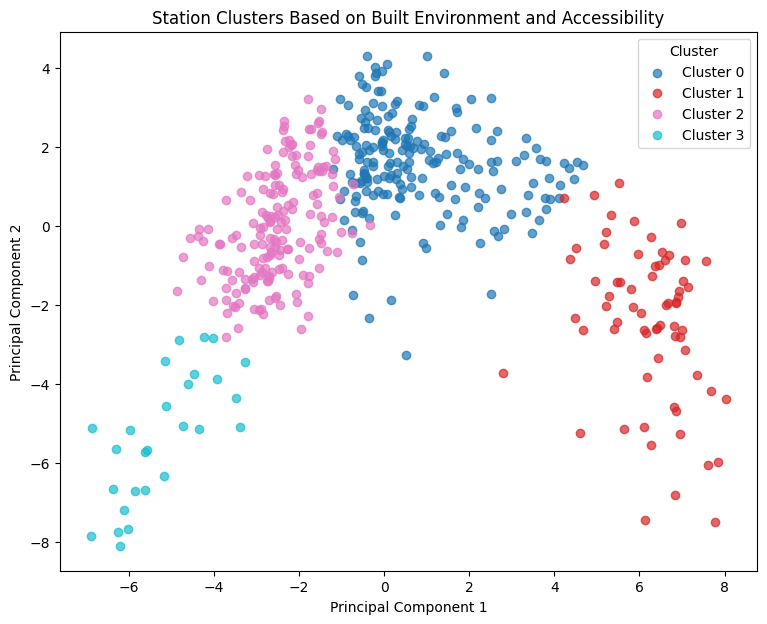

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# Remove ridership columns explicitly if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# FEATURES FOR UNSUPERVISED MODELING
# =========================================================
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

# Keep only features that actually exist in the file
features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("Features used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used:", len(features_available))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_plot["cluster"] = clusters

# =========================================================
# STATION-CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[["station_complex_name", "station_complex_id", "cluster"]]
    .dropna(subset=["cluster"])
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

# Flag IBX stations
station_cluster_df["is_ibx"] = (
    station_cluster_df["station_complex_id"]
    .astype(str)
    .str.startswith("IBX_", na=False)
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

# print("\nStation-cluster membership:")
# print(station_cluster_df)

# Save cluster membership table
station_cluster_df.to_csv("station_clusters.csv", index=False)

# =========================================================
# PRINT STATIONS IN EACH CLUSTER
# =========================================================
# for c in sorted(station_cluster_df["cluster"].unique()):
#     print(f"\nCluster {int(c)}")
#     print(
#         station_cluster_df[station_cluster_df["cluster"] == c][
#             ["station_complex_name", "station_complex_id", "IBX_station"]
#         ].to_string(index=False)
#     )

# =========================================================
# OPTIONAL: IBX SUMMARY
# =========================================================
# print("\nIBX stations by cluster:")
# print(
#     station_cluster_df[station_cluster_df["is_ibx"]]
#     .groupby("cluster")["station_complex_name"]
#     .count()
#     .rename("ibx_station_count")
# )

# =========================================================
# PCA VISUALIZATION
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for cluster, color in zip(range(n_clusters), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Station Clusters Based on Built Environment and Accessibility")
plt.legend(title="Cluster")
plt.show()

# =========================================================
# OPTIONAL: SAVE PCA COORDINATES
# =========================================================
pca_df = df_plot[["station_complex_name", "station_complex_id", "cluster"]].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_pca.csv", index=False)

# print("\nSaved files:")
# print(" - station_clusters.csv")
# print(" - station_clusters_pca.csv")

Features used:
['buffer_area_sqmi', 'population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi_approx', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi']

Rows used for clustering: 464
Number of features used: 35


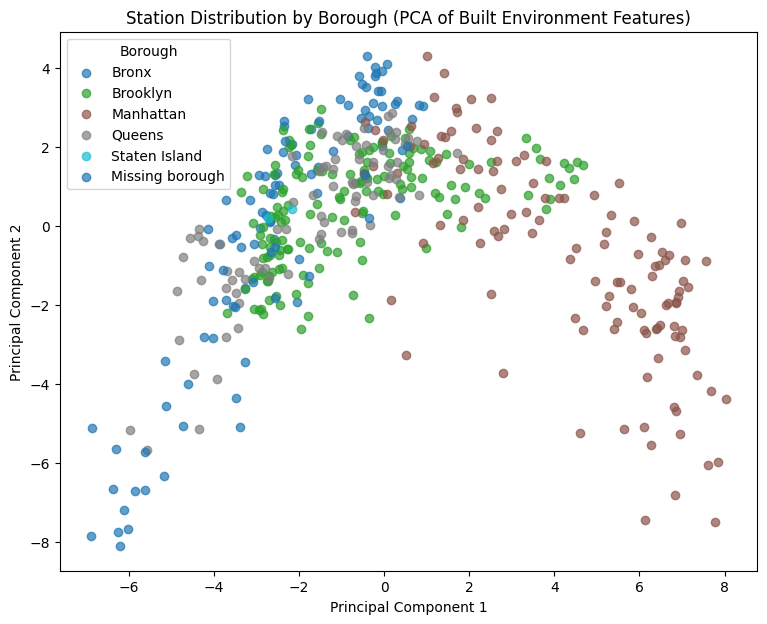

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_panel_weekly_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str)
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str)

# Keep one borough per station_complex_id from ridership
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna(subset=["station_complex_id", "borough"])
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

# Merge borough into feature table
df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

# Remove ridership columns explicitly if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# FEATURES FOR UNSUPERVISED MODELING
# =========================================================
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("Features used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used:", len(features_available))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_plot["cluster"] = clusters

# =========================================================
# STATION-CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[["station_complex_name", "station_complex_id", "borough", "cluster"]]
    .dropna(subset=["cluster"])
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df["is_ibx"] = (
    station_cluster_df["station_complex_id"]
    .astype(str)
    .str.startswith("IBX_", na=False)
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

station_cluster_df.to_csv("station_clusters.csv", index=False)

# =========================================================
# PCA VISUALIZATION (COLOR BY BOROUGH)
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]

plt.figure(figsize=(9, 7))

boroughs = sorted(df_plot["borough"].dropna().unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(boroughs)))

for borough, color in zip(boroughs, colors):
    mask = df_plot["borough"] == borough
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=borough,
        color=color,
        alpha=0.7
    )

# Optional: show stations with missing borough
missing_mask = df_plot["borough"].isna()
if missing_mask.any():
    plt.scatter(
        df_plot.loc[missing_mask, "PC1"],
        df_plot.loc[missing_mask, "PC2"],
        label="Missing borough",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Station Distribution by Borough (PCA of Built Environment Features)")
plt.legend(title="Borough")
plt.show()

# =========================================================
# SAVE PCA COORDINATES
# =========================================================
pca_df = df_plot[
    ["station_complex_name", "station_complex_id", "borough", "cluster"]
].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_pca.csv", index=False)

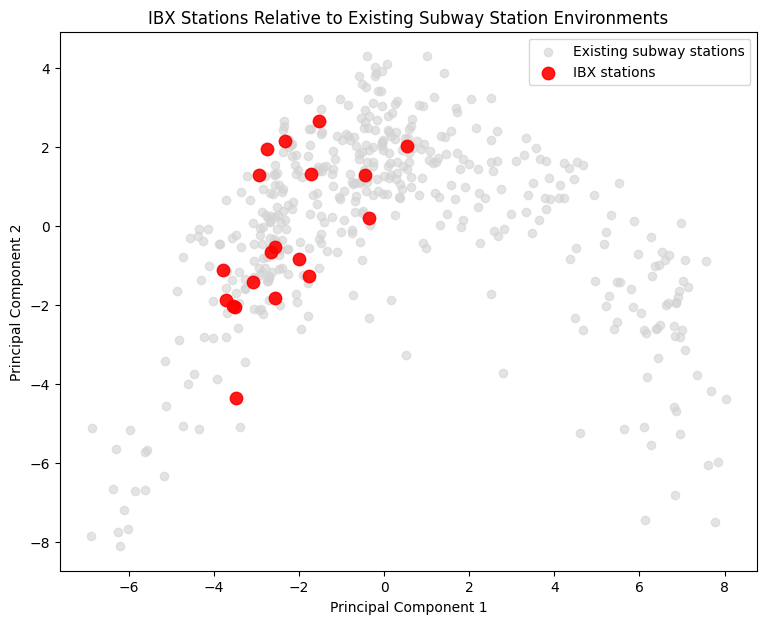

In [61]:
# =========================================================
# PCA VISUALIZATION (IBX vs NON-IBX)
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]

# Flag IBX stations
df_plot["is_ibx"] = df_plot["station_complex_id"].astype(str).str.startswith("IBX_")

plt.figure(figsize=(9,7))

# Non-IBX stations
mask_non_ibx = ~df_plot["is_ibx"]
plt.scatter(
    df_plot.loc[mask_non_ibx, "PC1"],
    df_plot.loc[mask_non_ibx, "PC2"],
    color="lightgray",
    alpha=0.6,
    label="Existing subway stations"
)

# IBX stations
mask_ibx = df_plot["is_ibx"]
plt.scatter(
    df_plot.loc[mask_ibx, "PC1"],
    df_plot.loc[mask_ibx, "PC2"],
    color="red",
    alpha=0.9,
    s=80,
    label="IBX stations"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("IBX Stations Relative to Existing Subway Station Environments")
plt.legend()
plt.show()

# Identify which cluster the IBX stations are in

### **Built Environment Similarity of IBX Stations to Existing Subway Stations**

Based on the **three plots together (IBX overlay, borough coloring, and clusters)**:

### Most similar borough stations to IBX

**Brooklyn and Queens stations are most similar to IBX stations.**

### Why

1. **IBX overlay plot**

   * Red IBX points are concentrated around the **center-left of the feature space**.
   * Very few appear in the **far-right region**.

2. **Cluster plot**

   * Most IBX stations fall in **Cluster 2** (pink).
   * Cluster 2 represents **moderate-density urban environments**.

3. **Borough plot**

   * The **Cluster 2 region overlaps heavily with Brooklyn and Queens stations**.
   * Manhattan stations dominate the **far-right cluster** (Cluster 1), which IBX rarely occupies.

### Interpretation

IBX stations tend to resemble **outer-borough subway environments**, characterized by:

* moderate density
* mixed residential and employment land uses
* moderate multimodal access
* strong bus–subway connectivity

These characteristics are typical of **Brooklyn and Queens corridors** rather than the high-intensity environments of Manhattan.

### Concise statement for your paper

> IBX stations cluster most closely with Brooklyn and Queens subway stations in the built-environment feature space, indicating that the IBX corridor resembles moderate-density outer-borough transit environments rather than the high-intensity station environments typical of Manhattan.


# Hierarchical Clustering

This shows how stations group together in a hierarchy.

## Step 1 — Split IBX vs non-IBX

Replace the filtering section with this:

In [67]:
import pandas as pd

# Read station features dataset
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv")

# Identify IBX stations using station_complex_id
ibx_mask = df["station_complex_id"].astype(str).str.startswith("IBX_", na=False)

# Split dataset
train_df = df[~ibx_mask].copy()   # existing stations
ibx_df = df[ibx_mask].copy()      # IBX stations

# Verify counts
print("Total stations:", len(df))
print("Existing stations:", len(train_df))
print("IBX stations:", len(ibx_df))

# Preview IBX stations
print("\nIBX stations:")
print(ibx_df[["station_complex_id", "station_complex_name"]].head())

Total stations: 464
Existing stations: 445
IBX stations: 19

IBX stations:
    station_complex_id station_complex_name
445              IBX_1     Roosevelt Avenue
446              IBX_2         Grand Avenue
447              IBX_3         Eliot Avenue
448              IBX_4  Metropolitan Avenue
449              IBX_5        Myrtle Avenue


# t-SNE / UMAP Visualization

These show nonlinear structure in the data.

**t-SNE**

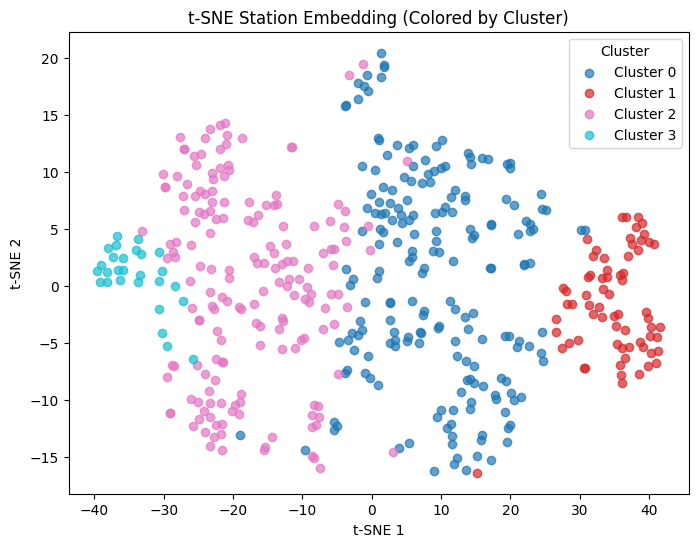

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv")

df["station_complex_id"] = df["station_complex_id"].astype(str)

# Remove ridership columns if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

data = df[features].dropna().copy()
df_plot = df.loc[data.index].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_plot["cluster"] = clusters

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot clusters
colors = plt.cm.tab10(np.linspace(0,1,4))

plt.figure(figsize=(8,6))

for cluster, color in zip(range(4), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        X_tsne[mask,0],
        X_tsne[mask,1],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Station Embedding (Colored by Cluster)")
plt.legend(title="Cluster")
plt.show()

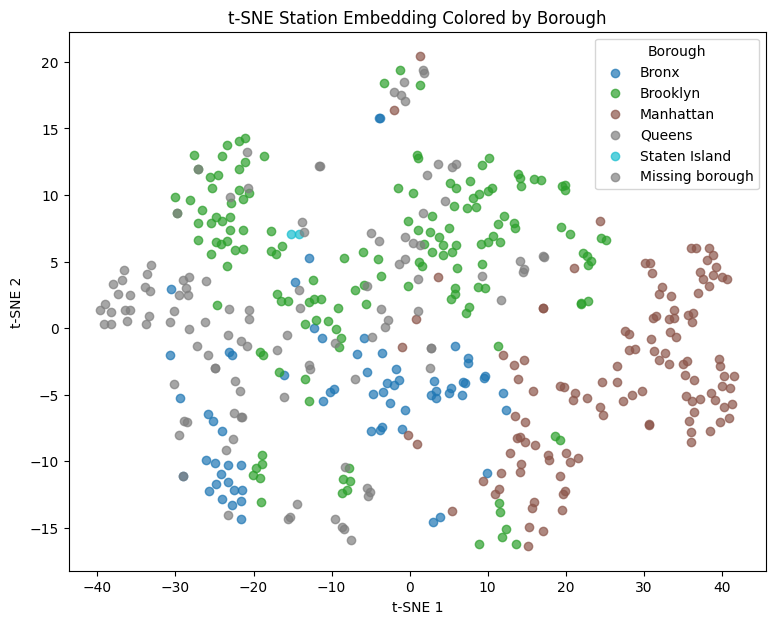

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# =========================================================
# DATA SOURCES
# =========================================================
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"
RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_panel_weekly_post_2023_2024.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str)
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str)

# =========================================================
# MERGE BOROUGH FROM RIDERSHIP
# =========================================================
borough_lookup = (
    ridership[["station_complex_id","borough"]]
    .drop_duplicates(subset="station_complex_id")
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

# =========================================================
# REMOVE RIDERSHIP VARIABLES IF PRESENT
# =========================================================
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# FEATURES
# =========================================================
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

features_available = [f for f in features if f in df.columns]

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

# =========================================================
# SCALE FEATURES
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# =========================================================
# KMEANS CLUSTERING
# =========================================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_plot["cluster"] = clusters

# =========================================================
# T-SNE EMBEDDING
# =========================================================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:,0]
df_plot["TSNE2"] = X_tsne[:,1]

# =========================================================
# PLOT BY BOROUGH
# =========================================================
plt.figure(figsize=(9,7))

boroughs = sorted(df_plot["borough"].dropna().unique())
colors = plt.cm.tab10(np.linspace(0,1,len(boroughs)))

for borough, color in zip(boroughs, colors):

    mask = df_plot["borough"] == borough

    plt.scatter(
        df_plot.loc[mask,"TSNE1"],
        df_plot.loc[mask,"TSNE2"],
        label=borough,
        color=color,
        alpha=0.7
    )

# plot stations missing borough if any
missing = df_plot["borough"].isna()

if missing.any():
    plt.scatter(
        df_plot.loc[missing,"TSNE1"],
        df_plot.loc[missing,"TSNE2"],
        label="Missing borough",
        color="gray",
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Station Embedding Colored by Borough")
plt.legend(title="Borough")
plt.show()

Features used:
['buffer_area_sqmi', 'population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi_approx', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi']

Rows used for analysis: 464
Number of features used: 35
Number of IBX stations: 19


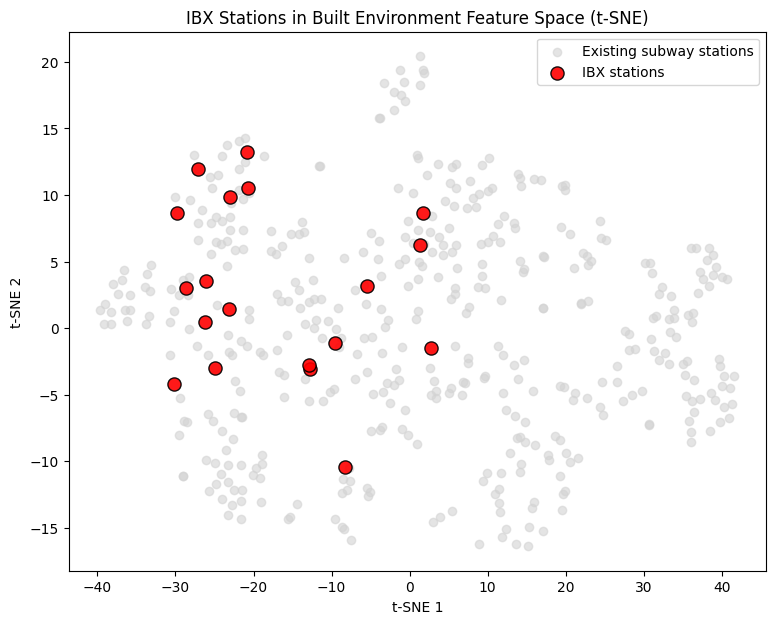


Saved file:
 - station_tsne_ibx.csv


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# Remove ridership columns if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# FEATURES FOR UNSUPERVISED MODELING
# =========================================================
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

# Keep only features that actually exist
features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("Features used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

# Flag IBX stations
df_plot["is_ibx"] = df_plot["station_complex_id"].astype(str).str.startswith("IBX_")

print("\nRows used for analysis:", len(data))
print("Number of features used:", len(features_available))
print("Number of IBX stations:", df_plot["is_ibx"].sum())

# =========================================================
# SCALE FEATURES
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_plot["cluster"] = clusters

# =========================================================
# t-SNE EMBEDDING
# =========================================================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]

# =========================================================
# PLOT: IBX VS NON-IBX
# =========================================================
plt.figure(figsize=(9, 7))

mask_non_ibx = ~df_plot["is_ibx"]
plt.scatter(
    df_plot.loc[mask_non_ibx, "TSNE1"],
    df_plot.loc[mask_non_ibx, "TSNE2"],
    color="lightgray",
    alpha=0.6,
    label="Existing subway stations"
)

mask_ibx = df_plot["is_ibx"]
plt.scatter(
    df_plot.loc[mask_ibx, "TSNE1"],
    df_plot.loc[mask_ibx, "TSNE2"],
    color="red",
    s=90,
    edgecolor="black",
    alpha=0.9,
    label="IBX stations"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("IBX Stations in Built Environment Feature Space (t-SNE)")
plt.legend()
plt.show()

# =========================================================
# OPTIONAL: SAVE OUTPUT
# =========================================================
tsne_df = df_plot[
    ["station_complex_name", "station_complex_id", "cluster", "is_ibx", "TSNE1", "TSNE2"]
].copy()

tsne_df.to_csv("station_tsne_ibx.csv", index=False)

print("\nSaved file:")
print(" - station_tsne_ibx.csv")

### **Built Environment Similarity of IBX Stations to Existing Subway Stations**

Based on the **t-SNE cluster plot, borough-colored plot, and IBX overlay**, the IBX stations are **most similar to Brooklyn and Queens stations**.

### Evidence from the plots

**1. IBX overlay (red points)**
Most IBX stations appear in the **left and center-left regions** of the t-SNE space.

**2. Borough-colored t-SNE plot**
Those same regions are dominated by:

* **Brooklyn (green)**
* **Queens (gray)**

There are also a few nearby **Bronx (blue)** points, but fewer than Brooklyn/Queens.

**3. Cluster plot**
Most IBX stations fall in **Cluster 2**, which corresponds to the **moderate-density outer-borough station environments**—again largely Brooklyn and Queens.

### Interpretation

IBX stations resemble environments with:

* moderate residential density
* mixed residential–commercial land use
* strong bus connections
* moderate subway accessibility

These characteristics are typical of **Brooklyn and Queens subway corridors**, not the very high-intensity station environments in Manhattan.

### Concise conclusion

**IBX stations are most similar to Brooklyn and Queens stations, with some similarity to Bronx stations and little similarity to Manhattan stations.**

### Sentence suitable for your paper

> The t-SNE embedding shows that IBX stations cluster primarily within regions dominated by Brooklyn and Queens stations, indicating that the built environment characteristics of the IBX corridor most closely resemble moderate-density outer-borough transit environments rather than the high-intensity station environments typical of Manhattan.


## Hierarchical Clustering of Subway Stations Based on Built Environment Characteristics



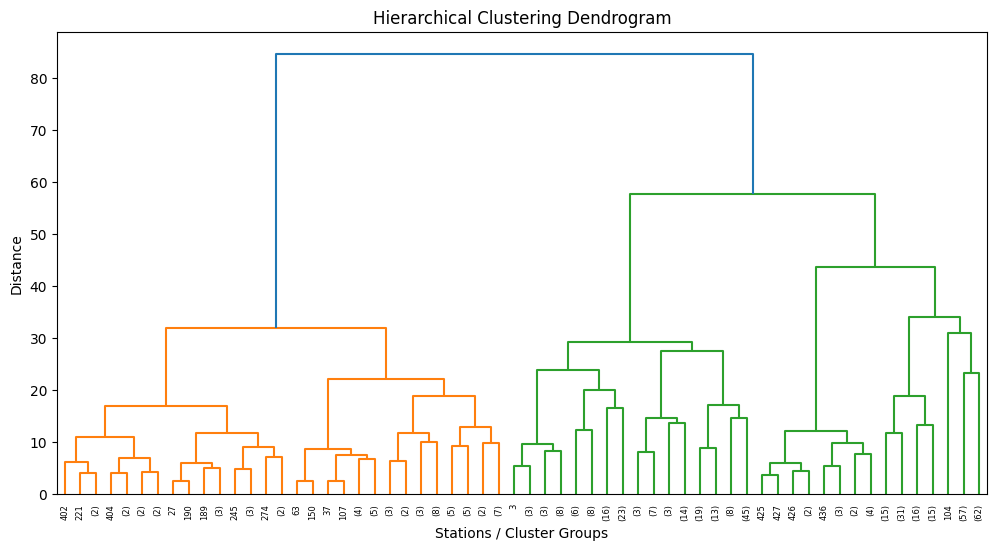

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load features file directly
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv")

# Keep station_complex_id as string so IBX IDs are preserved
df["station_complex_id"] = df["station_complex_id"].astype(str)

# Drop ridership columns if they happen to exist
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# Features describing station environment
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

# Keep only rows with complete feature data
data = df[features].dropna().copy()

# Match original rows used in clustering
df_plot = df.loc[data.index].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Hierarchical clustering
Z = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="level",
    p=5
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Stations / Cluster Groups")
plt.ylabel("Distance")
plt.show()

### Interpretation of the Hierarchical Clustering Dendrogram

The dendrogram illustrates how subway stations group together based on similarities in their surrounding built environment and accessibility characteristics.

#### 1. Two broad station environment types

The dendrogram splits into **two major branches at a high linkage distance (~85)**, indicating that the dataset contains **two fundamentally different types of station environments**. Consistent with the **PCA and t-SNE visualizations**, this separation likely reflects a distinction between:

* **High-intensity urban stations**, characterized by high employment density, extensive multimodal connectivity, and mixed land uses, which are most common in Manhattan and major transit hubs.
* **Moderate- to lower-density stations**, typically located in outer-borough neighborhoods with lower employment density, fewer transit connections, and more residential land uses.

This large separation suggests that the built-environment characteristics surrounding subway stations vary substantially across the system.

#### 2. Subclusters within each major group

Within these two major branches, the dendrogram reveals several **smaller clusters forming at lower linkage distances (approximately 10–30)**. These clusters represent **more nuanced station typologies**, such as:

* moderate-density neighborhood stations
* mixed-use residential–commercial corridors
* major regional transit hubs
* peripheral or lower-density stations

Stations that merge at **very small linkage distances** share highly similar built-environment characteristics.

#### 3. Consistency with PCA, t-SNE, and K-means results

The hierarchical clustering results are consistent with the **four-cluster structure identified using K-means**, as well as the **distinct spatial groupings observed in the PCA and t-SNE embeddings**. Both dimensionality-reduction techniques reveal clear separations among groups of stations with similar built-environment profiles, suggesting that the clustering structure identified in the dendrogram reflects meaningful differences in station environments.

#### 4. Implications for IBX station environments

The PCA and t-SNE analyses show that **IBX stations tend to occupy regions of the feature space associated with moderate-density outer-borough stations**, rather than the high-intensity cluster dominated by Manhattan stations. This suggests that the built environments surrounding IBX stations are most similar to those found along existing **Brooklyn and Queens subway corridors**, with some similarity to stations in the Bronx.

---

### Concise sentence for the paper

> The hierarchical clustering dendrogram reveals two broad station environment types with several nested subclusters, consistent with the groupings observed in the PCA and t-SNE analyses. Together, these results indicate that subway stations can be organized into distinct built-environment typologies, with IBX stations most closely resembling moderate-density outer-borough station environments rather than high-intensity Manhattan stations.



# **Supervised Machine Learning Modeling**

## Random Forest Ridership Model

In [77]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(
"https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# TARGET VARIABLE
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers
    "station_complex",
    "station_complex_name",
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# INDEPENDENT VARIABLES
# =========================================================
features = [

# ---------------------------------------------------------
# DEMOGRAPHICS / DENSITY
# ---------------------------------------------------------
"population_0p5mi",
"pop_density_0p5mi",

# ---------------------------------------------------------
# LAND USE MIX
# ---------------------------------------------------------
"landuse_entropy_0p5mi",
"landuse_entropy_relative_0p5mi",
"landuse_simpson_0p5mi",
"landuse_k_categories_0p5mi",

# ---------------------------------------------------------
# EMPLOYMENT
# ---------------------------------------------------------
"jobs_0p5mi",

# ---------------------------------------------------------
# STREET NETWORK / WALKABILITY
# ---------------------------------------------------------
"intersection_count_0p5mi",
"intersection_density_0p5mi",

# ---------------------------------------------------------
# BIKE ACCESS
# ---------------------------------------------------------
"citibike_count_0p5mi",

# ---------------------------------------------------------
# SOCIOECONOMIC / TRANSIT DEPENDENCY
# ---------------------------------------------------------
"pct_hh_no_vehicle_0p5mi",
"median_hh_income_0p5mi",

# ---------------------------------------------------------
# COMMUTE MODE SHARE
# ---------------------------------------------------------
"pct_transit_0p5mi",
"pct_car_truck_van_0p5mi",
"pct_walked_0p5mi",
"pct_bicycle_0p5mi",
"pct_taxicab_0p5mi",
"pct_other_means_0p5mi",
"pct_wfh_0p5mi",

# ---------------------------------------------------------
# TRANSIT ACCESSIBILITY
# ---------------------------------------------------------
"bus_routes_0p5mi",
"subway_lines_0p5mi",
"commuter_lines_0p5mi",
"dist_to_commuter_stop_mi",

# ---------------------------------------------------------
# ACTIVITY GENERATORS
# ---------------------------------------------------------
"has_university_0p25mi",
"has_university_0p5mi",
"has_hospital_0p25mi",
"has_hospital_0p5mi",
"has_stadium_0p1mi",

# ---------------------------------------------------------
# CULTURAL DESTINATIONS
# ---------------------------------------------------------
"cultural_count_0p25mi",
"cultural_count_0p5mi",
"cultural_count_0p25mi_capped10",
"cultural_count_0p5mi_capped10",

# ---------------------------------------------------------
# PARK ACCESS
# ---------------------------------------------------------
"adjacent_major_park_0p25mi",
"adjacent_major_park_0p5mi"

]

# keep only available columns
features = [f for f in features if f in df.columns]

# =========================================================
# MODEL DATA
# =========================================================
data = df.dropna(subset=features + ["log_ridership"]).copy()

X = data[features]
y = data["log_ridership"]
groups = data["station_complex_id"]

print("Observations used:", len(data))
print("Number of predictors:", len(features))

# =========================================================
# TRAIN / TEST SPLIT (BY STATION)
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# =========================================================
# RANDOM FOREST MODEL
# =========================================================
model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# MODEL PERFORMANCE
# =========================================================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("-------------------")
print("R²:", round(r2,3))
print("RMSE:", round(rmse,3))
print("MAE:", round(mae,3))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 Feature Importances")
print(importance.head(20))

Observations used: 48714
Number of predictors: 34

Model Performance
-------------------
R²: 0.495
RMSE: 0.795
MAE: 0.625

Top 20 Feature Importances
                           feature  importance
6                       jobs_0p5mi    0.352988
13         pct_car_truck_van_0p5mi    0.138644
22        dist_to_commuter_stop_mi    0.071054
10         pct_hh_no_vehicle_0p5mi    0.058390
18                   pct_wfh_0p5mi    0.033327
16               pct_taxicab_0p5mi    0.028019
15               pct_bicycle_0p5mi    0.027890
0                 population_0p5mi    0.027083
1                pop_density_0p5mi    0.025968
19                bus_routes_0p5mi    0.024595
11          median_hh_income_0p5mi    0.022229
9             citibike_count_0p5mi    0.020239
20              subway_lines_0p5mi    0.020143
7         intersection_count_0p5mi    0.016335
8       intersection_density_0p5mi    0.015190
14                pct_walked_0p5mi    0.013514
17           pct_other_means_0p5mi    0.012854
12  

## Newer with Manhattan Stations

Features used:
['population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi', 'week_of_year', 'ye

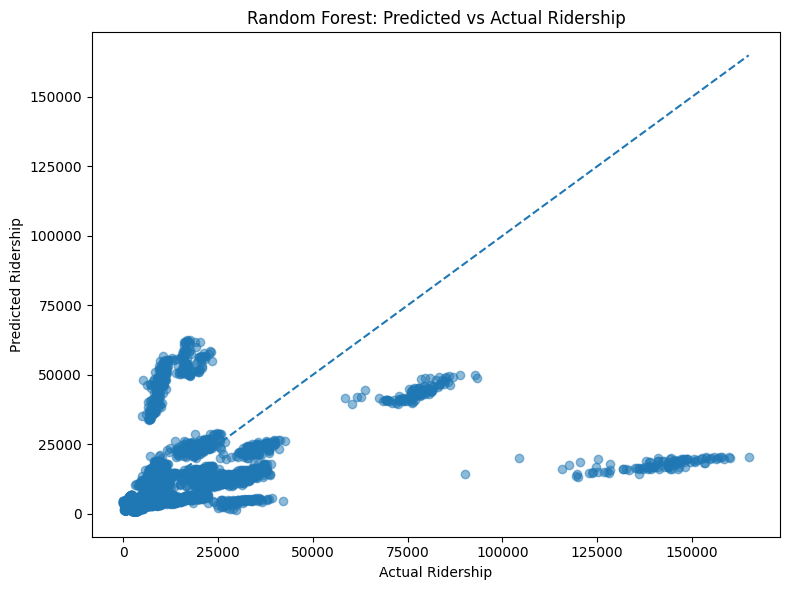

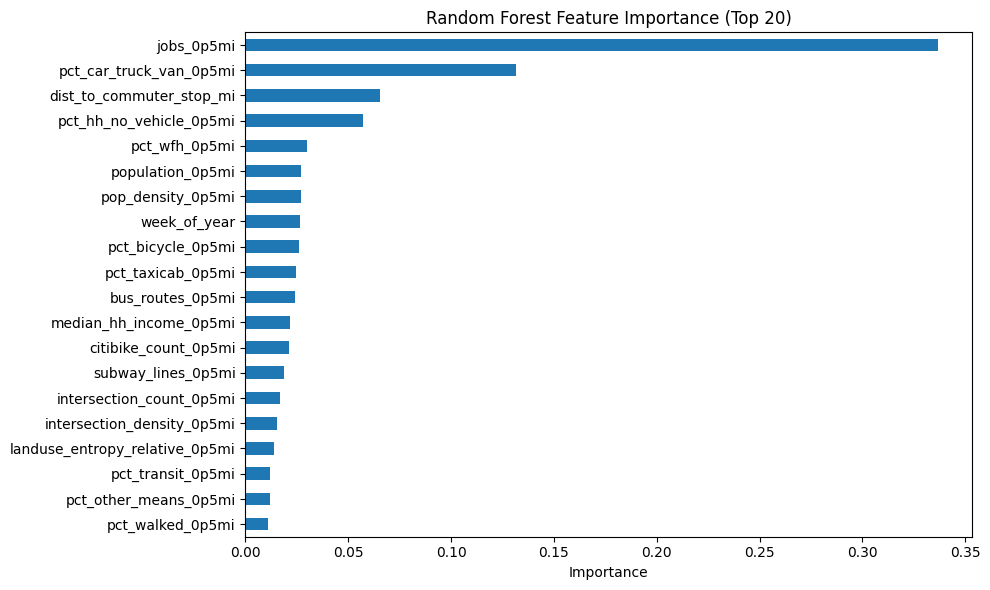


Saved files:
- rf_feature_importance.csv
- rf_predictions.csv


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 7. FAST FINAL RANDOM FOREST MODEL
#    Fixed hyperparameters to avoid expensive grid search
# =========================================================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 11. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 12. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 13. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

## Without Manhattan Stations

Features used:
['population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi', 'week_of_year', 'ye

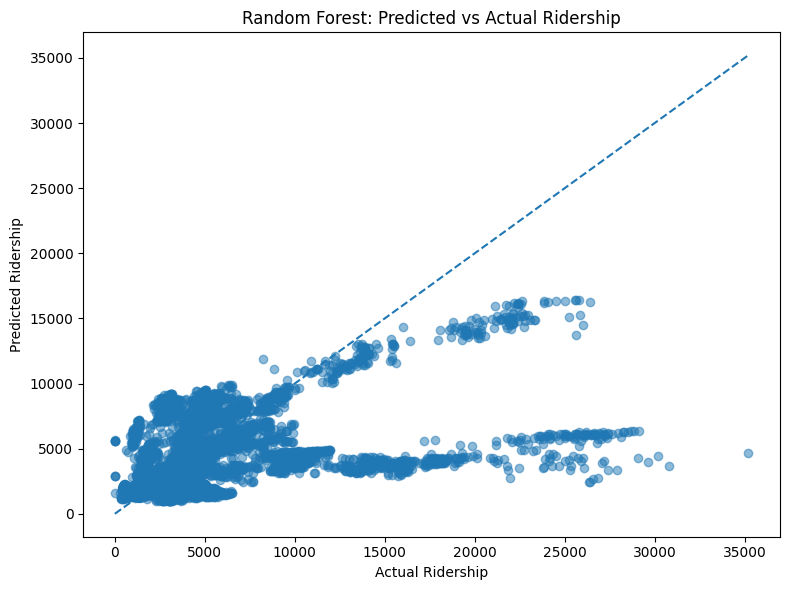

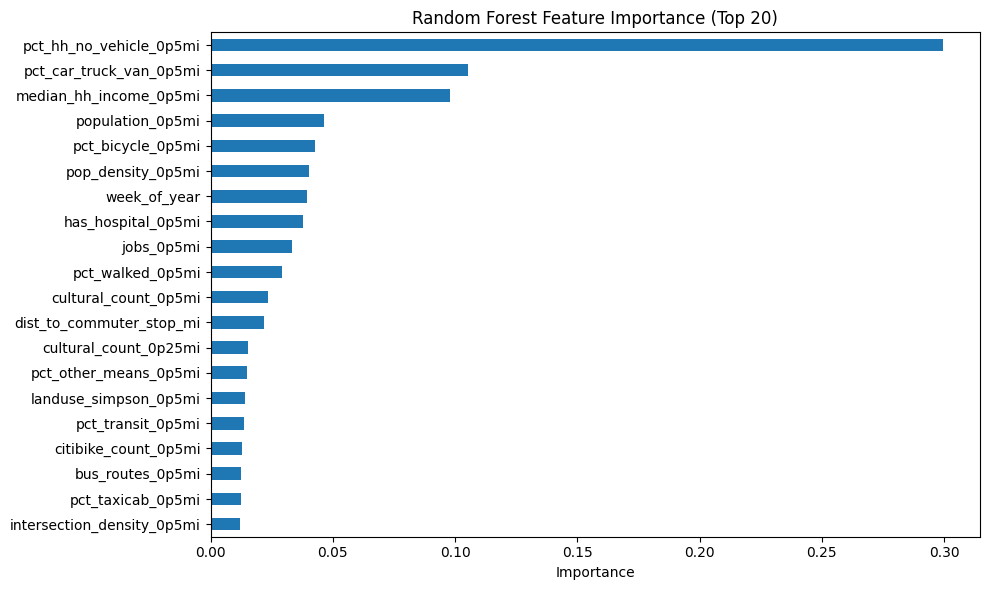


Saved files:
- rf_feature_importance.csv
- rf_predictions.csv


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

# Remove Manhattan stations
df = df[df["borough"] != "Manhattan"].copy()

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 7. FAST FINAL RANDOM FOREST MODEL
#    Fixed hyperparameters to avoid expensive grid search
# =========================================================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 11. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 12. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 13. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

## RF with improvements

Features used:
['log_population_0p5mi', 'log_pop_density_0p5mi', 'log_jobs_0p5mi', 'landuse_entropy_relative_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_mi', 'total_transit_routes_0p5mi', 'transfer_score', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi', 'station_cluster', 'borough_Brooklyn', 

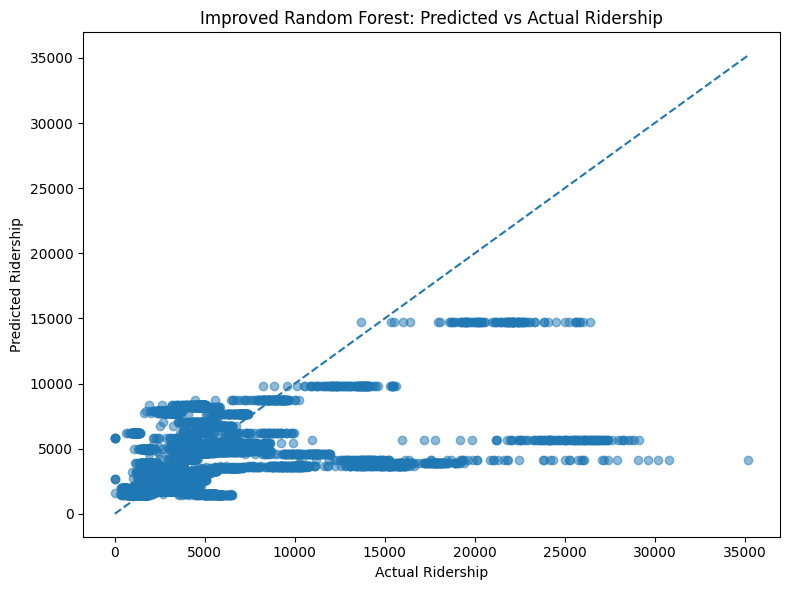

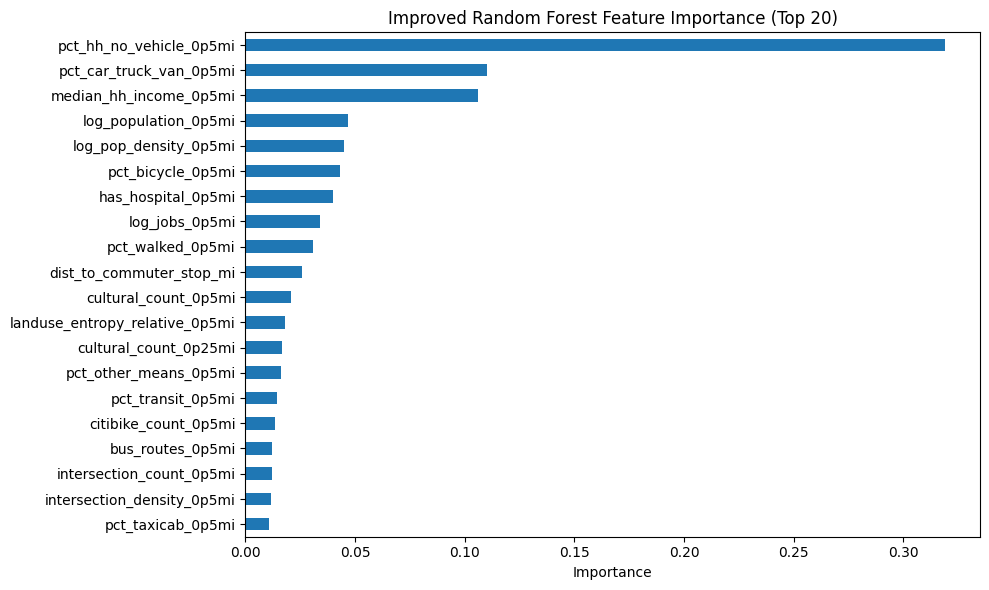


Saved files:
- rf_feature_importance_improved.csv
- rf_predictions_improved.csv


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. REMOVE MANHATTAN
# =========================================================
df = df[df["borough"] != "Manhattan"].copy()

# =========================================================
# 3. CREATE TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 4. DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 5. IMPROVEMENT 1:
#    ADD STATION TYPOLOGY CLUSTERS FROM EARLIER ANALYSIS
# =========================================================
cluster_source = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"
)

cluster_source["station_complex_id"] = cluster_source["station_complex_id"].astype(str)

# Use same built-environment features as clustering stage
cluster_features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

cluster_features = [c for c in cluster_features if c in cluster_source.columns]

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = cluster_source[["station_complex_id"] + cluster_features].dropna().copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_data[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data["station_cluster"] = kmeans.fit_predict(X_cluster)

df = df.merge(
    cluster_data[["station_complex_id", "station_cluster"]].drop_duplicates("station_complex_id"),
    on="station_complex_id",
    how="left"
)

# =========================================================
# 6. IMPROVEMENT 2:
#    REMOVE TIME VARIABLES (week_of_year, year)
# =========================================================
# Do not include week_of_year or year in the final feature list.

# =========================================================
# 7. IMPROVEMENT 3:
#    CREATE TRANSIT CONNECTIVITY FEATURES
# =========================================================
df["total_transit_routes_0p5mi"] = (
    df["bus_routes_0p5mi"].fillna(0)
    + df["subway_lines_0p5mi"].fillna(0)
    + df["commuter_lines_0p5mi"].fillna(0)
)

df["transfer_score"] = (
    df["transfer_subway_station_complexes_0p10mi"].fillna(0)
    + df["transfer_subway_station_complexes_0p25mi"].fillna(0)
)

# =========================================================
# 8. IMPROVEMENT 4:
#    REMOVE REDUNDANT LAND USE METRICS
# =========================================================
# Keep only landuse_entropy_relative_0p5mi from the land-use family.

# =========================================================
# 9. IMPROVEMENT 5:
#    LOG-TRANSFORM HEAVY-TAILED DENSITY VARIABLES
# =========================================================
df["log_jobs_0p5mi"] = np.log1p(df["jobs_0p5mi"])
df["log_population_0p5mi"] = np.log1p(df["population_0p5mi"])
df["log_pop_density_0p5mi"] = np.log1p(df["pop_density_0p5mi"])

# =========================================================
# 10. OPTIONAL STRUCTURAL LOCATION FEATURE
#     OUTER-BOROUGH MODELING BENEFITS FROM BOROUGH
# =========================================================
if "borough" in df.columns:
    borough_dummies = pd.get_dummies(df["borough"], prefix="borough", drop_first=True)
    df = pd.concat([df, borough_dummies], axis=1)

# =========================================================
# 11. DEFINE FINAL INDEPENDENT VARIABLES
# =========================================================
# =========================================================
# DEFINE FINAL INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DENSITY / SCALE (LOG-TRANSFORMED)
    # -----------------------------------------------------
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_jobs_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_relative_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",
    "total_transit_routes_0p5mi",
    "transfer_score",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # STATION TYPOLOGY
    # -----------------------------------------------------
    "station_cluster"
]

# Add borough dummies if they exist
feature_cols += [c for c in df.columns if c.startswith("borough_")]

# Keep only available columns
feature_cols = [c for c in feature_cols if c in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 12. PREP MODEL DATA
# =========================================================
required_cols = feature_cols + [target_col, "ridership", "station_complex_id"]
data = df[required_cols].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 13. TRAIN / TEST SPLIT BY STATION
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 14. FIT RANDOM FOREST
# =========================================================
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 15. PREDICT
# =========================================================
y_pred_log = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 16. EVALUATE
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 17. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance_improved.csv", header=["importance"])

# =========================================================
# 18. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Improved Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 19. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Improved Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 20. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions_improved.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance_improved.csv")
print("- rf_predictions_improved.csv")

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields requested to drop
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

# =========================================================
# 7. TUNE RANDOM FOREST WITH GRID SEARCH
# =========================================================
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train, groups=groups_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV R²:")
print(round(grid.best_score_, 4))

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = best_model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. GROUPED CROSS-VALIDATION ON FULL DATASET
# =========================================================
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=GroupKFold(n_splits=5),
    groups=groups,
    scoring="r2",
    n_jobs=-1
)

print("\nCross-Validation R² Scores:")
print(cv_scores)
print(f"Average CV R²: {cv_scores.mean():.4f}")

# =========================================================
# 11. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 12. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 13. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 14. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

Features used:
['population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_count_0p25mi_capped10', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p25mi', 'adjacent_major_park_0p5mi', 'week_of_year', 'ye

KeyboardInterrupt: 

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# 1. Load merged dataset
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv")

# -----------------------------
# 2. Create log-transformed target
# -----------------------------
# df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# TARGET VARIABLE
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers
    "station_complex",
    "station_complex_name",
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")
# -----------------------------
# 3. Select only ML-ready predictors
#    Removed:
#    - station_complex
#    - station_complex_id
#    - station_complex_name
#    - borough
#    - geometry
#    - latitude
#    - longitude
#    - year
#    - buffer_area_sqmi
#    - distance columns in feet
# -----------------------------
feature_cols = [
    "median_hh_income_0p5mi_approx",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi"
]

target_col = "log_ridership"

# Keep only needed columns and drop missing rows
data = df[feature_cols + [target_col, "annual_weekday_avg_ridership"]].dropna()

X = data[feature_cols]
y = data[target_col]

# -----------------------------
# 4. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Tune Random Forest with GridSearchCV
# -----------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)
print("\nBest CV R2:")
print(grid.best_score_)

# -----------------------------
# 6. Predict on test set
# -----------------------------
y_pred_log = best_model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# -----------------------------
# 7. Evaluate model
# -----------------------------
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print(f"R2 on log scale: {r2_log:.4f}")
print(f"R2 on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# -----------------------------
# 8. Cross-validation on full dataset
# -----------------------------
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nCross-Validation R2 Scores:")
print(cv_scores)
print(f"Average CV R2: {cv_scores.mean():.4f}")

# -----------------------------
# 9. Feature importance
# -----------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importance)

# Save feature importance to CSV
importance.to_csv("rf_feature_importance.csv", header=["importance"])

# -----------------------------
# 10. Predicted vs Actual plot
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Feature importance plot
# -----------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Save predictions
# -----------------------------
results = X_test.copy()
results["actual_log_ridership"] = y_test
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

KeyError: "['median_hh_income_0p5mi_approx', 'annual_weekday_avg_ridership'] not in index"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------------
# 1. Load dataset
# -----------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# -----------------------------------
# 2. Log transform ridership
# -----------------------------------
df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

# -----------------------------------
# 3. Define features (exact variables you requested)
# -----------------------------------
features = [
    "pop_density_0p5mi",
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

target = "log_ridership"

# -----------------------------------
# 4. Clean dataset
# -----------------------------------
data = df[features + [target, "annual_weekday_avg_ridership"]].dropna()

X = data[features]
y = data[target]

# -----------------------------------
# 5. Train/Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------
# 6. Random Forest with hyperparameter tuning
# -----------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# -----------------------------------
# 7. Predictions
# -----------------------------------
y_pred_log = best_model.predict(X_test)

# Convert back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# -----------------------------------
# 8. Evaluation
# -----------------------------------
r2 = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nModel Performance")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# -----------------------------------
# 9. Cross Validation
# -----------------------------------
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")

print("\nCross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# -----------------------------------
# 10. Feature Importance
# -----------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# -----------------------------------
# 11. Feature Importance Plot
# -----------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------------
# 12. Predicted vs Actual Plot
# -----------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# -----------------------------------
# 13. Save results
# -----------------------------------
importance.to_csv("rf_feature_importance.csv")

results = X_test.copy()
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nFiles saved:")
print("rf_feature_importance.csv")
print("rf_predictions.csv")

## Recommended final workflow

- Remove Manhattan stations

- Remove IBX stations

- Remove extreme ridership (>80k)

- Create ridership bins

- Use stratified train/test split

- Train Random Forest

- Predict IBX ridership

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------------
# 1. Load merged dataset
# -----------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# -----------------------------------
# 2. Remove Manhattan stations
# -----------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# -----------------------------------
# 3. Identify IBX stations
#    Assumption: IBX station names start with "ibx"
# -----------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

# Non-IBX stations for training
train_df = df[~ibx_mask].copy()

# IBX stations for prediction
ibx_df = df[ibx_mask].copy()

# -----------------------------------
# 4. Remove extreme outliers from training data
#    Keeps model focused on outer-borough station patterns
# -----------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# -----------------------------------
# 5. Log-transform ridership
# -----------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# -----------------------------------
# 6. Define features
# -----------------------------------
features = [
    "pop_density_0p5mi",
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

# -----------------------------------
# 7. Prepare clean training dataset
# -----------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# -----------------------------------
# 8. Create ridership bins for stratified split
# -----------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# -----------------------------------
# 9. Stratified train/test split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# -----------------------------------
# 10. Random Forest with hyperparameter tuning
# -----------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# -----------------------------------
# 11. Evaluate on test set
# -----------------------------------
y_pred_log = best_model.predict(X_test)

# Convert back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print(f"R2 on log scale: {r2_log:.4f}")
print(f"R2 on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# -----------------------------------
# 12. Cross-validation using stratified folds
#     We stratify on ridership bins
# -----------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified Cross-Validation R2 Scores:")
print(cv_scores)
print(f"Average Stratified CV R2: {cv_scores.mean():.4f}")

# -----------------------------------
# 13. Feature importance
# -----------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importance)

# Save feature importance
importance.to_csv("rf_feature_importance_outer_boroughs.csv", header=["importance"])

# -----------------------------------
# 14. Predicted vs Actual plot
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership\n(Outer Boroughs, Non-IBX)")
plt.tight_layout()
plt.show()

# -----------------------------------
# 15. Feature importance plot
# -----------------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance\n(Outer Boroughs, Non-IBX)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------------
# 16. Predict ridership for IBX stations
# -----------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:
    X_ibx = ibx_pred_df[features]
    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred_ridership = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_log_ridership"] = ibx_pred_log
    ibx_pred_df["predicted_ridership"] = ibx_pred_ridership

    # Save IBX predictions
    ibx_pred_df.to_csv("ibx_ridership_predictions_outer_boroughs.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex", "station_complex_id", "borough", "predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )
else:
    print("\nNo IBX stations found with complete feature data.")

# -----------------------------------
# 17. Save test-set predictions
# -----------------------------------
results = X_test.copy()
results["actual_log_ridership"] = y_test
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance_outer_boroughs.csv")
print("- rf_test_predictions_outer_boroughs.csv")
if len(ibx_pred_df) > 0:
    print("- ibx_ridership_predictions_outer_boroughs.csv")

## Here is the complete updated code with:

- Manhattan stations removed

- IBX stations excluded from training

- population_0p5mi kept

- pop_density_0p5mi removed **keep this change**

- outliers removed (>80k riders)

- stratified train/test split

- Random Forest with hyperparameter tuning

- IBX ridership prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------------
# 1 Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2 Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3 Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4 Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5 Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6 Define predictors (pop_density removed)
# ------------------------------------------------
features = [
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

# ------------------------------------------------
# 7 Clean training dataset
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8 Create ridership bins for stratified split
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9 Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10 Random Forest hyperparameter tuning
# ------------------------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 11 Evaluate model
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 12 Stratified cross validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 13 Feature importance
# ------------------------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

importance.to_csv("rf_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 14 Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance (Outer Boroughs)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 15 Predicted vs actual plot
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16 Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:

    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex","station_complex_id","borough","predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )

else:
    print("\nNo IBX stations found.")

# ------------------------------------------------
# 17 Save test predictions
# ------------------------------------------------
results = X_test.copy()

results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("rf_feature_importance_outer_boroughs.csv")
print("rf_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions.csv")

# xgboost with scaling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from xgboost import XGBRegressor

# ------------------------------------------------
# 1. Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2. Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3. Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4. Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5. Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6. Use top Random Forest features
#    Based on your latest feature importance chart
# ------------------------------------------------
features = [
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "dist_to_commuter_stop_mi",
    "population_0p5mi",
    "pct_walked_0p5mi",
    "citibike_count_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "pct_transit_0p5mi",
    "intersection_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi",
    "subway_lines_0p5mi"
]

# ------------------------------------------------
# 7. Clean training data
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8. Create ridership bins for stratified split
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9. Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10. Build pipeline
#     StandardScaler -> MinMaxScaler -> XGBoost
# ------------------------------------------------
pipeline = Pipeline([
    ("standardize", StandardScaler()),
    ("normalize", MinMaxScaler()),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------
# 11. Hyperparameter tuning
# ------------------------------------------------
param_grid = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 3],
    "xgb__reg_alpha": [0, 0.1],
    "xgb__reg_lambda": [1, 2]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 12. Evaluate on test set
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 13. Stratified cross-validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 14. XGBoost feature importance
# ------------------------------------------------
xgb_model = best_model.named_steps["xgb"]

importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nXGBoost Feature Importance:")
print(importance)

importance.to_csv("xgb_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 15. Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("XGBoost Feature Importance (Outer Boroughs, Non-IBX)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16. Predicted vs Actual plot
# ------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("XGBoost Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 17. Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:
    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions_xgb.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex", "station_complex_id", "borough", "predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )
else:
    print("\nNo IBX stations found with complete feature data.")

# ------------------------------------------------
# 18. Save test predictions
# ------------------------------------------------
results = X_test.copy()
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("xgb_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("xgb_feature_importance_outer_boroughs.csv")
print("xgb_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions_xgb.csv")

# xgboost without scaling (This is better than with scaling)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

# ------------------------------------------------
# 1 Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2 Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3 Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4 Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5 Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6 Top features from Random Forest
# ------------------------------------------------
features = [
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "dist_to_commuter_stop_mi",
    "population_0p5mi",
    "pct_walked_0p5mi",
    "citibike_count_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "pct_transit_0p5mi",
    "intersection_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi",
    "subway_lines_0p5mi"
]

# ------------------------------------------------
# 7 Clean training data
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8 Create ridership bins for stratification
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9 Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10 XGBoost model
# ------------------------------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------
# 11 Hyperparameter tuning
# ------------------------------------------------
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 12 Evaluate model
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 13 Stratified cross validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 14 Feature importance
# ------------------------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nXGBoost Feature Importance:")
print(importance)

importance.to_csv("xgb_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 15 Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16 Predicted vs actual plot
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("XGBoost Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 17 Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:

    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions_xgb.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex","station_complex_id","borough","predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )

else:
    print("\nNo IBX stations found.")

# ------------------------------------------------
# 18 Save predictions
# ------------------------------------------------
results = X_test.copy()

results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("xgb_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("xgb_feature_importance_outer_boroughs.csv")
print("xgb_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions_xgb.csv")

## Below is the full code to run SHAP on your trained XGBoost model.

### 1️ Install SHAP (Colab only)

Run once.

In [ ]:
!pip install shap

### 2️ Load libraries

In [ ]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb

# Create SHAP explainer using the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer(X_train)

# Global feature importance plot
shap.summary_plot(shap_values, X_train)

SHAP analysis indicates that the most influential predictor of subway ridership is pct_hh_no_vehicle_0p5mi, the percentage of households without access to a private vehicle within a half-mile of the station. Higher values of this variable consistently increase predicted ridership, indicating strong transit dependence in areas with lower car ownership. The second most important predictor is jobs_0p5mi, representing employment density near the station; stations located in areas with higher numbers of nearby jobs exhibit substantially higher ridership, reflecting the role of employment centers as major trip generators. Additional important predictors include dist_to_commuter_stop_mi, where stations closer to commuter rail stops show higher predicted ridership, and citibike_count_0p5mi and bus_routes_0p5mi, which capture multimodal connectivity through micromobility and bus feeder networks. Built environment variables such as pct_walked_0p5mi and population_0p5mi also contribute positively to ridership, indicating that walkable and densely populated areas support higher transit demand. In contrast, variables such as pct_wfh_0p5mi, intersection_density_0p5mi, and landuse_simpson_0p5mi show relatively small marginal effects once the primary accessibility and density variables are accounted for.

# LightGBM

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load data
df = pd.read_csv("ridership_station_features_merged.csv")

# Remove Manhattan
df = df[df["borough"] != "Manhattan"]

# Identify IBX stations
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()

# Remove extreme outliers
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

# Log transform ridership
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

# CatBoost

In [ ]:
!pip install catboost

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

## Multiple Linear Regression

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("ridership_station_features_merged.csv")

# Target variable
y = df["annual_weekday_avg_ridership"]

# Variables selected from RF + XGBoost importance
X = df[[
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "population_0p5mi",
    "citibike_count_0p5mi",
    "pct_walked_0p5mi",
    "pct_transit_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "intersection_density_0p5mi",
    "pct_wfh_0p5mi",
    "landuse_entropy_0p5mi"
]]

# Remove missing rows
data = pd.concat([y, X], axis=1).dropna()

y = data["annual_weekday_avg_ridership"]
X = data.drop(columns=["annual_weekday_avg_ridership"])

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("ridership_station_features_merged.csv")

# Remove Manhattan stations
df = df[df["borough"] != "Manhattan"].copy()

# Log transform target
df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

y = df["log_ridership"]

# Predictors selected from ML importance
X = df[[
    "jobs_0p5mi",
    "population_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "subway_lines_0p5mi",
    "bus_routes_0p5mi",
    "landuse_entropy_0p5mi"
]]

# Remove missing rows
data = pd.concat([y, X], axis=1).dropna()

y = data["log_ridership"]
X = data.drop(columns=["log_ridership"])

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

# Ridge Regression (Baseline)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

# Neural Network (MLP)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64,32),
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(ridership_panel_weekly.columns.tolist())
print(ridership_panel_weekly.head())

In [ ]:
print("Before save:", ridership_panel_weekly.columns.tolist())

ridership_panel_weekly = finalize_weekly(ridership_panel_weekly)

print("After finalize:", ridership_panel_weekly.columns.tolist())

save_df_both(ridership_panel_weekly, "ridership_panel_weekly")

In [ ]:
"""
===============================================================================
NYC Subway Ridership Panel Builder
STATION-COMPLEX LEVEL
WEEKLY + ANNUAL WEEKDAY AVERAGE (Mon–Fri) RIDERSHIP
PRE-COVID, POST-COVID, AND COMBINED OUTPUTS
WITH PRE-COVID STATION -> STATION COMPLEX CROSSWALK
===============================================================================

PURPOSE
-------
This script builds clean, consistent weekly and annual ridership panel datasets
at the station_complex level for NYC Subway (NYCT).

Outputs:
    WEEKLY:
        - ridership_panel_pre_weekly
        - ridership_panel_post_weekly
        - ridership_panel_combined_weekly

    ANNUAL:
        - ridership_panel_pre_annual
        - ridership_panel_post_annual
        - ridership_panel_combined_annual

All values are standardized to WEEKDAY averages (Mon–Fri only).

WEEKLY:
    ridership = average DAILY weekday ridership within each week

ANNUAL:
    annual_weekday_avg_ridership = average DAILY weekday ridership within each year

Metadata retained:
    - station_complex
    - station_complex_id
    - borough
    - latitude
    - longitude
    - geometry

Files saved:
    - local CSV + Parquet
    - Google Drive CSV + Parquet

IMPORTANT NOTE
--------------
POST-COVID (2023–2024) ridership is natively available at the station_complex level.

PRE-COVID (2018–2019) turnstile data is available at the station field level.
This script maps pre-COVID turnstile station names to official station_complex
values using the attached MTA station/complex crosswalk file, then aggregates
daily ridership to the station_complex level before building weekly/annual panels.

FORECASTING WINDOW
------------------
Recommended for IBX forecasting:
    - Pre-COVID:  2018–2019
    - Post-COVID: 2023–2024
    - Exclude:    2020–2022
===============================================================================
"""

import pandas as pd
import numpy as np
import requests
import io
import time
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Google Drive save directory
DRIVE_BASE = "/content/drive/MyDrive/capstone"

# Attached station-complex crosswalk file
STATION_COMPLEX_CSV = "/mnt/data/MTA_Subway_Stations_and_Complexes.csv"

# Optional manual alias fixes for stubborn turnstile names
MANUAL_STATION_ALIASES = {
    # "ATL AV BARCLAYS": "ATLANTIC AV BARCLAYS CTR",
    # "42 ST PORT AUTH": "42 ST PORT AUTHORITY BUS TERMINAL",
    # "BWAY LAFAYETTE": "BROADWAY LAFAYETTE",
}

# =========================================================
# NETWORK HELPER
# =========================================================
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(f"Retryable status {r.status_code}; sleeping {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                r.raise_for_status()

            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(f"Request failed on attempt {attempt+1}/{MAX_RETRIES}; sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# NAME NORMALIZATION HELPERS
# =========================================================
def normalize_station_name(x: str) -> str:
    """
    Normalize station names so turnstile station labels match
    official station-complex naming as closely as possible.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    # Standard replacements
    s = s.replace("&", " AND ")
    s = s.replace("@", " AT ")

    # Common abbreviations / variants
    s = s.replace("AVENUE", "AV")
    s = s.replace("AVE", "AV")
    s = s.replace("STREET", "ST")
    s = s.replace("SAINT", "ST")
    s = s.replace("PLAZA", "PLZ")
    s = s.replace("CENTER", "CTR")
    s = s.replace("CENTRE", "CTR")
    s = s.replace("SQUARE", "SQ")
    s = s.replace("PARKWAY", "PKWY")
    s = s.replace("BOULEVARD", "BLVD")
    s = s.replace("BARCLAYS CENTER", "BARCLAYS CTR")

    # Remove route text in parentheses if present
    s = s.replace("(", " ")
    s = s.replace(")", " ")

    # Collapse punctuation to spaces
    s = (
        s.replace("/", " ")
         .replace("-", " ")
         .replace(",", " ")
         .replace(".", " ")
         .replace("'", "")
    )

    # Compress whitespace
    s = " ".join(s.split())

    # Manual overrides last
    s = MANUAL_STATION_ALIASES.get(s, s)

    return s


def strip_display_routes(x: str) -> str:
    """
    Remove trailing route labels from Display Name, e.g.
    '14 St/6 Av (1,2,3,L,F,M)' -> '14 St/6 Av'
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    if "(" in s:
        s = s.split("(")[0].strip()
    return s

# =========================================================
# BUILD STATION -> STATION COMPLEX CROSSWALK
# =========================================================
def build_station_complex_crosswalk(csv_path: str) -> pd.DataFrame:
    """
    Build a name-based crosswalk from possible station aliases to:
        - station_complex
        - station_complex_id
        - borough
        - latitude
        - longitude
        - geometry

    Uses multiple aliases from the attached complex table:
        - Stop Name
        - Display Name (route text removed)
        - Constituent Station Names (split by ;)
    """
    src = pd.read_csv(csv_path)

    required_cols = [
        "Stop Name",
        "Complex ID",
        "Borough",
        "Latitude",
        "Longitude",
    ]
    missing = [c for c in required_cols if c not in src.columns]
    if missing:
        raise ValueError(f"Crosswalk file missing required columns: {missing}")

    src["station_complex"] = src["Stop Name"].astype(str).str.strip()
    src["station_complex_id"] = pd.to_numeric(src["Complex ID"], errors="coerce")
    src["borough"] = src["Borough"].astype(str).str.strip()
    src["latitude"] = pd.to_numeric(src["Latitude"], errors="coerce")
    src["longitude"] = pd.to_numeric(src["Longitude"], errors="coerce")

    src["geometry"] = np.where(
        src["latitude"].notna() & src["longitude"].notna(),
        "POINT (" + src["longitude"].astype(str) + " " + df["latitude"].astype(str) + ")",
        np.nan
    )

In [ ]:
"""
===============================================================================
NYC Subway Ridership Panel Builder
WEEKLY WEEKDAY AVERAGE (Mon–Fri) RIDERSHIP
===============================================================================

PURPOSE
-------
This script builds a clean, consistent weekly ridership panel dataset at the
station_complex level for NYC Subway (NYCT).

The final output is:

    station_complex × week_start × year

Where:
    ridership = average DAILY ridership over weekdays (Mon–Fri) within that week

This dataset is designed for:
    - Machine learning modeling
    - Station-level ridership forecasting
    - IBX (Interborough Express) demand prediction
    - Structural transit demand analysis

The script combines:
    • Pre-COVID data (2018–2019)
    • Post-COVID data (2023–2024)

All values are standardized to WEEKLY WEEKDAY AVERAGES to ensure consistency
across years.

-------------------------------------------------------------------------------
DATA SOURCES
-------------------------------------------------------------------------------

POST-COVID (2023–2024)
    Source: NY.gov Socrata dataset (wujg-7c2s)
    Contains already-aggregated daily ridership totals by station_complex.
    Server-side SoQL queries are used to efficiently fetch daily totals in
    a single request per year.

PRE-COVID (2018–2019)
    Source: NY.gov Socrata turnstile datasets:
        2018 -> bjcb-yee3
        2019 -> xfn5-qji9

    These contain raw cumulative turnstile ENTRY counters per device.

    Because turnstile data are cumulative, actual ridership must be computed
    as:

        delta = current_entries − previous_entries

    Special handling is implemented to:
        • Correctly compute deltas across paginated API responses
        • Prevent undercounting at page boundaries
        • Clip unrealistic spikes and counter resets
        • Aggregate device-level entries to station-level daily totals

-------------------------------------------------------------------------------
AGGREGATION LOGIC
-------------------------------------------------------------------------------

Step 1: Convert raw turnstile counters to daily station totals.
Step 2: Filter to weekdays only (Mon–Fri).
Step 3: Define week_start as the Monday of each week.
Step 4: Compute WEEKLY WEEKDAY AVERAGE:

        weekly ridership = mean(daily weekday ridership within week)

Important:
    This script does NOT compute weekly totals.
    It computes the average daily ridership over weekdays within each week.

So if a value is 25,000:
    That means ~25,000 riders per weekday during that week.

-------------------------------------------------------------------------------
OUTPUT
-------------------------------------------------------------------------------

Final DataFrame: ridership_panel_weekly

Columns:
    - station_complex : station-level unit of analysis
    - week_start      : Monday of each week
    - ridership       : average weekday ridership (daily average within week)
    - year            : year of observation

Estimated size:
    ~425 station complexes
    ~52 weeks per year
    4 years (2018, 2019, 2023, 2024)
    ≈ 85,000–90,000 rows

-------------------------------------------------------------------------------
WHY WEEKLY WEEKDAY AVERAGES?
-------------------------------------------------------------------------------

This format:
    • Reduces daily volatility (weather, holidays, disruptions)
    • Preserves structural station-level demand patterns
    • Aligns with transportation planning practice
    • Improves stability for machine learning models
    • Ensures comparability across pre- and post-COVID years

-------------------------------------------------------------------------------
PERFORMANCE FEATURES
-------------------------------------------------------------------------------

The script includes:
    • Persistent HTTP session (connection pooling)
    • Gzip compression for faster downloads
    • Retry logic with exponential backoff
    • Deterministic ordering for correct pagination
    • Efficient vectorized accumulation
    • Protection against turnstile counter resets

-------------------------------------------------------------------------------
INTENDED USE
-------------------------------------------------------------------------------

This dataset is appropriate for:
    - Linear regression
    - Random Forest
    - Gradient Boosting (XGBoost)
    - Panel data modeling
    - Station-level ridership forecasting
    - IBX station demand extrapolation

===============================================================================
"""

import pandas as pd
import numpy as np
import requests, io, time
from datetime import date, timedelta

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True
def _log(msg):
    if DEBUG:
        print(msg, flush=True)

# Use a persistent Session (connection pooling) + gzip/deflate compression
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

# Centralized network config (timeout + retries + exponential backoff)
TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Wrap Socrata CSV requests in a retrying helper (handles throttling + transient errors)
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(BACKOFF_BASE_SEC * (2 ** attempt))
                continue
            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))
        except Exception as e:
            last_err = e
            time.sleep(BACKOFF_BASE_SEC * (2 ** attempt))
    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# DAILY -> WEEKLY WEEKDAY AVERAGES
# =========================================================
# week_start = Monday of each week
# ridership = average DAILY ridership over weekdays (Mon–Fri) within each week
def daily_to_weekly(daily: pd.DataFrame, weekdays_only: bool) -> pd.DataFrame:
    if daily.empty:
        return pd.DataFrame(columns=["week_start", "station_complex", "ridership"])

    daily = daily.copy()
    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    daily["ridership"] = pd.to_numeric(daily["ridership"], errors="coerce")
    daily = daily.dropna(subset=["date", "ridership", "station_complex"])

    if weekdays_only:
        daily = daily[daily["date"].dt.weekday < 5].copy()  # Mon–Fri only

    daily["week_start"] = daily["date"] - pd.to_timedelta(daily["date"].dt.weekday, unit="D")

    # IMPORTANT CHANGE: weekly weekday AVERAGE (mean), not total (sum)
    weekly = (
        daily.groupby(["week_start", "station_complex"], as_index=False)["ridership"]
        .mean()
    )
    return weekly.sort_values(["station_complex", "week_start"])


# =========================================================
# POST-COVID (2023–2024): FAST (1 request per year)
# =========================================================
# Use wujg-7c2s (timestamp-based) and do server-side aggregation to DAILY totals
POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

def fetch_daily_year_post(year: int) -> pd.DataFrame:
    start_iso = f"{year}-01-01"
    end_iso   = f"{year+1}-01-01"

    # SoQL group-by to return daily totals by station_complex (small + fast)
    params = {
        "$select": "date_trunc_ymd(transit_timestamp) AS date, station_complex, sum(ridership) AS ridership",
        "$where": f"transit_timestamp >= '{start_iso}T00:00:00.000' AND transit_timestamp < '{end_iso}T00:00:00.000'",
        "$group": "date, station_complex",
        "$limit": 500000
    }
    _log(f"POST {year}: fetching daily grouped in ONE request...")
    df = _request_csv(POST_BASE_URL, params)
    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")
    df = df.dropna(subset=["date"])
    return df

def fetch_weekly_post(year: int, weekdays_only: bool = True) -> pd.DataFrame:
    daily = fetch_daily_year_post(year)
    weekly = daily_to_weekly(daily, weekdays_only=weekdays_only)
    weekly["year"] = year
    _log(f"POST {year}: weekly obs = {len(weekly):,}")
    return weekly


# =========================================================
# PRE-COVID (2018–2019): Correct deltas across pages + faster accumulate
# =========================================================
# Switch from scraping MTA weekly text files to NY.gov Socrata datasets per year
YEAR_DATASET = {
    2018: "bjcb-yee3",
    2019: "xfn5-qji9",
}

TURNSTILE_COLS = ["c_a", "unit", "scp", "station", "date", "time", "entries"]

def socrata_page(dataset_id: str, offset: int, limit: int = 50000) -> pd.DataFrame:
    base_url = f"https://data.ny.gov/resource/{dataset_id}.csv"
    params = {
        "$select": ",".join(TURNSTILE_COLS),
        "$limit": limit,
        "$offset": offset,
        # enforce deterministic ordering so paging is consistent AND diffs are correct
        "$order": "c_a, unit, scp, date, time"
    }
    return _request_csv(base_url, params)

def weekly_from_nygov_turnstiles(year: int, weekdays_only: bool = True, limit: int = 50000) -> pd.DataFrame:
    dataset_id = YEAR_DATASET[year]
    _log(f"\nPRE {year}: aggregating from {dataset_id} (paged + correct cross-page diffs)...")

    offset = 0

    # Persist last entries per device across pages (fixes undercount bug at page boundaries)
    last_entries = {}  # (c_a, unit, scp) -> last entries float

    # Accumulate daily totals in a pandas Series (fast vectorized add)
    daily_series = None  # MultiIndex (date, station) -> ridership

    while True:
        df = socrata_page(dataset_id, offset=offset, limit=limit)
        if df.empty:
            break

        fetched = len(df)
        offset += fetched
        _log(f"{dataset_id}: fetched {fetched:,} rows | total fetched {offset:,}...")

        # types/clean
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["entries"] = pd.to_numeric(df["entries"], errors="coerce")
        df = df.dropna(subset=["date","entries","c_a","unit","scp","station","time"]).copy()

        # safety year filter
        df = df[df["date"].dt.year == year].copy()
        if df.empty:
            if fetched < limit:
                break
            continue

        # ensure proper sort
        df = df.sort_values(["c_a","unit","scp","date","time"])

        # device key
        df["_dev"] = list(zip(df["c_a"], df["unit"], df["scp"]))

        # within-page diff
        df["delta"] = df.groupby("_dev")["entries"].diff()

        # Fix first row per device in the page using last_entries from prior page
        first_mask = df.groupby("_dev").cumcount() == 0
        if first_mask.any():
            prev = df.loc[first_mask, "_dev"].map(last_entries)
            df.loc[first_mask, "delta"] = df.loc[first_mask, "entries"] - prev

        # Update last_entries for next page
        tail = df.groupby("_dev", as_index=False).tail(1)
        for k, v in zip(tail["_dev"], tail["entries"]):
            last_entries[k] = float(v)

        # clip bad deltas (counter resets / spikes)
        df["delta"] = pd.to_numeric(df["delta"], errors="coerce")
        df["delta"] = df["delta"].clip(lower=0, upper=50000)

        # daily station totals for this page
        chunk_daily = df.groupby(["date","station"])["delta"].sum()

        # fast accumulation via Series.add (no giant concatenations)
        if daily_series is None:
            daily_series = chunk_daily
        else:
            daily_series = daily_series.add(chunk_daily, fill_value=0.0)

        if fetched < limit:
            break

    if daily_series is None or daily_series.empty:
        _log(f"PRE {year}: no usable data.")
        return pd.DataFrame(columns=["week_start","station_complex","ridership","year"])

    daily = daily_series.reset_index()
    daily.columns = ["date", "station_complex", "ridership"]

    # Convert to WEEKLY WEEKDAY AVERAGES (mean Mon–Fri)
    weekly = daily_to_weekly(daily, weekdays_only=weekdays_only)
    weekly["year"] = year
    _log(f"PRE {year}: weekly obs = {len(weekly):,}")
    return weekly


# =========================================================
# RUN: Build panel (WEEKLY WEEKDAY AVERAGES)
# =========================================================
# POST: force weekdays_only=True for consistency with PRE
rid_2023_weekly = fetch_weekly_post(2023, weekdays_only=True)
rid_2024_weekly = fetch_weekly_post(2024, weekdays_only=True)
rid_post_weekly = pd.concat([rid_2023_weekly, rid_2024_weekly], ignore_index=True)
_log(f"POST (2023–2024) weekly obs: {len(rid_post_weekly):,}")

# PRE: weekdays_only=True (already the default)
pre_years = [2018, 2019]
rid_pre_weekly = pd.concat(
    [weekly_from_nygov_turnstiles(y, weekdays_only=True) for y in pre_years],
    ignore_index=True
)
_log(f"PRE (2018–2019) weekly obs: {len(rid_pre_weekly):,}")

# Final output: WEEKLY WEEKDAY AVERAGE panel (station_complex, week_start)
ridership_panel_weekly = pd.concat([rid_pre_weekly, rid_post_weekly], ignore_index=True)
ridership_panel_weekly = ridership_panel_weekly.sort_values(["station_complex","week_start"])
_log("Weekly weekday-average ridership panel built.")

# =========================================================
# SAVE OUTPUT
# =========================================================

# Save as Parquet (fast, compact)
ridership_panel_weekly.to_parquet("ridership_panel_weekly.parquet", index=False)
print("Dataset saved as ridership_panel_weekly.parquet")

# Save as CSV
ridership_panel_weekly.to_csv("ridership_panel_weekly.csv", index=False)
print("Dataset saved as ridership_panel_weekly.csv")


# =========================================================
# SAVE OUTPUT TO GOOGLE DRIVE
# =========================================================

PARQUET_PATH = "/content/drive/MyDrive/capstone/ridership_panel_weekly.parquet"
CSV_PATH = "/content/drive/MyDrive/capstone/ridership_panel_weekly.csv"

ridership_panel_weekly.to_parquet(PARQUET_PATH, index=False)
ridership_panel_weekly.to_csv(CSV_PATH, index=False)

print(f"Saved parquet → {PARQUET_PATH}")
print(f"Saved csv → {CSV_PATH}")

display(ridership_panel_weekly.head())
print(ridership_panel_weekly.groupby("year")["ridership"].mean())

In [ ]:
#No changes made-seems same logic as previous block
# =========================================================
# OUTCOME VARIABLE: Subway Ridership (Existing NYC Subway Station Complexes)
#
# Goal:
#   Pull *actual* ridership for existing subway station complexes from NY State Open Data
#   and merge it into your `station_buffers` table.
#
# Data source (Socrata / SODA API):
#   - 2020–2024: https://data.ny.gov/resource/wujg-7c2s.json  :contentReference[oaicite:0]{index=0}
#   - 2025:      https://data.ny.gov/resource/5wq4-mkjj.json  :contentReference[oaicite:1]{index=1}
#
# Key fields used (from API):
#   transit_timestamp, transit_mode, station_complex_id, station_complex, ridership  :contentReference[oaicite:2]{index=2}
#
# Output columns added to station_buffers:
#   - ridership_total_{YEAR}
#   - ridership_avg_daily_{YEAR}        (total / #days in the period)
#   - ridership_avg_hourly_{YEAR}       (total / #hours in the period)
#
# Join logic:
#   station_buffers.stop_id (string) == station_complex_id (string)
#   IBX_* will not match => ridership stays NaN (as desired for later prediction)
#
# Notes:
#   - This queries an AGGREGATED group-by result (small) so it’s fast.
#   - Includes basic retry/backoff for throttling.
# =========================================================

import pandas as pd
import numpy as np
import requests
import time
from datetime import datetime

# -----------------------------
# User settings
# -----------------------------
YEAR = 2024  # change to 2020–2025
TRANSIT_MODE = "subway"

# If you want a custom window instead of full year:
#   set START_DATE / END_DATE as "YYYY-MM-DD"
#   and set USE_FULL_YEAR = False
USE_FULL_YEAR = True
START_DATE = f"{YEAR}-01-01"
END_DATE   = f"{YEAR}-12-31"

# Retry / paging
TIMEOUT = 60
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# -----------------------------
# Pick dataset by year
# -----------------------------
def soda_dataset_for_year(y: int) -> str:
    # 2020–2024 dataset:
    if 2020 <= y <= 2024:
        return "wujg-7c2s"
    # 2025 dataset:
    if y == 2025:
        return "5wq4-mkjj"
    raise ValueError("Supported YEAR values: 2020–2025")

DATASET_ID = soda_dataset_for_year(YEAR)
BASE_URL = f"https://data.ny.gov/resource/{DATASET_ID}.json"

# -----------------------------
# Helpers
# -----------------------------
def _dt(s: str) -> datetime:
    return datetime.strptime(s, "%Y-%m-%d")

def _days_inclusive(start_date: str, end_date: str) -> int:
    return (_dt(end_date) - _dt(start_date)).days + 1

def _hours_inclusive(start_date: str, end_date: str) -> int:
    # hourly ridership table: assume each day has 24 hourly timestamps (inclusive days)
    return _days_inclusive(start_date, end_date) * 24

def _request_with_retries(url: str, params: dict, timeout: int = 60) -> requests.Response:
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            if r.status_code in (429, 500, 502, 503, 504):
                # backoff and retry
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                time.sleep(sleep_s)
                continue
            r.raise_for_status()
            return r
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            time.sleep(sleep_s)
    raise RuntimeError(f"SODA request failed after retries. Last error: {last_err}")

def soda_groupby_sum_ridership(
    base_url: str,
    *,
    transit_mode: str,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Server-side aggregation:
      group by station_complex_id, station_complex
      sum(ridership) as ridership_total
    """
    where = (
        f"transit_mode = '{transit_mode}' "
        f"AND transit_timestamp >= '{start_date}T00:00:00.000' "
        f"AND transit_timestamp <= '{end_date}T23:59:59.999'"
    )

    # SoQL: aggregate
    select = "station_complex_id, station_complex, sum(ridership) as ridership_total"

    params = {
        "$select": select,
        "$where": where,
        "$group": "station_complex_id, station_complex",
        "$order": "station_complex_id",
        "$limit": 50000,  # plenty for grouped output
    }

    r = _request_with_retries(base_url, params=params, timeout=TIMEOUT)
    js = r.json()
    df = pd.DataFrame(js)

    if df.empty:
        return df

    df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df["ridership_total"] = pd.to_numeric(df["ridership_total"], errors="coerce").fillna(0.0)

    return df

# -----------------------------
# Run
# -----------------------------
if "station_buffers" not in globals():
    raise NameError("station_buffers is not defined. Create/load it before running this block.")

# define analysis window
if USE_FULL_YEAR:
    start_date = f"{YEAR}-01-01"
    end_date   = f"{YEAR}-12-31"
else:
    start_date = START_DATE
    end_date   = END_DATE

ridership_df = soda_groupby_sum_ridership(
    BASE_URL,
    transit_mode=TRANSIT_MODE,
    start_date=start_date,
    end_date=end_date,
)

print(f"Dataset: {DATASET_ID} | rows (grouped): {len(ridership_df):,}")
print(ridership_df.head())

# add derived averages
n_days = _days_inclusive(start_date, end_date)
n_hours = _hours_inclusive(start_date, end_date)

ridership_df[f"ridership_avg_daily_{YEAR}"] = ridership_df["ridership_total"] / float(n_days)
ridership_df[f"ridership_avg_hourly_{YEAR}"] = ridership_df["ridership_total"] / float(n_hours)

# rename total column for clarity
ridership_df = ridership_df.rename(columns={"ridership_total": f"ridership_total_{YEAR}"})

# merge into station_buffers by stop_id ~ station_complex_id
sb = station_buffers.copy()
sb["stop_id_str"] = sb["stop_id"].astype(str).str.strip()

out_cols = [
    "station_complex_id",
    "station_complex",
    f"ridership_total_{YEAR}",
    f"ridership_avg_daily_{YEAR}",
    f"ridership_avg_hourly_{YEAR}",
]
ridership_df2 = ridership_df[out_cols].copy()
ridership_df2["station_complex_id"] = ridership_df2["station_complex_id"].astype(str).str.strip()

# drop old columns if re-running
to_drop = [c for c in out_cols if c in sb.columns]
sb = sb.drop(columns=to_drop, errors="ignore")

sb = sb.merge(
    ridership_df2,
    left_on="stop_id_str",
    right_on="station_complex_id",
    how="left"
).drop(columns=["stop_id_str"], errors="ignore")

# keep IBX_* as NaN (do NOT fill), since those are to be predicted later
is_ibx = sb["stop_id"].astype(str).str.startswith("IBX_")
# optional: explicitly blank out if anything weird matched
sb.loc[is_ibx, out_cols] = np.nan

station_buffers = sb  # write back

print("\nRidership merged into station_buffers.")
display_cols = ["stop_id","stop_name"] + out_cols
existing = [c for c in display_cols if c in station_buffers.columns]
display(station_buffers[existing].head(20))

print("\nTop 15 by total ridership:")
display(
    station_buffers.loc[~is_ibx, ["stop_id","stop_name", f"ridership_total_{YEAR}"]]
    .dropna()
    .sort_values(f"ridership_total_{YEAR}", ascending=False)
    .head(15)
)

# =========================================================
# SAVE station_buffers WITH RIDERSHIP
# =========================================================

CSV_PATH = "/content/drive/MyDrive/capstone/station_buffers_with_ridership.csv"
PARQUET_PATH = "/content/drive/MyDrive/capstone/station_buffers_with_ridership.parquet"

# Save CSV
station_buffers.to_csv(CSV_PATH, index=False)

# Save Parquet
station_buffers.to_parquet(PARQUET_PATH, index=False)

print(f"Saved CSV → {CSV_PATH}")
print(f"Saved Parquet → {PARQUET_PATH}")

# Modeling Dataset

## 1️ Imports + Setup

In [ ]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2️ Ensure Coordinates Exist

In [ ]:
# =========================================================
# EXTRACT LAT / LON FROM GEOMETRY
# =========================================================

if "longitude" not in station_buffers.columns:
    station_buffers["longitude"] = station_buffers.geometry.centroid.x

if "latitude" not in station_buffers.columns:
    station_buffers["latitude"] = station_buffers.geometry.centroid.y

print("Coordinates added.")

## 3️ Build Modeling Dataset

In [ ]:
# =========================================================
# BUILD MODEL DATASET
# =========================================================

target_variable = "ridership_avg_daily_2024"

# Remove columns not usable for ML
exclude_cols = [
    "geometry",
    "stop_name"
]

model_df = station_buffers.drop(columns=exclude_cols, errors="ignore")

print("Model dataset shape:", model_df.shape)

display(model_df.head())

## 4️ Separate Training and IBX Prediction Data

In [ ]:
# =========================================================
# SPLIT TRAINING DATA VS IBX PREDICTION DATA
# =========================================================

training_data = model_df.dropna(subset=[target_variable])

prediction_data = model_df[model_df[target_variable].isna()]

print("Training rows:", len(training_data))
print("IBX rows:", len(prediction_data))

## 5️ Train/Test Split

In [ ]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X = training_data.drop(columns=[target_variable])
y = training_data[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

## 6️ Train Random Forest Model

In [ ]:
# =========================================================
# TRAIN MODEL
# =========================================================

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained.")

## 7️ Evaluate Model Performance

In [ ]:
# =========================================================
# MODEL EVALUATION
# =========================================================

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

## 8️ Feature Importance (Very Useful for Your Paper)

In [ ]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

display(importance.head(20))

## 9️ Predict IBX Station Ridership

In [ ]:
# =========================================================
# PREDICT IBX RIDERSHIP
# =========================================================

X_ibx = prediction_data.drop(columns=[target_variable])

ibx_predictions = model.predict(X_ibx)

prediction_data["predicted_ridership"] = ibx_predictions

display(prediction_data[[
    "stop_id",
    "latitude",
    "longitude",
    "predicted_ridership"
]].head())

## 10 Save All Datasets to Google Drive

In [ ]:
# =========================================================
# SAVE OUTPUT DATASETS
# =========================================================

TRAIN_PATH = "/content/drive/MyDrive/capstone/training_dataset.csv"
TEST_PATH = "/content/drive/MyDrive/capstone/test_dataset.csv"
IBX_PATH = "/content/drive/MyDrive/capstone/ibx_predictions.csv"

training_data.to_csv(TRAIN_PATH, index=False)
X_test.assign(ridership=y_test).to_csv(TEST_PATH, index=False)
prediction_data.to_csv(IBX_PATH, index=False)

print("Datasets saved:")
print(TRAIN_PATH)
print(TEST_PATH)
print(IBX_PATH)